# 1. Loading

## 1.1. Imports and prep

In [121]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import joblib
import seaborn as sns
from scipy import stats
import os
import warnings
from sklearn.neighbors import NearestNeighbors
import sys
from loguru import logger
from statsmodels.stats.outliers_influence import variance_inflation_factor
import glob

In [122]:
sys.path.append('..')  # points to the Modelling/ folder

from gam import SklearnGAM

sys.path.append('../..')  # points to the code folder
sys.path.append('/data/cleaning-scripts/')
from config import WINDOW_LENGTH, JANUARY_CLEANING_DATE, JULY_CLEANING_DATE, FOULING_PROXY_VAR_NAME_WITH_UNIT, SPEED_VARIABLE, TARGET_VARIABLE, USE_CALCULATED_STW


In [123]:
cleaning_events = [JANUARY_CLEANING_DATE, JULY_CLEANING_DATE]

In [124]:
notebook_dir = os.getcwd()
notebook_parent_dir = os.path.dirname(notebook_dir)
notebook_parent_parent_dir = os.path.dirname(notebook_parent_dir)
train_test_dir = os.path.join(notebook_parent_parent_dir, "data", "train-and-test")
train_test_split_path = os.path.join(train_test_dir, f"train_test_splits_{WINDOW_LENGTH}.npz")

## 1.2. Data

In [125]:
data = np.load(train_test_split_path, allow_pickle=True)
X_columns = data['X_columns']
X_train = pd.DataFrame(data['X_train'], columns=X_columns)
X_test  = pd.DataFrame(data['X_test'],  columns=X_columns)
y_train = data['y_train']
y_test  = data['y_test']

In [126]:
ts = np.load(os.path.join(train_test_dir, f"train_test_timestamps_{WINDOW_LENGTH}.npz"))
train_timestamps = pd.to_datetime(ts["train_timestamps"])
test_timestamps  = pd.to_datetime(ts["test_timestamps"])

## 1.3. Models

In [127]:
model_pipelines_incl_foul = {'ridge_regression': None, 'GAM': None, 'random_forest': None, 'NN': None}
model_pipelines_excl_foul = model_pipelines_incl_foul.copy()

In [128]:
for model in model_pipelines_incl_foul.keys():
    # find the pipeline
    model_pipeline_path = os.path.join(notebook_parent_parent_dir, "outputs", "models", f"{model}_pipeline_incl_fouling_{WINDOW_LENGTH}.joblib")
    model_pipeline = joblib.load(model_pipeline_path)
    
    # add the pipeline to the dict
    model_pipelines_incl_foul[model] = model_pipeline

In [129]:
for model in model_pipelines_excl_foul.keys():
    # find the pipeline
    model_pipeline_path = os.path.join(notebook_parent_parent_dir, "outputs", "models", f"{model}_pipeline_excl_fouling_{WINDOW_LENGTH}.joblib")
    model_pipeline = joblib.load(model_pipeline_path)
    
    # add the pipeline to the dict
    model_pipelines_excl_foul[model] = model_pipeline

# 2. Validity & Robustness Checks

## 2.1. GAM-specific

### 2.1.1. Model Summary

In [130]:
# 1. Extract the raw pyGAM model from our fitted pipeline
gam_pipeline_excl_fouling = model_pipelines_excl_foul["GAM"]
gam_model_excl_fouling = gam_pipeline_excl_fouling.named_steps["model"].gam_model_
gam_model_excl_fouling.summary()


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     80.0171
Link Function:                     IdentityLink Log Likelihood:                                -85638.1257
Number of Samples:                        12048 AIC:                                           171438.2856
                                                AICc:                                          171439.3962
                                                GCV:                                            89048.8497
                                                Scale:                                            296.6225
                                                Pseudo R-Squared:                                   0.9233
Feature Function                  Lam

C:\Users\Augus\AppData\Local\Temp\ipykernel_23480\4244626523.py:4: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam_model_excl_fouling.summary()


In [131]:
print(gam_model_excl_fouling.lam)
print(gam_model_excl_fouling.lam[0][0])

[[np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)]]
5.1794746792312124e-08


In [132]:
# 1. Extract the raw pyGAM model from our fitted pipeline
gam_pipeline_incl_fouling = model_pipelines_incl_foul["GAM"]
gam_model_incl_fouling = gam_pipeline_incl_fouling.named_steps["model"].gam_model_
gam_model_incl_fouling.summary()


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      80.025
Link Function:                     IdentityLink Log Likelihood:                                -85247.2574
Number of Samples:                        12048 AIC:                                           170656.5648
                                                AICc:                                          170657.6756
                                                GCV:                                             83454.516
                                                Scale:                                            287.1538
                                                Pseudo R-Squared:                                   0.9281
Feature Function                  Lam

C:\Users\Augus\AppData\Local\Temp\ipykernel_23480\281573418.py:4: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam_model_incl_fouling.summary()


In [133]:
print(gam_model_incl_fouling.lam)
print(gam_model_incl_fouling.lam[0][0])

[[np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)], [np.float64(5.1794746792312124e-08)]]
5.1794746792312124e-08


#### 

## 2.2. RF specific

### 2.2.1. Feature importance

Fouling proxy should have a decent importance

In [134]:
def plot_rf_feature_importance(pipeline, title="Random Forest Feature Importances", top_n=None):
    """
    Plot feature importances from a fitted RF pipeline.

    Parameters
    ----------
    pipeline : sklearn Pipeline
        Fitted pipeline with 'preprocessor' (ColumnTransformer) and 'model' (RandomForestRegressor) steps.
    title : str
        Plot title.
    top_n : int or None
        If set, only the top_n features by importance are shown.
    """
    feature_names = pipeline.named_steps["preprocessor"].transformers_[0][2]
    importances = pipeline.named_steps["model"].feature_importances_
    std = np.std(
        [tree.feature_importances_ for tree in pipeline.named_steps["model"].estimators_],
        axis=0,
    )

    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances, "std": std})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    if top_n is not None:
        importance_df = importance_df.head(top_n)

    fig, ax = plt.subplots(figsize=(8, max(4, len(importance_df) * 0.4)))
    ax.barh(
        importance_df["feature"][::-1],
        importance_df["importance"][::-1],
        xerr=importance_df["std"][::-1],
        color="steelblue",
        ecolor="grey",
        capsize=3,
    )
    ax.set_xlabel("Mean decrease in impurity")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return importance_df

def plot_shap_values(pipeline, X, title="SHAP Feature Importance", top_n=None):
    """
    Compute and plot SHAP values from a fitted RF pipeline.

    Parameters
    ----------
    pipeline : sklearn Pipeline
        Fitted pipeline with 'preprocessor' (ColumnTransformer) and 'model' (RandomForestRegressor) steps.
    X : pd.DataFrame
        Raw (untransformed) input features used for SHAP explanation.
    title : str
        Plot title.
    top_n : int or None
        If set, only the top_n features by mean |SHAP| are shown.

    Returns
    -------
    shap_df : pd.DataFrame
        DataFrame with mean absolute SHAP values per feature, sorted descending.
    """
    feature_names = pipeline.named_steps["preprocessor"].transformers_[0][2]

    # Transform X through the preprocessor only
    X_transformed = pipeline.named_steps["preprocessor"].transform(X)
    X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)

    # Build TreeExplainer directly on the RF model
    explainer = shap.TreeExplainer(pipeline.named_steps["model"])
    shap_values = explainer.shap_values(X_transformed_df)

    # Mean absolute SHAP value per feature → single importance score
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    shap_df = (
        pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap})
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    if top_n is not None:
        shap_df = shap_df.head(top_n)

    # ── Beeswarm summary plot (shows direction + magnitude) ─────────────────
    shap.summary_plot(
        shap_values,
        X_transformed_df,
        feature_names=feature_names,
        max_display=len(shap_df),
        show=False,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

    # ── Bar plot (mean |SHAP|, mirrors your RF importance style) ────────────
    fig, ax = plt.subplots(figsize=(8, max(4, len(shap_df) * 0.4)))
    ax.barh(
        shap_df["feature"][::-1],
        shap_df["mean_abs_shap"][::-1],
        color="steelblue",
    )
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return shap_df




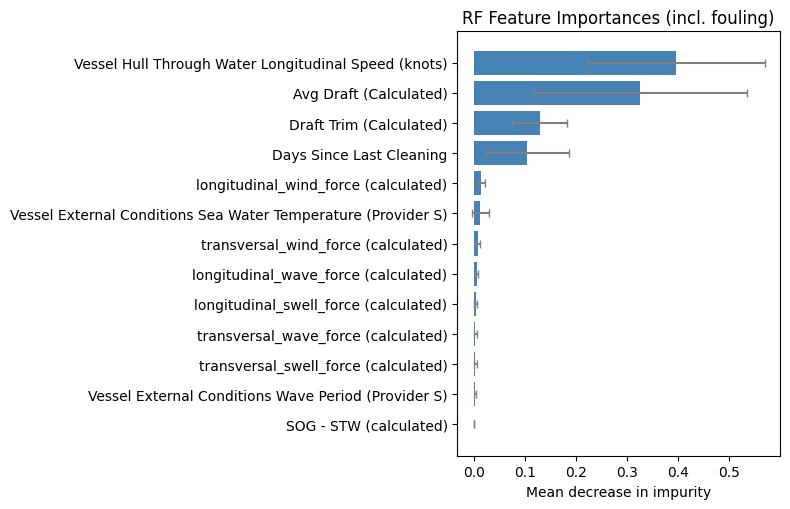

                                                      feature  importance      std
         Vessel Hull Through Water Longitudinal Speed (knots)    0.396107 0.174308
                                       Avg Draft (Calculated)    0.324747 0.210240
                                      Draft Trim (Calculated)    0.128024 0.053205
                                     Days Since Last Cleaning    0.103804 0.081268
                         longitudinal_wind_force (calculated)    0.014076 0.006787
Vessel External Conditions Sea Water Temperature (Provider S)    0.012134 0.016422
                          transversal_wind_force (calculated)    0.006463 0.004173
                         longitudinal_wave_force (calculated)    0.004627 0.003373
                        longitudinal_swell_force (calculated)    0.002955 0.003395
                          transversal_wave_force (calculated)    0.002411 0.003145
                         transversal_swell_force (calculated)    0.002335 0.003297
    

In [135]:
importance_df = plot_rf_feature_importance(
    model_pipelines_incl_foul["random_forest"],
    title="RF Feature Importances (incl. fouling)",
)
print(importance_df.to_string(index=False))

## 2.3. Black-box-specific

### 2.3.1. SHAP feature importance

## 2.4. All models

### 2.4.0. NN diagram

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

MLP layer sizes: [13, 128, 64, 1]


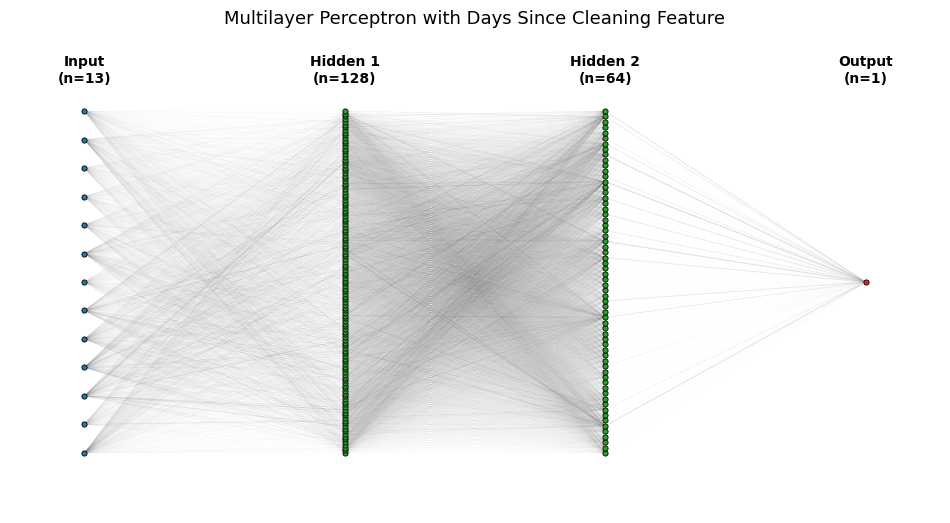

In [136]:
from IPython.display import display
from sklearn import set_config
import numpy as np
import matplotlib.pyplot as plt

# Use the NN pipeline that includes fouling features.
nn_pipeline = model_pipelines_incl_foul["NN"]

# Built-in sklearn pipeline visualization.
set_config(display="diagram")
display(nn_pipeline)


def _find_mlp_estimator(pipeline):
    """Find a fitted sklearn MLP estimator inside a pipeline."""
    preferred_names = ("model", "estimator", "regressor", "mlp")

    for name in preferred_names:
        if name in pipeline.named_steps:
            step = pipeline.named_steps[name]
            if hasattr(step, "coefs_") and hasattr(step, "hidden_layer_sizes"):
                return step, name

    for name, step in pipeline.named_steps.items():
        if hasattr(step, "coefs_") and hasattr(step, "hidden_layer_sizes"):
            return step, name

    raise ValueError("Could not find a fitted MLP estimator in pipeline.named_steps.")


def plot_mlp_topology(
    mlp,
    step_name="model",
    figsize=(12, 6),
    y_padding=0.13,
    label_y=0.992,
    edge_alpha_floor=0.03,
    edge_alpha_scale=0.20,
    edge_lw_min=0.08,
    edge_lw_max=0.8,
    node_size=None,
    plot_title=None,
):
    """Plot all neurons and all weights from a fitted sklearn MLPRegressor."""
    weights = mlp.coefs_
    layer_sizes = [weights[0].shape[0]] + [w.shape[1] for w in weights]
    shown_sizes = layer_sizes  # show every neuron

    num_layers = len(layer_sizes)
    x_positions = np.linspace(0.08, 0.92, num_layers)

    def y_positions(count):
        if count == 1:
            return np.array([0.5])
        return np.linspace(y_padding, 1.0 - y_padding, count)

    if node_size is None:
        # Smaller nodes when a layer is large.
        node_size = float(np.clip(1800.0 / max(layer_sizes), 6.0, 26.0))

    node_xy = []
    for layer_idx, shown_count in enumerate(shown_sizes):
        ys = y_positions(shown_count)
        xs = np.full(shown_count, x_positions[layer_idx])
        node_xy.append(np.column_stack([xs, ys]))

    fig, ax = plt.subplots(figsize=figsize)

    # Draw all edges.
    for layer_idx, w in enumerate(weights):
        in_count = shown_sizes[layer_idx]
        out_count = shown_sizes[layer_idx + 1]
        if in_count == 0 or out_count == 0:
            continue

        w_view = np.abs(w[:in_count, :out_count])
        w_max = w_view.max() + 1e-12

        for i in range(in_count):
            for j in range(out_count):
                strength = w_view[i, j] / w_max
                alpha = edge_alpha_floor + edge_alpha_scale * strength
                lw = edge_lw_min + (edge_lw_max - edge_lw_min) * strength
                x1, y1 = node_xy[layer_idx][i]
                x2, y2 = node_xy[layer_idx + 1][j]
                ax.plot([x1, x2], [y1, y2], color="0.45", alpha=alpha, lw=lw, zorder=1)

    # Draw nodes and layer annotations.
    for layer_idx in range(num_layers):
        points = node_xy[layer_idx]

        if layer_idx == 0:
            color = "#1f77b4"  # input
            label = "Input"
        elif layer_idx == num_layers - 1:
            color = "#d62728"  # output
            label = "Output"
        else:
            color = "#2ca02c"  # hidden
            label = f"Hidden {layer_idx}"

        ax.scatter(points[:, 0], points[:, 1], s=node_size, color=color, edgecolor="black", linewidths=0.6, zorder=2)

        ax.text(
            x_positions[layer_idx],
            label_y,
            f"{label}\n(n={layer_sizes[layer_idx]})",
            ha="center",
            va="top",
            fontsize=10,
            fontweight="bold",
        )

    ax.set_title(
        f"{plot_title}",
        fontsize=13,
        pad=20,
    )
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.axis("off")

    return fig, ax, layer_sizes


mlp_model, mlp_step_name = _find_mlp_estimator(nn_pipeline)
fig, ax, layer_sizes = plot_mlp_topology(
    mlp_model,
    step_name=mlp_step_name,
    figsize=(12, 6),
    y_padding=0.13,
    label_y=0.992,
    plot_title="Multilayer Perceptron with Days Since Cleaning Feature",
)

print("MLP layer sizes:", layer_sizes)
plt.show()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

MLP layer sizes (excl. fouling): [12, 128, 64, 1]


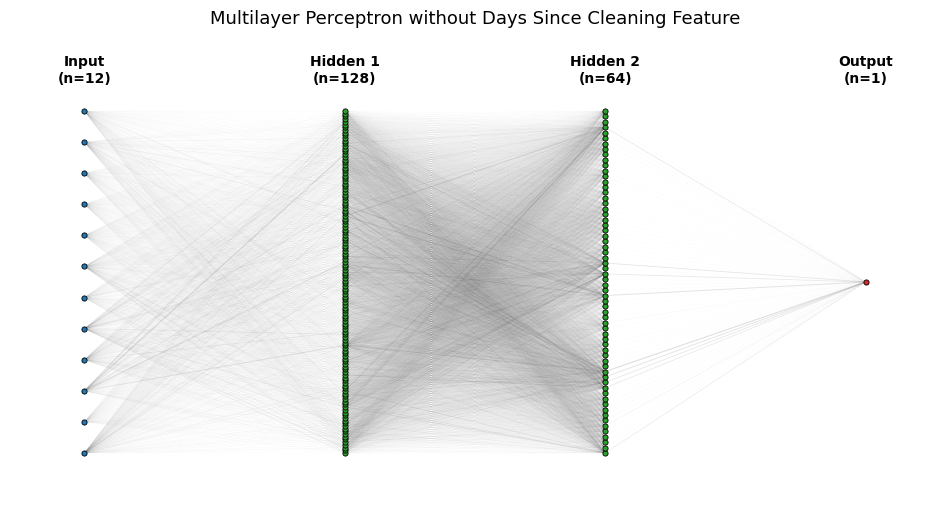

In [137]:
# Use the NN pipeline that excludes fouling features.
nn_pipeline_excl = model_pipelines_excl_foul["NN"]

display(nn_pipeline_excl)

mlp_model_excl, mlp_step_name_excl = _find_mlp_estimator(nn_pipeline_excl)
fig, ax, layer_sizes_excl = plot_mlp_topology(
    mlp_model_excl,
    step_name=mlp_step_name_excl,
    figsize=(12, 6),
    y_padding=0.13,
    label_y=0.992,
    plot_title="Multilayer Perceptron without Days Since Cleaning Feature",
)

print("MLP layer sizes (excl. fouling):", layer_sizes_excl)
plt.show()

### 2.4.1. Incl. vs. excl fouling performance check

#### Residuals comparison over time, incl with/without fouling

Over time, the residuals for the fouling-free model should have the fouling effect leaking into the error term (residuals increasing over time)

In [138]:
def plot_residuals_with_cleaning_events(
    pipeline_incl_fouling,
    pipeline_excl_fouling,
    X,
    y,
    timestamps,
    cleaning_dates,
    model_name="Model",
    figsize=(16, 5),
):
    """
    Plot residuals over time for two fitted pipelines (incl./excl. fouling features)
    in a 1x2 layout, with vertical lines marking cleaning events.

    Parameters
    ----------
    pipeline_incl_fouling : sklearn-like pipeline
        Fitted pipeline that includes fouling features.
    pipeline_excl_fouling : sklearn-like pipeline
        Fitted pipeline that excludes fouling features.
    X : array-like
        Feature matrix used for prediction.
    y : array-like
        True target values.
    timestamps : array-like
        Datetime-like values aligned with X and y.
    cleaning_dates : array-like
        Datetime-like cleaning event timestamps.
    model_name : str
        Display name for subplot titles.
    figsize : tuple
        Figure size passed to matplotlib.
    """
    y_true = np.asarray(y).reshape(-1)
    time_index = pd.to_datetime(pd.Series(timestamps).reset_index(drop=True))

    if len(time_index) != len(y_true):
        raise ValueError("`timestamps` must have the same length as `y`.")

    pred_incl = np.asarray(pipeline_incl_fouling.predict(X)).reshape(-1)
    pred_excl = np.asarray(pipeline_excl_fouling.predict(X)).reshape(-1)

    if len(pred_incl) != len(y_true) or len(pred_excl) != len(y_true):
        raise ValueError("Predictions and y must have identical lengths.")

    # Sort by time so line plots are chronological
    sort_order = time_index.argsort()
    time_index    = time_index.iloc[sort_order].reset_index(drop=True)
    y_true        = y_true[sort_order]
    pred_incl     = pred_incl[sort_order]
    pred_excl     = pred_excl[sort_order]

    residuals_incl = y_true - pred_incl
    residuals_excl = y_true - pred_excl
    cleaning_dates = pd.to_datetime(cleaning_dates)

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    plot_specs = [
        (axes[0], residuals_incl, "Incl. fouling features", "tab:blue"),
        (axes[1], residuals_excl, "Excl. fouling features", "tab:orange"),
    ]

    for ax, residuals, subtitle, color in plot_specs:
        ax.plot(time_index, residuals, color=color, linewidth=0.6, alpha=0.7)
        ax.axhline(0, color="black", linestyle="--", linewidth=1)

        for i, clean_date in enumerate(cleaning_dates):
            label = "Cleaning event" if i == 0 else None
            ax.axvline(clean_date, color="crimson", linestyle=":", linewidth=1.2, alpha=0.85, label=label)

        ax.set_title(f"{model_name}: {subtitle}")
        ax.set_xlabel("Time")
        ax.grid(alpha=0.2)

    axes[0].set_ylabel("Residual (y - y_hat)")
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend(loc="upper right")

    fig.suptitle("Residuals Over Time With Cleaning Events")
    fig.tight_layout()
    plt.show()

    return pd.DataFrame(
        {
            "timestamp": time_index,
            "residual_incl_fouling": residuals_incl,
            "residual_excl_fouling": residuals_excl,
        }
    )

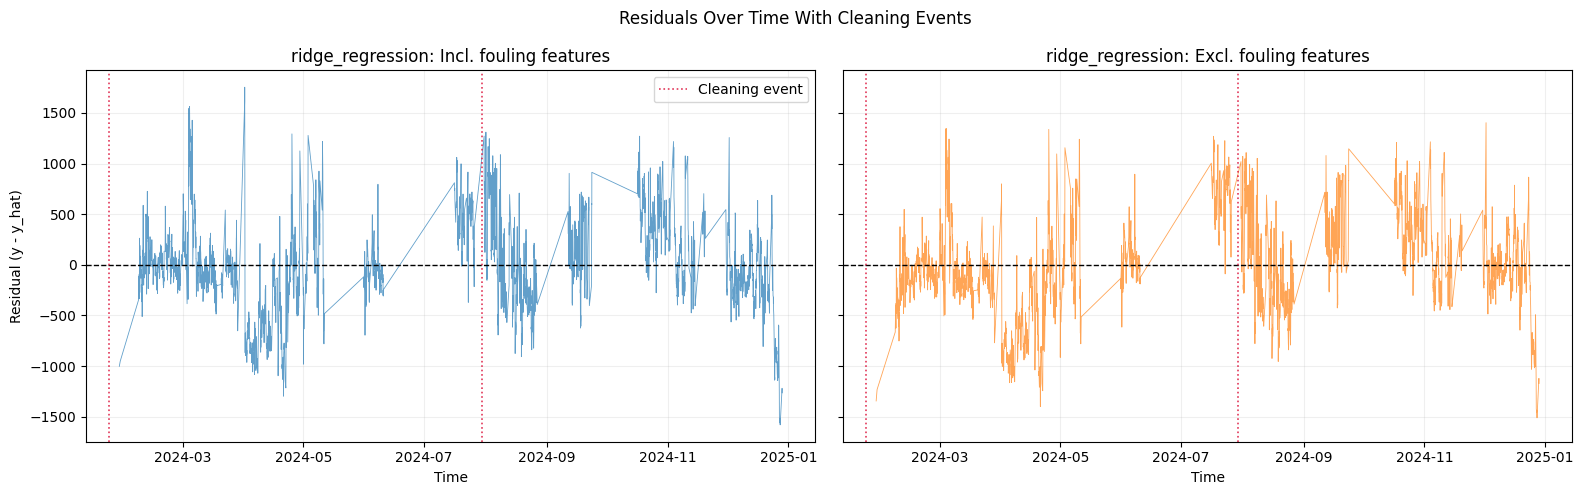

In [139]:
residual_df = plot_residuals_with_cleaning_events(
    model_pipelines_incl_foul["ridge_regression"],
    model_pipelines_excl_foul["ridge_regression"],
    X_test,
    y_test,
    timestamps=test_timestamps,
    cleaning_dates=cleaning_events,
    model_name="ridge_regression",
)

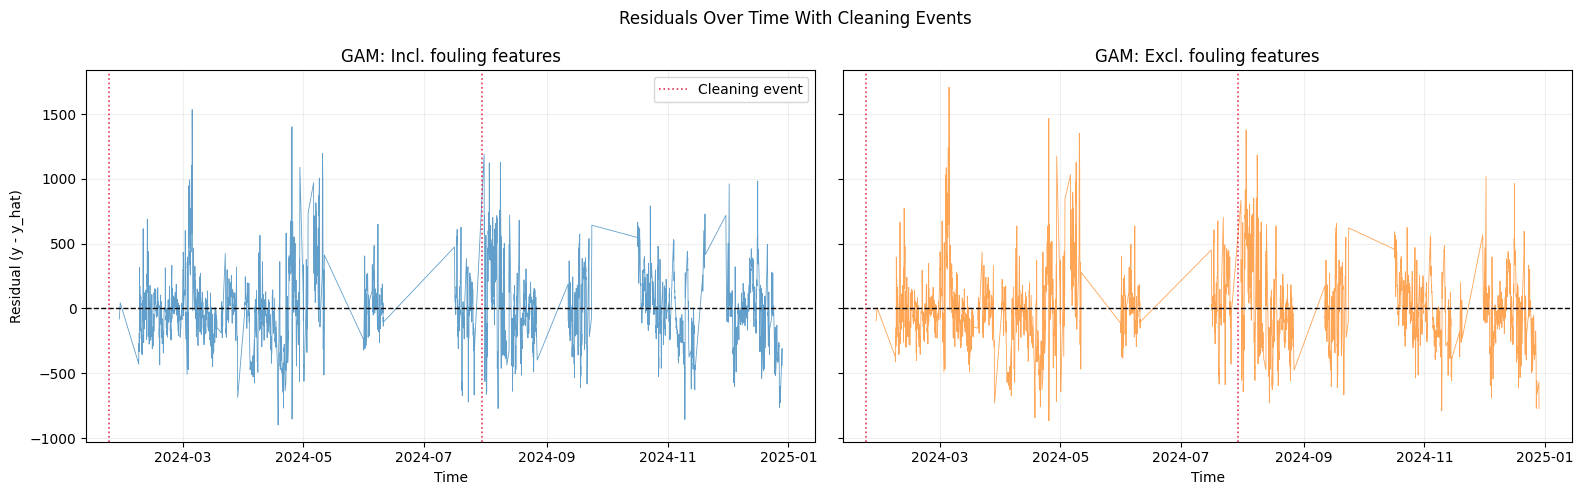

In [140]:
residual_df = plot_residuals_with_cleaning_events(
    model_pipelines_incl_foul["GAM"],
    model_pipelines_excl_foul["GAM"],
    X_test,
    y_test,
    timestamps=test_timestamps,
    cleaning_dates=cleaning_events,
    model_name="GAM",
)

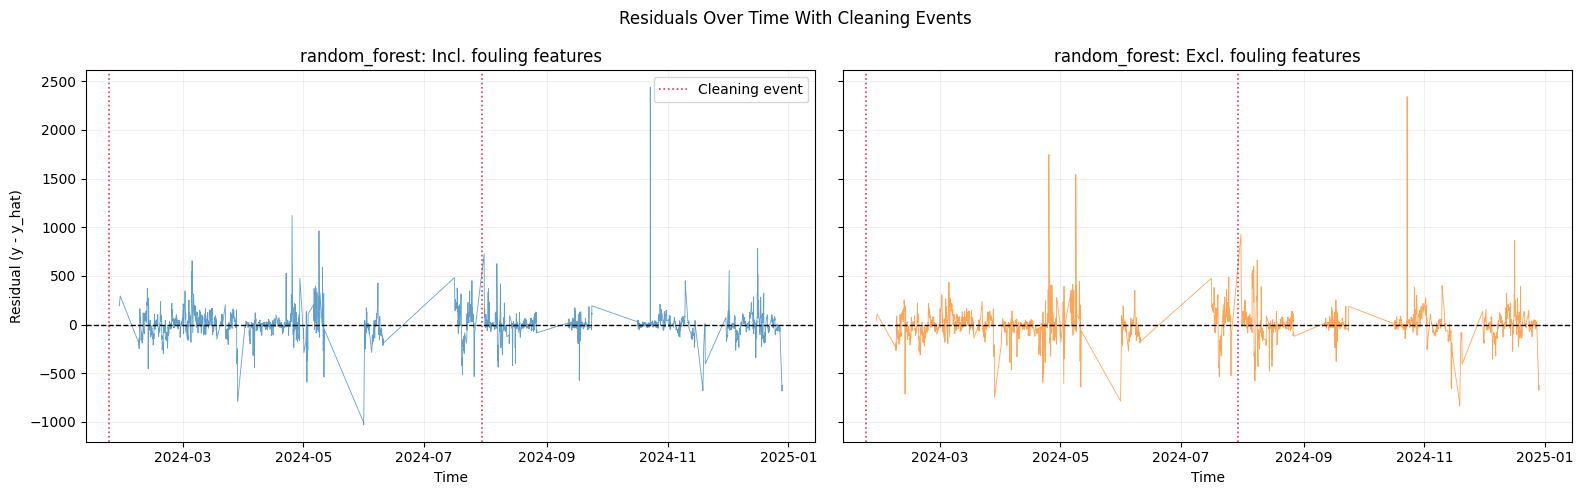

In [141]:
residual_df = plot_residuals_with_cleaning_events(
    model_pipelines_incl_foul["random_forest"],
    model_pipelines_excl_foul["random_forest"],
    X_test,
    y_test,
    timestamps=test_timestamps,
    cleaning_dates=cleaning_events,
    model_name="random_forest",
)

### 2.4.2. Overfitting check

In [142]:
def load_latest_training_results(model_pipelines, outputs_dir):
    """
    For each model in model_pipelines, finds the latest training CSV
    and returns them appended into a single DataFrame.
    """
    dfs = []

    for model in model_pipelines.keys():
        # Find all matching CSVs for this model
        pattern = os.path.join(outputs_dir, f"{model}_training_*.csv")
        files = sorted(glob.glob(pattern))  # alphabetical = chronological for timestamp filenames

        if not files:
            logger.warning(f"No training CSV found for model: {model}")
            continue

        latest_file = files[-1]
        logger.info(f"{model}: loading {os.path.basename(latest_file)}")

        df = pd.read_csv(latest_file)
     #   df.insert(0, "model", model)  # prepend model name for clarity
        dfs.append(df)

    if not dfs:
        raise FileNotFoundError("No training CSV files found for any model.")

    return pd.concat(dfs, ignore_index=True)


In [143]:
outputs_dir = os.path.join(notebook_parent_parent_dir, "outputs", "models")
results_df = load_latest_training_results(model_pipelines_incl_foul, outputs_dir)

# Choose only relevant columns 
results_df = results_df[["model", "train_rmse", "test_rmse", "train_mape", "test_mape", "train_mae", "test_mae"]]

display(results_df.style.format({ "train_rmse": "{:.1f}", "test_rmse": "{:.1f}", "train_mape": "{:.4f}", "test_mape": "{:.4f}", "train_mae": "{:.1f}", "test_mae": "{:.1f}" }))

2026-04-15 18:05:58.497 | INFO     | __main__:load_latest_training_results:18 - ridge_regression: loading Ridge_Regression_training_20260415_093631.csv
2026-04-15 18:05:58.503 | INFO     | __main__:load_latest_training_results:18 - GAM: loading GAM_training_20260415_105226.csv
2026-04-15 18:05:58.512 | INFO     | __main__:load_latest_training_results:18 - random_forest: loading Random_Forest_training_20260414_131244.csv
2026-04-15 18:05:58.512 | INFO     | __main__:load_latest_training_results:18 - NN: loading NN_training_20260415_102710.csv


,model,train_rmse,test_rmse,train_mape,test_mape,train_mae,test_mae
0,Ridge_Regression_incl_fouling,455.2,458.2,0.1346,0.1346,342.6,345.9
1,Ridge_Regression_excl_fouling,472.7,473.3,0.1394,0.1394,360.1,362.2
2,GAM_incl_fouling,286.2,286.5,0.0748,0.0734,212.2,213.6
3,GAM_excl_fouling,295.6,297.7,0.0749,0.0742,216.5,219.1
4,Random_Forest_incl_fouling,116.8,131.2,0.0231,0.0238,70.5,75.8
5,Random_Forest_excl_fouling,140.7,154.3,0.0291,0.0288,84.5,88.9
6,NN_incl_fouling,130.9,138.3,0.0315,0.0316,92.5,96.6
7,NN_excl_fouling,147.0,150.8,0.0359,0.0345,103.9,105.4


### 2.4.3. Wilcoxon signed-rank test (incl. vs. excl. fouling)

For each model, we test paired loss differences on the same test observations using $d_i = L_i^{base} - L_i^{fouling}$ and a one-sided Wilcoxon test ($H_1: \mathrm{median}(d_i) > 0$).

In [144]:
def run_wilcoxon_fouling_tests(
    pipelines_base: dict,
    pipelines_fouling: dict,
    X,
    y_true,
    loss: str = "absolute",
    alpha: float = 0.05,
) -> pd.DataFrame:
    """
    Run one-sided Wilcoxon signed-rank tests on paired per-observation losses.

    H0: median(L_base - L_fouling) <= 0
    H1: median(L_base - L_fouling) > 0
    """
    common_models = sorted(set(pipelines_base).intersection(pipelines_fouling))
    if not common_models:
        raise ValueError("No overlapping model names between base and fouling pipeline dictionaries.")

    y_true = np.asarray(y_true).reshape(-1)

    if loss == "absolute":
        loss_label = "absolute error"
        loss_fn = lambda y, yhat: np.abs(y - yhat)
    elif loss == "squared":
        loss_label = "squared error"
        loss_fn = lambda y, yhat: (y - yhat) ** 2
    else:
        raise ValueError("loss must be either 'absolute' or 'squared'.")

    rows = []
    for model_name in common_models:
        y_pred_base = np.asarray(pipelines_base[model_name].predict(X)).reshape(-1)
        y_pred_foul = np.asarray(pipelines_fouling[model_name].predict(X)).reshape(-1)

        if len(y_pred_base) != len(y_true) or len(y_pred_foul) != len(y_true):
            raise ValueError(f"Length mismatch for model '{model_name}'.")

        base_loss = loss_fn(y_true, y_pred_base)
        foul_loss = loss_fn(y_true, y_pred_foul)
        d = base_loss - foul_loss  # positive means fouling model has lower loss

        n_obs = len(d)
        n_nonzero = int(np.count_nonzero(~np.isclose(d, 0)))
        positive_share = float(np.mean(d > 0))
        median_gain = float(np.median(d))
        mean_gain = float(np.mean(d))

        if n_nonzero == 0:
            stat = np.nan
            p_value = 1.0
            note = "all paired differences are zero"
        else:
            test = stats.wilcoxon(d, alternative="greater", zero_method="wilcox")
            stat = float(test.statistic)
            p_value = float(test.pvalue)
            note = ""

        passed = bool(p_value < alpha)

        rows.append(
            {
                "model": model_name,
                "loss": loss_label,
                "n_obs": n_obs,
                "n_nonzero_d": n_nonzero,
                "median_d": median_gain,
                "mean_d": mean_gain,
                "share_d_positive": positive_share,
                "wilcoxon_stat": stat,
                "p_value": p_value,
                "pass": passed,
                "result": "PASS" if passed else "FAIL",
                "note": note,
            }
        )

    results = pd.DataFrame(rows).sort_values(["pass", "p_value"], ascending=[False, True]).reset_index(drop=True)

    print(f"Wilcoxon signed-rank test on paired {loss_label} differences")
    print("d_i = L_i(base) - L_i(fouling), so d_i > 0 favors the fouling model")
    print(f"H0: median(d_i) <= 0 | H1: median(d_i) > 0 | alpha = {alpha:.3f}")
    print("A model PASSES if p-value < alpha.")

    cols_to_show = [
        "model", "result", "p_value", "median_d", "mean_d",
        "share_d_positive", "n_nonzero_d", "n_obs", "note",
    ]
    display(
        results[cols_to_show].style.format(
            {
                "p_value": "{:.4g}",
                "median_d": "{:.4f}",
                "mean_d": "{:.4f}",
                "share_d_positive": "{:.1%}",
            }
)
    )

    passed_models = results.loc[results["pass"], "model"].tolist()
    failed_models = results.loc[~results["pass"], "model"].tolist()

    print("\nSummary")
    print(f"Passed ({len(passed_models)}): {', '.join(passed_models) if passed_models else 'None'}")
    print(f"Did not pass ({len(failed_models)}): {', '.join(failed_models) if failed_models else 'None'}")

    return results

wilcoxon_results_abs = run_wilcoxon_fouling_tests(
    pipelines_base=model_pipelines_excl_foul,
    pipelines_fouling=model_pipelines_incl_foul,
    X=X_test,
    y_true=y_test,
    loss="absolute",
    alpha=0.05,
)

# Optional robustness check with squared error instead of absolute error:
# wilcoxon_results_sq = run_wilcoxon_fouling_tests(
#     pipelines_base=model_pipelines_excl_foul,
#     pipelines_fouling=model_pipelines_incl_foul,
#     X=X_test,
#     y_true=y_test,
#     loss="squared",
#     alpha=0.05,
# )

Wilcoxon signed-rank test on paired absolute error differences
d_i = L_i(base) - L_i(fouling), so d_i > 0 favors the fouling model
H0: median(d_i) <= 0 | H1: median(d_i) > 0 | alpha = 0.050
A model PASSES if p-value < alpha.


,model,result,p_value,median_d,mean_d,share_d_positive,n_nonzero_d,n_obs,note
0,random_forest,PASS,1.72e-23,3.7179,13.0684,57.2%,3013,3013,
1,ridge_regression,PASS,1.253e-11,25.4848,16.3350,57.6%,3013,3013,
2,NN,PASS,4.119e-08,3.7862,8.8134,52.3%,3013,3013,
3,GAM,PASS,3.464e-06,2.2386,5.4105,52.5%,3013,3013,



Summary
Passed (4): random_forest, ridge_regression, NN, GAM
Did not pass (0): None


### 2.4.4. Residual diagnostics

#### Fitted vs. predicted values

In [145]:
def plot_actual_vs_predicted(model_name, pipeline, X, y, figsize=(14, 5)):
    """
    Two side-by-side scatter plots for a fitted pipeline:
      Left  — Actual vs. Predicted  (red diagonal = perfect predictions)
      Right — Residuals vs. Predicted (red horizontal = zero residual)

    Parameters
    ----------
    model_name : str
        Display name used in titles.
    pipeline : sklearn-like pipeline
        Fitted pipeline with a .predict() method.
    X : array-like
        Feature matrix.
    y : array-like
        True target values.
    figsize : tuple
        Figure size.
    """
    y_true = np.asarray(y).reshape(-1)
    y_pred = np.asarray(pipeline.predict(X)).reshape(-1)
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # --- Left: Actual vs. Predicted ---
    ax = axes[0]
    ax.scatter(y_pred, y_true, alpha=0.3, s=8, color="steelblue", rasterized=True)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, color="red", linewidth=1.2, label="Perfect fit")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{model_name}: Actual vs. Predicted")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.2)

    # --- Right: Residuals vs. Predicted ---
    ax = axes[1]
    ax.scatter(y_pred, residuals, alpha=0.3, s=8, color="tab:orange", rasterized=True)
    ax.axhline(0, color="red", linewidth=1.2, label="Zero residual")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual (y - y_hat)")
    ax.set_title(f"{model_name}: Residuals vs. Predicted")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.2)

    fig.tight_layout()
    plt.show()


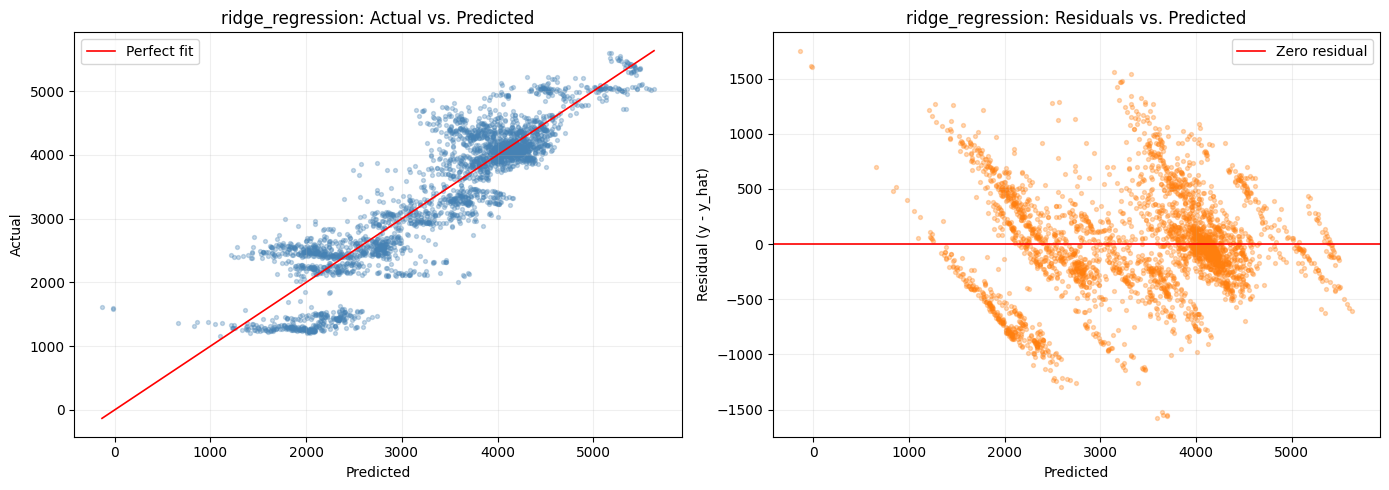

In [146]:
plot_actual_vs_predicted("ridge_regression", model_pipelines_incl_foul["ridge_regression"], X_test, y_test)

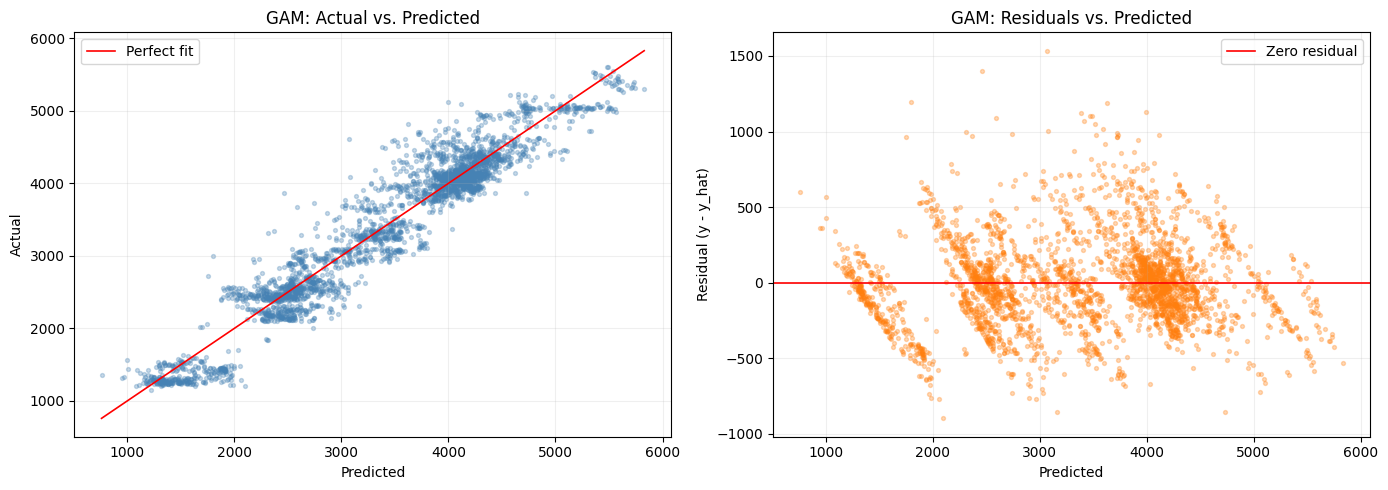

In [147]:
plot_actual_vs_predicted("GAM", model_pipelines_incl_foul["GAM"], X_test, y_test)

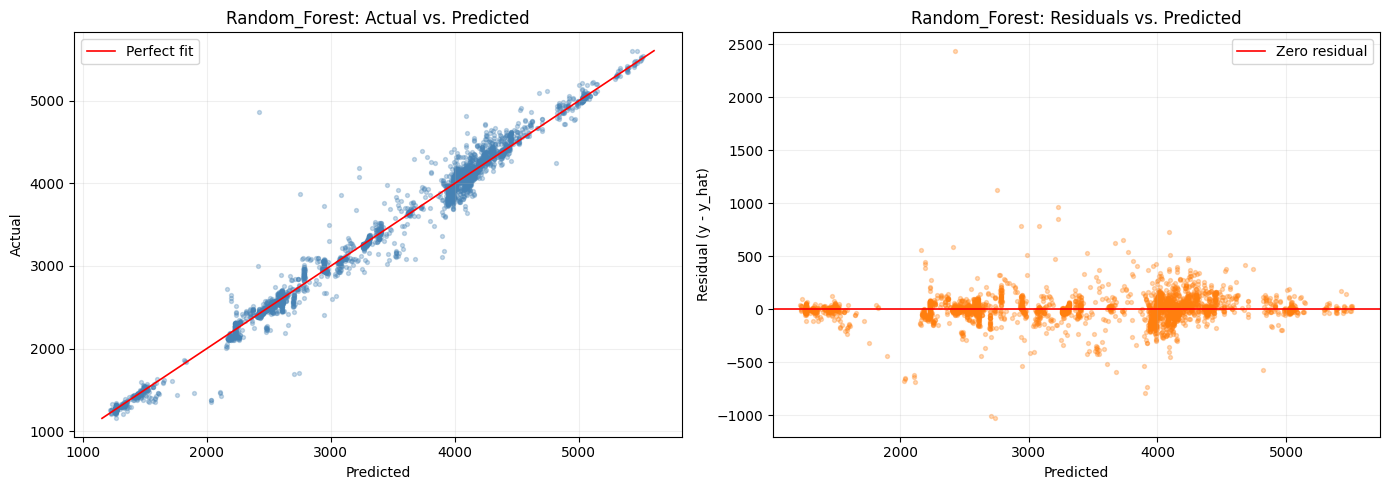

In [148]:
plot_actual_vs_predicted("Random_Forest", model_pipelines_incl_foul["random_forest"], X_test, y_test)

#### QQ plot/normality

In [149]:
def plot_qq(pipelines: dict, X, y, figsize=None):
    """
    QQ plots of residuals for each pipeline in a single side-by-side row.

    Parameters
    ----------
    pipelines : dict
        Mapping of model_name -> fitted pipeline.
    X : array-like
        Feature matrix.
    y : array-like
        True target values.
    figsize : tuple or None
        Figure size. Defaults to (5 * n_models, 5).
    """
    n = len(pipelines)
    if figsize is None:
        figsize = (5 * n, 5)

    y_true = np.asarray(y).reshape(-1)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]

    for ax, (model_name, pipeline) in zip(axes, pipelines.items()):
        residuals = y_true - np.asarray(pipeline.predict(X)).reshape(-1)
        (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist="norm")
        ax.scatter(osm, osr, s=6, alpha=0.4, color="steelblue", rasterized=True)
        ax.plot(osm, slope * np.array(osm) + intercept, color="red", linewidth=1.2, label="Normal fit")
        ax.set_title(f"{model_name}: QQ Plot")
        ax.set_xlabel("Theoretical quantiles")
        ax.set_ylabel("Sample quantiles")
        ax.legend(loc="upper left")
        ax.grid(alpha=0.2)

    fig.suptitle("QQ Plots of Residuals")
    fig.tight_layout()
    plt.show()


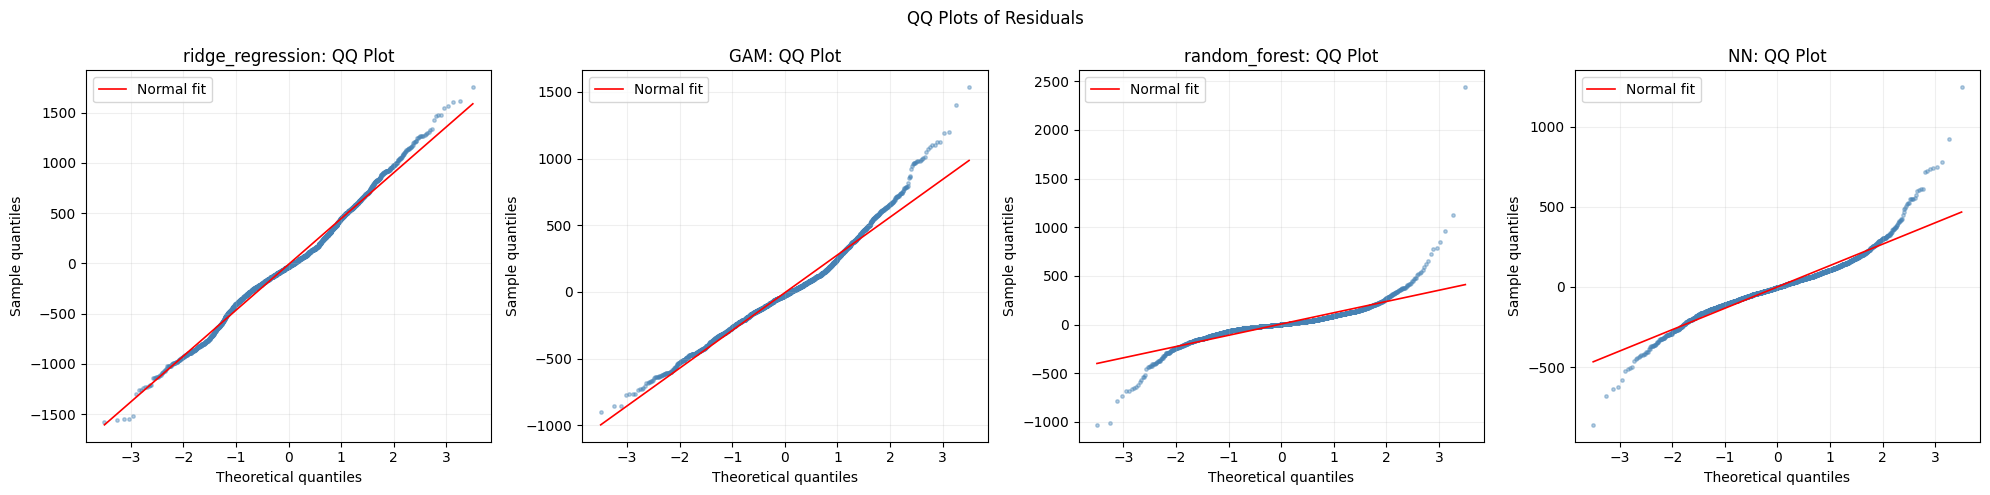

In [150]:
plot_qq(model_pipelines_incl_foul, X_test, y_test)

#### Residual scatter by each feature 

In [151]:
def plot_residuals_by_feature(pipelines: dict, X, y, cols=4, figsize_per_plot=(4, 3)):
    """
    For each model in pipelines, produces a grid of scatter plots (residuals vs. each
    feature) in rows of `cols`. Each model gets its own clearly-titled figure so the
    boundary between models is unambiguous.

    Finally, prints and returns a correlation table: models as rows, features as columns.

    Parameters
    ----------
    pipelines : dict
        Mapping of model_name -> fitted pipeline.
    X : pd.DataFrame
        Feature matrix with named columns.
    y : array-like
        True target values.
    cols : int
        Scatter plots per row (default 4).
    figsize_per_plot : tuple
        (width, height) allocated for each individual subplot.
    """
    X_df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
    feature_names = X_df.columns.tolist()
    y_true = np.asarray(y).reshape(-1)
    n_features = len(feature_names)
    rows = int(np.ceil(n_features / cols))

    corr_records = {}

    for model_name, pipeline in pipelines.items():
        residuals = y_true - np.asarray(pipeline.predict(X_df)).reshape(-1)

        fig, axes = plt.subplots(
            rows, cols,
            figsize=(figsize_per_plot[0] * cols, figsize_per_plot[1] * rows),
        )
        axes_flat = np.array(axes).reshape(-1)

        feature_corrs = {}
        for i, feat in enumerate(feature_names):
            ax = axes_flat[i]
            feat_vals = X_df[feat].values

            # Compute Pearson r; guard against constant features (e.g. all-zero voyage dummies)
            try:
                r = float(np.corrcoef(feat_vals, residuals)[0, 1])
            except (ValueError, AttributeError):
                r = np.nan
            feature_corrs[feat] = r

            ax.scatter(feat_vals, residuals, s=4, alpha=0.25, rasterized=True)
            ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
            r_label = f"{r:.3f}" if not np.isnan(r) else "const"
            ax.set_title(f"{feat}  (r={r_label})", fontsize=8)
            ax.set_xlabel(feat, fontsize=7)
            ax.set_ylabel("Residual", fontsize=7)
            ax.tick_params(labelsize=7)
            ax.grid(alpha=0.2)

        for j in range(i + 1, len(axes_flat)):
            axes_flat[j].set_visible(False)

        fig.suptitle(
            f"Residuals vs. Each Feature  —  {model_name}",
            fontsize=13, fontweight="bold",
        )
        fig.tight_layout()
        plt.show()

        corr_records[model_name] = feature_corrs

    # --- Correlation table ---
    corr_df = pd.DataFrame(corr_records).T
    corr_df.index.name = "Model \\ Feature"
    print("\nCorrelation of each feature with model residuals:")
    display(
        corr_df.style
        .format("{:.3f}")
        .background_gradient(cmap="coolwarm", axis=None, vmin=-1, vmax=1)
    )

    return corr_df

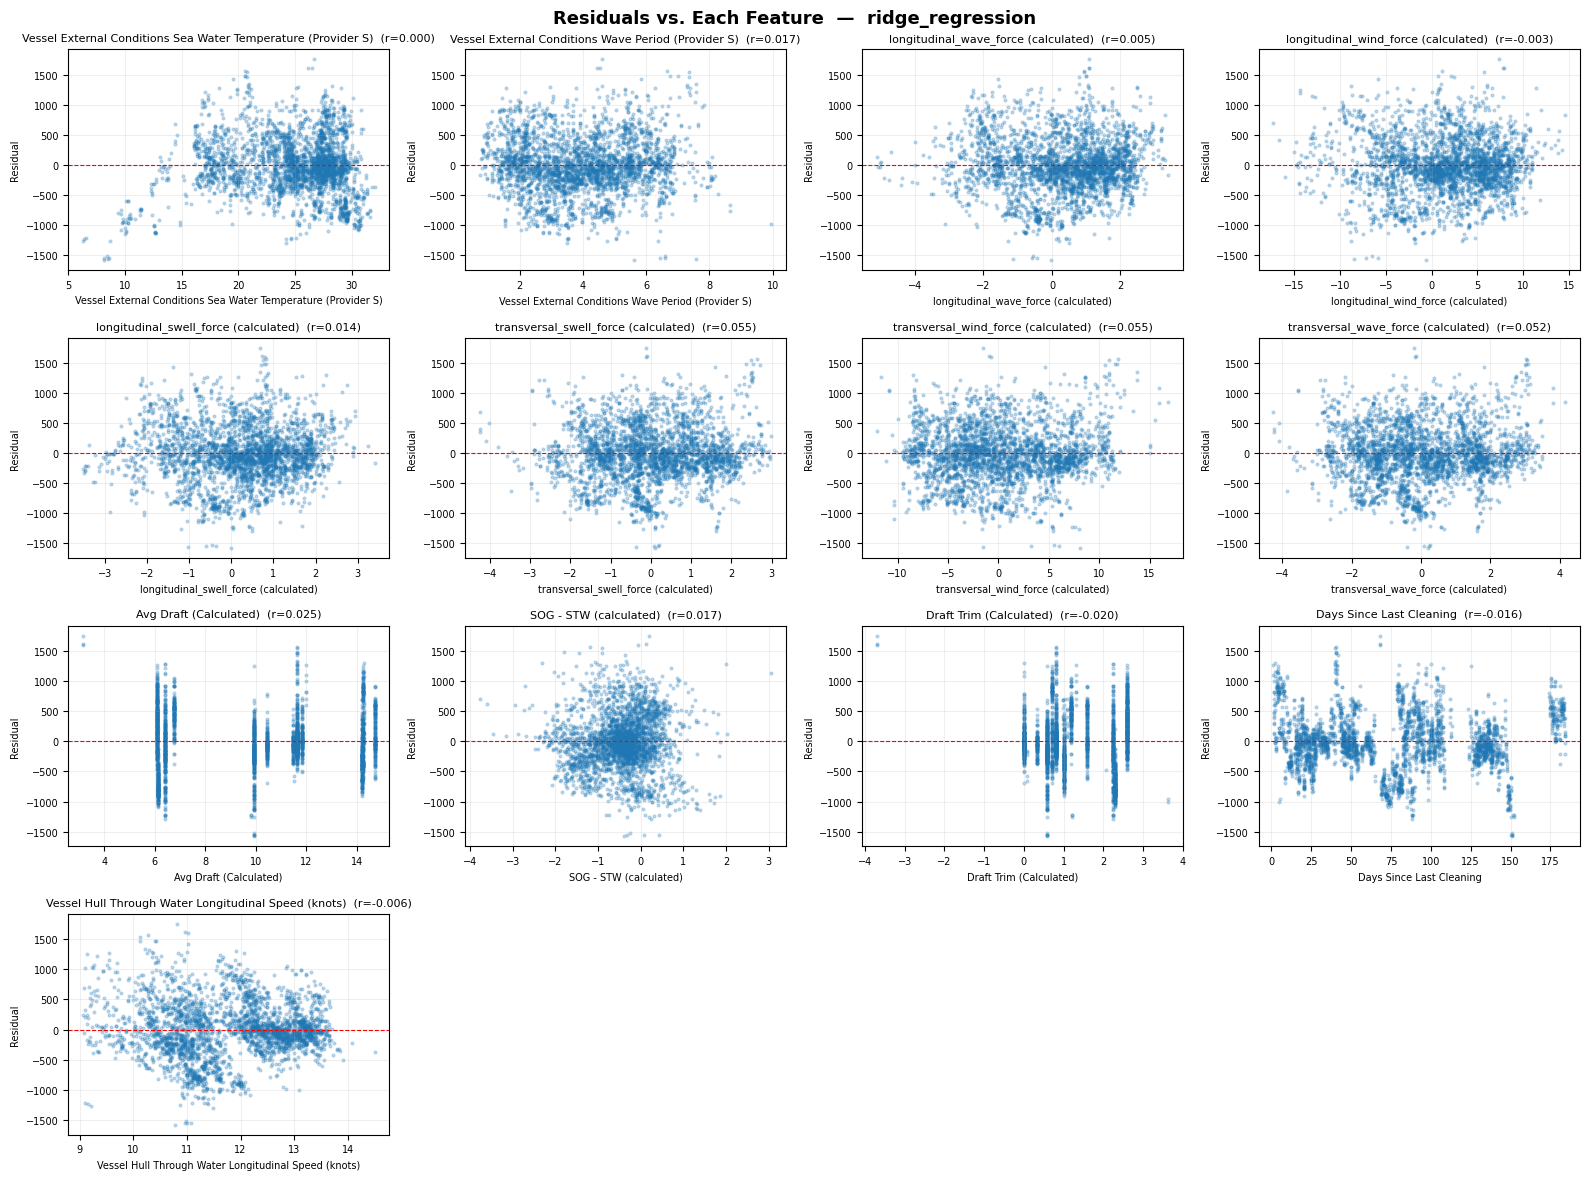

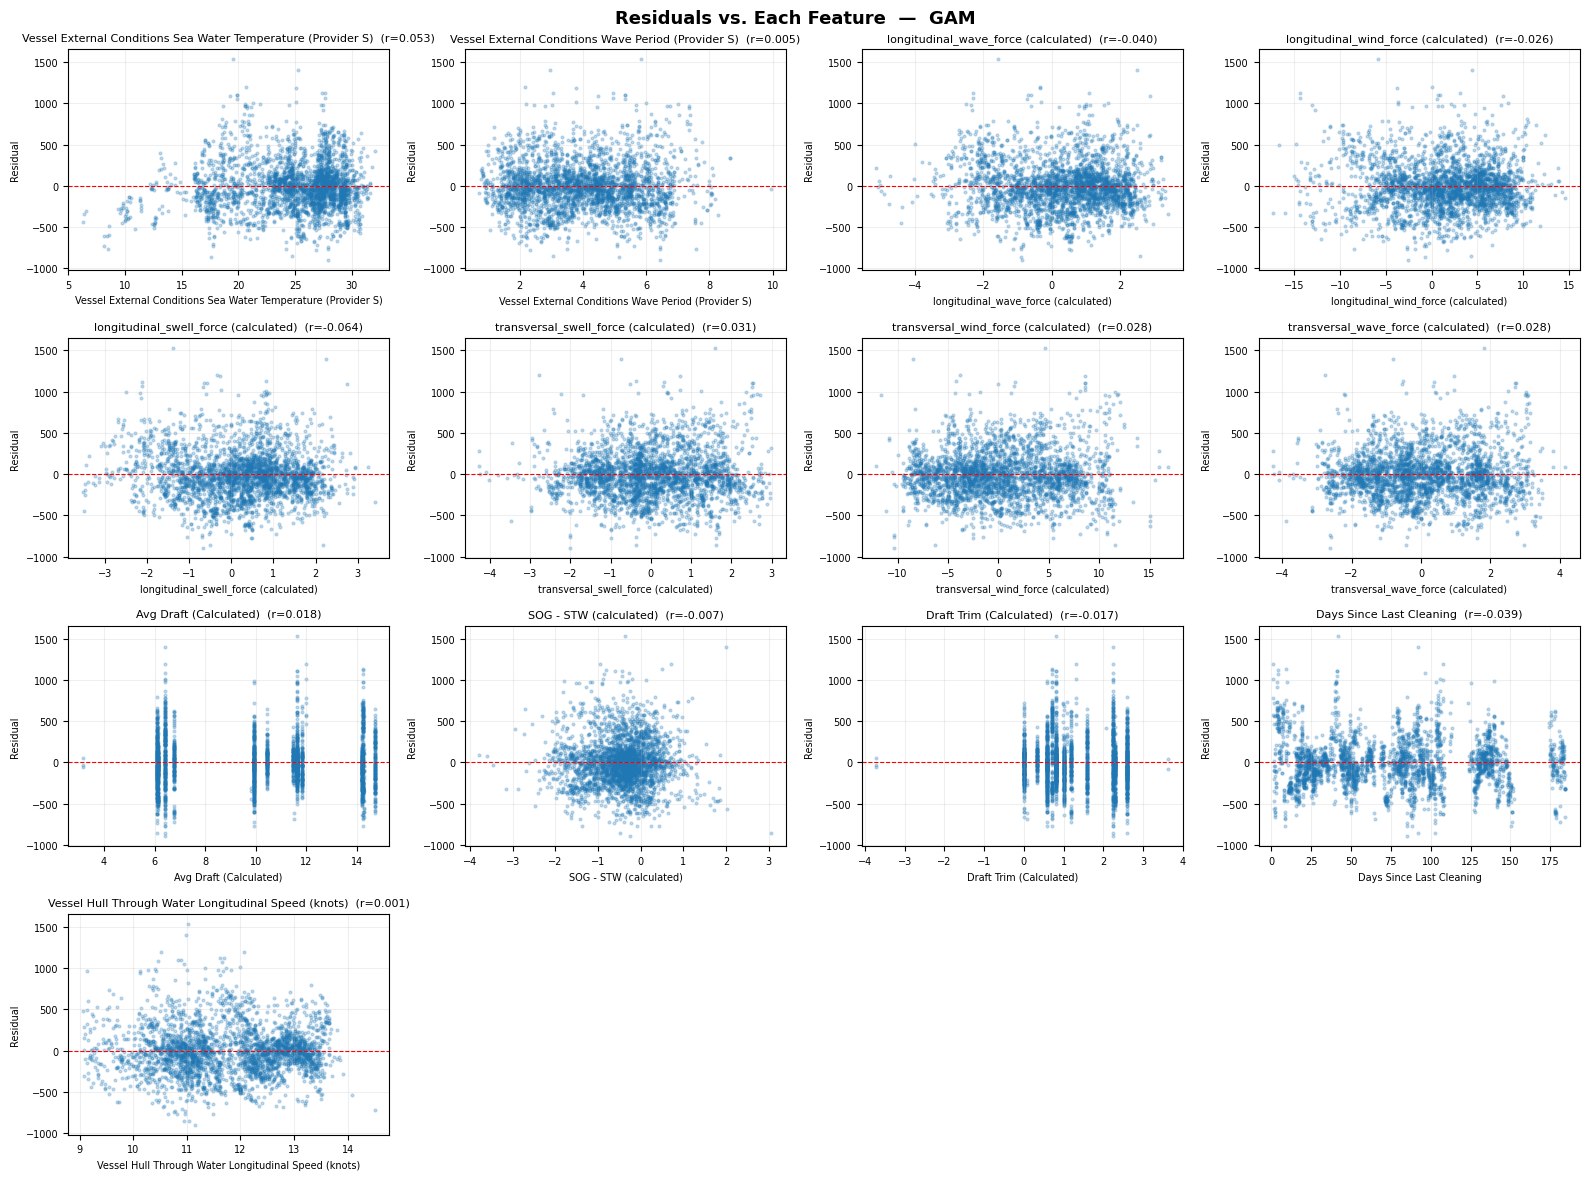

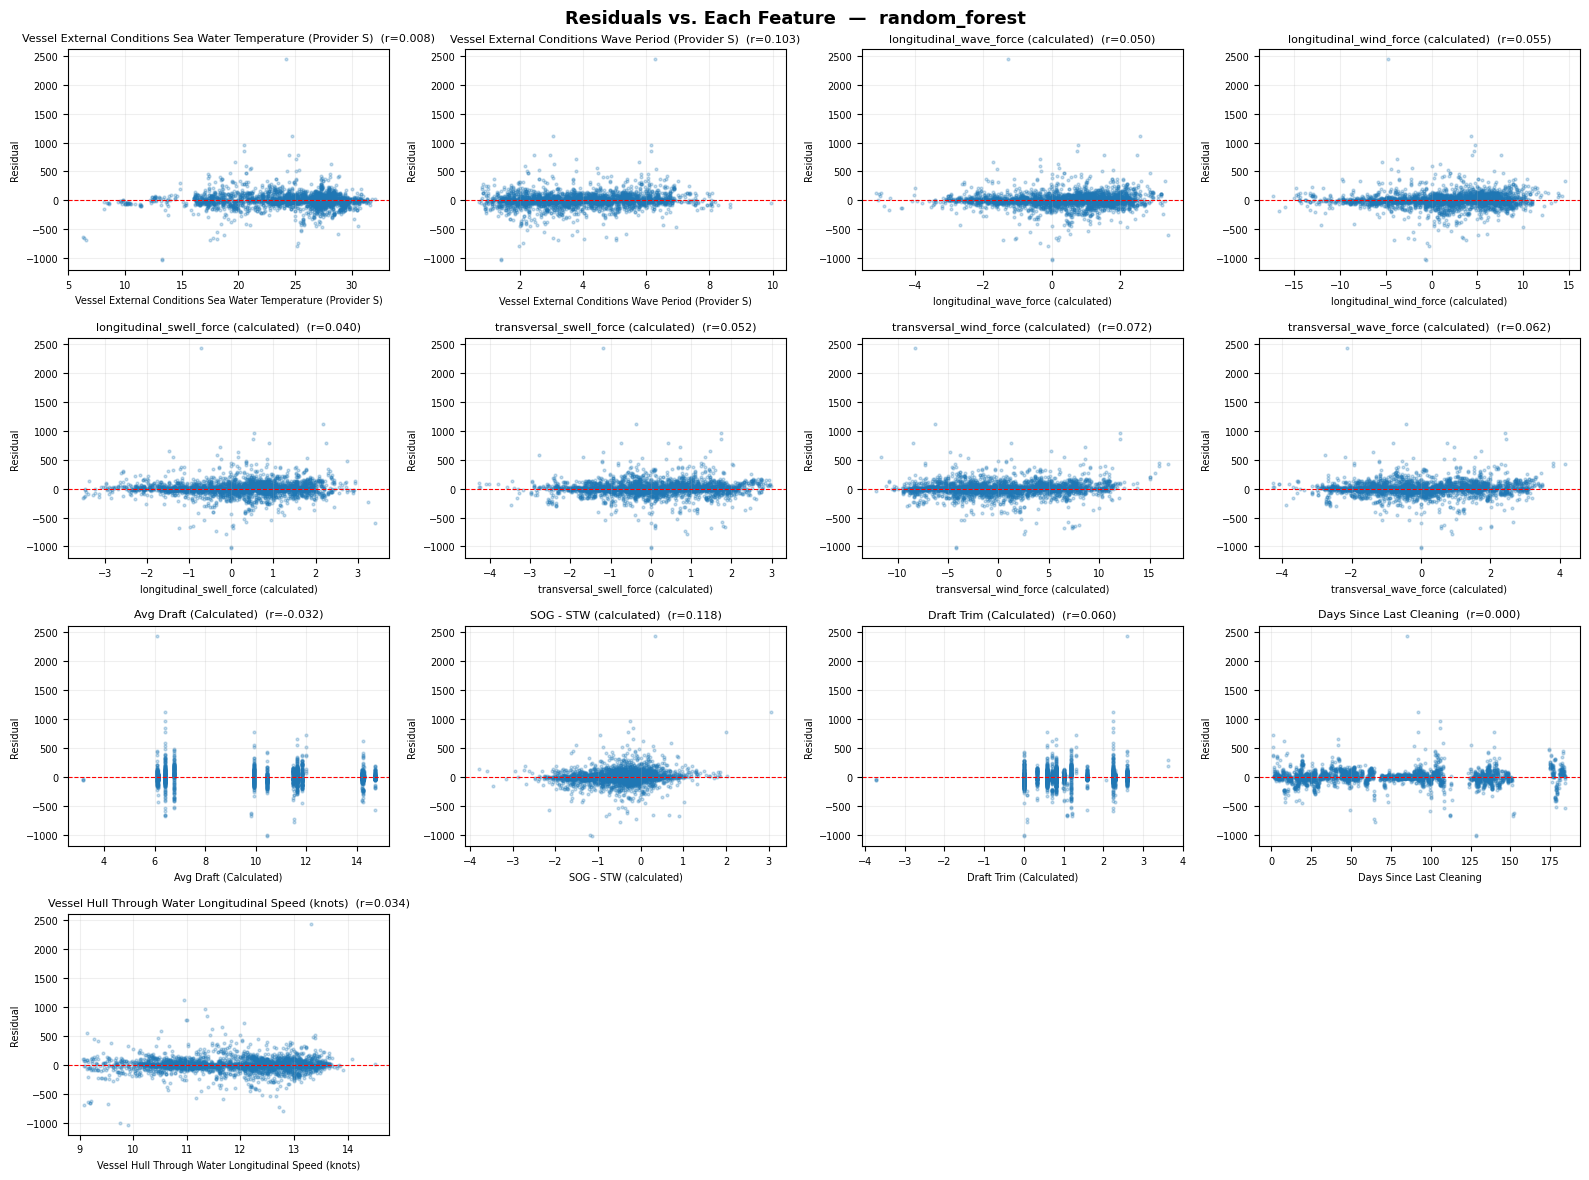

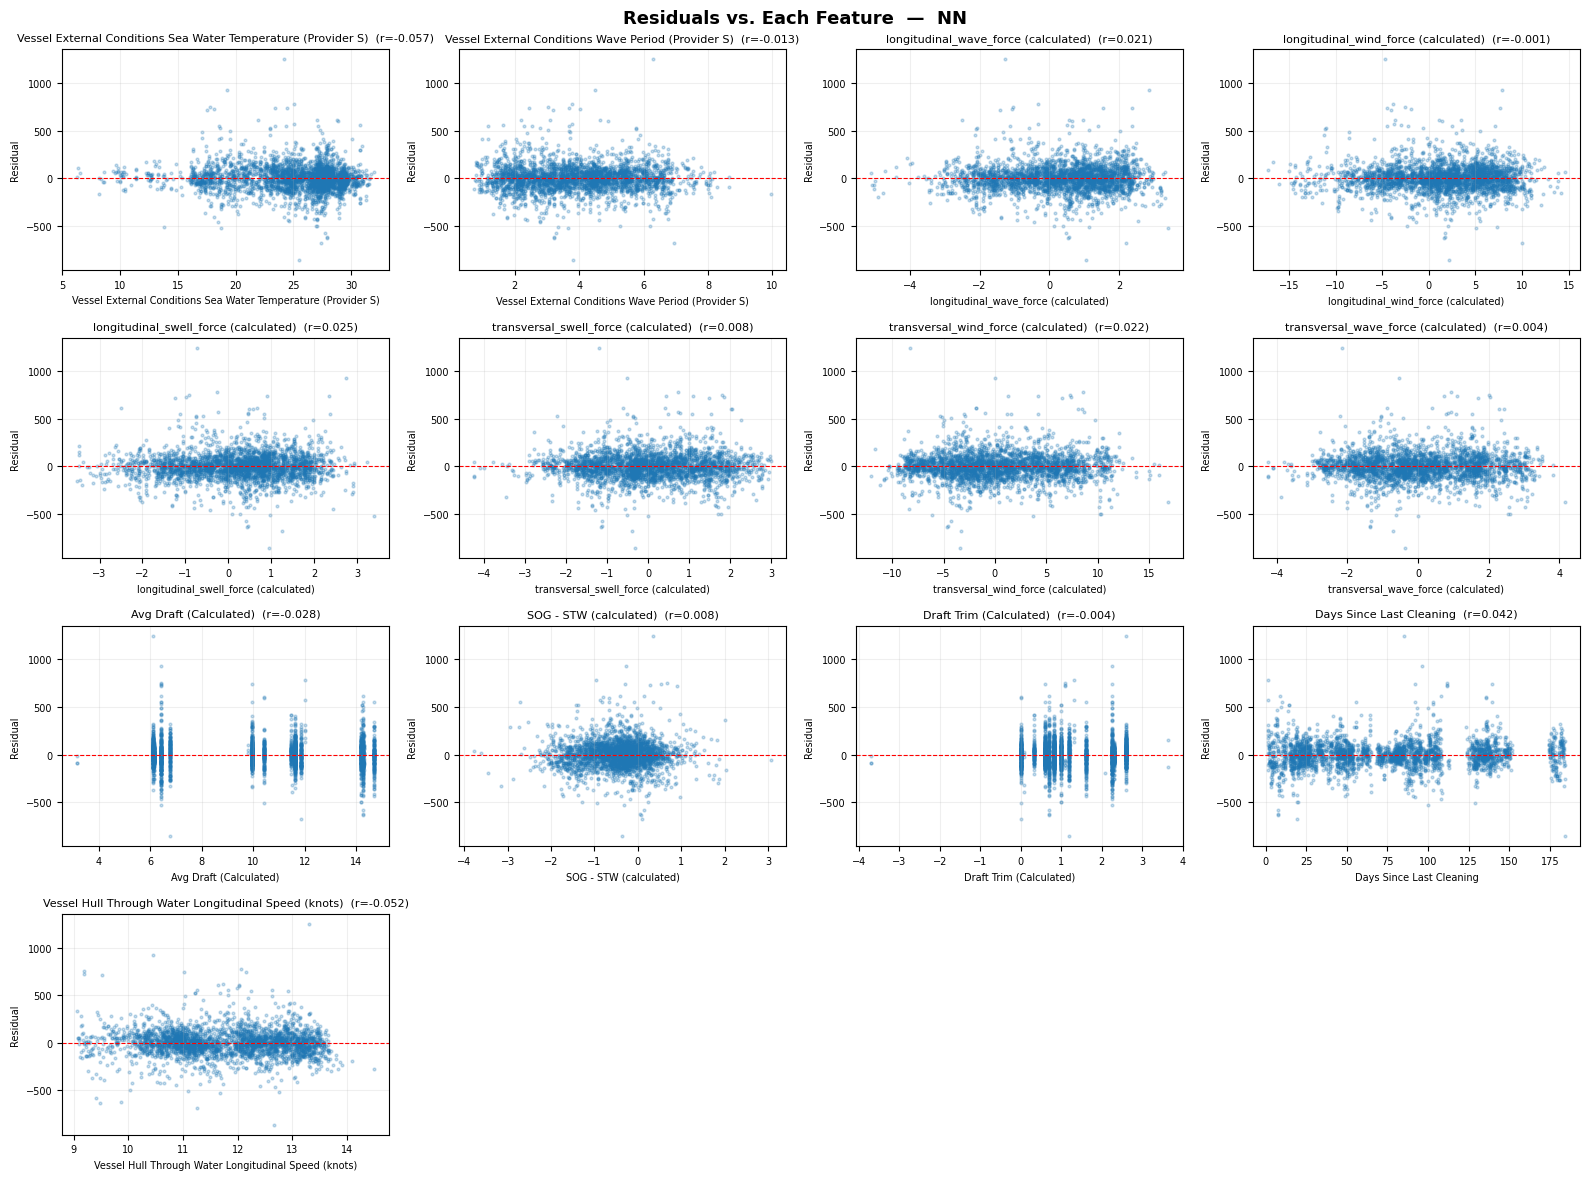


Correlation of each feature with model residuals:


,Vessel External Conditions Sea Water Temperature (Provider S),Vessel External Conditions Wave Period (Provider S),longitudinal_wave_force (calculated),longitudinal_wind_force (calculated),longitudinal_swell_force (calculated),transversal_swell_force (calculated),transversal_wind_force (calculated),transversal_wave_force (calculated),Avg Draft (Calculated),SOG - STW (calculated),Draft Trim (Calculated),Days Since Last Cleaning,Vessel Hull Through Water Longitudinal Speed (knots)
Model \ Feature,,,,,,,,,,,,,
ridge_regression,0.000,0.017,0.005,-0.003,0.014,0.055,0.055,0.052,0.025,0.017,-0.020,-0.016,-0.006
GAM,0.053,0.005,-0.040,-0.026,-0.064,0.031,0.028,0.028,0.018,-0.007,-0.017,-0.039,0.001
random_forest,0.008,0.103,0.050,0.055,0.040,0.052,0.072,0.062,-0.032,0.118,0.060,0.000,0.034
NN,-0.057,-0.013,0.021,-0.001,0.025,0.008,0.022,0.004,-0.028,0.008,-0.004,0.042,-0.052


In [152]:
corr_df = plot_residuals_by_feature(model_pipelines_incl_foul, X_test, y_test)

# 3. Analysis

## 3.1. GAM - specific

### 3.1.1.  Partial effect of fouling

In [153]:
def visualize_fouling_dependence(
    X: pd.DataFrame,
    speed_foul_tensor: bool = True,
    n_grid: int = 100,
    figsize_2d: tuple = (8, 6),
    figsize_3d: tuple = (10, 7),
    fouling_marker_values: list[float] | None = None,
    shaded_mean_max_areas: list[tuple[float, float]] | None = None,
):
    # ── 1. Extract internals ────────────────────────────────────────────────
    pipeline     = model_pipelines_incl_foul["GAM"]
    feature_cols = list(pipeline.named_steps["preprocessor"].transformers[0][2])
    gam_model    = pipeline.named_steps["model"].gam_model_
    scaler       = pipeline.named_steps["preprocessor"].transformers_[0][1]

    X_scaled = pipeline.named_steps["preprocessor"].transform(X)

    fouling_idx = feature_cols.index(FOULING_PROXY_VAR_NAME_WITH_UNIT)
    speed_idx   = feature_cols.index(SPEED_VARIABLE)

    # ── 2. Find term index ──────────────────────────────────────────────────
    def find_term_index(gam, feature_idx, is_tensor=False):
        for i, term in enumerate(gam.terms):
            if is_tensor:
                if getattr(term, "istensor", False):
                    return i
            else:
                if not getattr(term, "istensor", False):
                    if getattr(term, "feature", None) == feature_idx:
                        return i
        raise ValueError(f"Could not locate term for feature index {feature_idx}")

    def inv_scale(values, col_idx):
        return values * scaler.scale_[col_idx] + scaler.mean_[col_idx]

    # ── 3a. 2D plot – additive fouling term ─────────────────────────────────
    if not speed_foul_tensor:
        term_idx = find_term_index(gam_model, fouling_idx, is_tensor=False)

        X_grid_2d = gam_model.generate_X_grid(term=term_idx)
        pdep, confi = gam_model.partial_dependence(
            term=term_idx, X=X_grid_2d, width=0.95
        )
        foul_orig     = inv_scale(X_grid_2d[:, fouling_idx], fouling_idx)
        foul_raw_orig = inv_scale(X_scaled[:, fouling_idx], fouling_idx)

        # Keep the plotting/interpolation arrays sorted by fouling value.
        sort_idx = np.argsort(foul_orig)
        foul_orig = foul_orig[sort_idx]
        pdep = pdep[sort_idx]
        confi = confi[sort_idx]

        # ── Stacked layout: PDP on top, histogram below ─────────────────────
        fig, (ax_pdp, ax_hist) = plt.subplots(
            2, 1,
            figsize=figsize_2d,
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
        )

        if shaded_mean_max_areas:
            for i, (mean_val, max_val) in enumerate(shaded_mean_max_areas):
                x0, x1 = sorted((float(mean_val), float(max_val)))
                label = "Low data coverage" if i == 0 else None
                ax_pdp.axvspan(x0, x1, color="grey", alpha=0.12, zorder=0, label=label)
                ax_hist.axvspan(x0, x1, color="grey", alpha=0.12, zorder=0)

        # Partial dependence
        ax_pdp.plot(foul_orig, pdep, color="steelblue", linewidth=2, label="Partial effect")
        ax_pdp.fill_between(
            foul_orig,
            confi[:, 0],
            confi[:, 1],
            alpha=0.25,
            color="steelblue",
            label="95% CI",
        )

        if fouling_marker_values:
            marker_x = []
            marker_y = []
            x_min = float(np.min(foul_orig))
            x_max = float(np.max(foul_orig))

            for x_val in fouling_marker_values:
                x_val = float(x_val)
                if x_val < x_min or x_val > x_max:
                    print(
                        f"Skipping marker at {x_val:.2f}: outside plotted fouling range "
                        f"[{x_min:.2f}, {x_max:.2f}]."
                    )
                    continue

                y_val = float(np.interp(x_val, foul_orig, pdep))
                marker_x.append(x_val)
                marker_y.append(y_val)

            if marker_x:
                ax_pdp.scatter(
                    marker_x,
                    marker_y,
                    color="darkorange",
                    edgecolor="black",
                    linewidth=0.5,
                    s=45,
                    zorder=4,
                    label="Selected fouling values",
                )

                for x_val, y_val in zip(marker_x, marker_y):
                    ax_pdp.annotate(
                        f"{x_val:.1f}, {y_val:.1f} kW",
                        (x_val, y_val),
                        textcoords="offset points",
                        xytext=(6, 6),
                        fontsize=8,
                        color="darkorange",
                        bbox=dict(
                            boxstyle="round,pad=0.2",
                            facecolor="white",
                            edgecolor="none",
                            alpha=0.75,
                        ),
                    )

        ax_pdp.set_ylabel("Partial effect on shaft power (kW)")
        ax_pdp.set_title("GAM – Partial Effect of DSC on shaft power")
        ax_pdp.legend()
        ax_pdp.grid(alpha=0.3)
        ax_pdp.tick_params(labelbottom=False)  # hide x-tick labels on top plot

        # Histogram of observed fouling values
        ax_hist.hist(
            foul_raw_orig,
            bins=50,
            color="steelblue",
            alpha=0.6,
            edgecolor="none",
        )
        ax_hist.set_xlabel(FOULING_PROXY_VAR_NAME_WITH_UNIT)
        ax_hist.set_ylabel("Count")
        ax_hist.grid(alpha=0.3)
        ax_hist.yaxis.set_major_locator(plt.MaxNLocator(3, integer=True))  # keep it tidy

        plt.tight_layout()
        plt.show()

    # ── 3b. 3D plot – tensor product speed × fouling ────────────────────────
    else:
        if fouling_marker_values or shaded_mean_max_areas:
            print(
                "Note: fouling_marker_values and shaded_mean_max_areas are only "
                "applied when speed_foul_tensor=False (2D fouling term)."
            )

        term_idx = find_term_index(gam_model, speed_idx, is_tensor=True)

        speed_lin = np.linspace(
            np.percentile(X_scaled[:, speed_idx], 5),
            np.percentile(X_scaled[:, speed_idx], 95),
            n_grid,
        )
        foul_lin = np.linspace(
            np.percentile(X_scaled[:, fouling_idx], 5),
            np.percentile(X_scaled[:, fouling_idx], 95),
            n_grid,
        )
        speed_grid_scaled, foul_grid_scaled = np.meshgrid(speed_lin, foul_lin)
        n_points = n_grid * n_grid

        col_means   = X_scaled.mean(axis=0)
        X_grid_full = np.tile(col_means, (n_points, 1))
        X_grid_full[:, speed_idx]   = speed_grid_scaled.ravel()
        X_grid_full[:, fouling_idx] = foul_grid_scaled.ravel()

        Z_baseline = gam_model.predict(np.tile(col_means, (1, 1)))[0]
        Z = gam_model.predict(X_grid_full).reshape(n_grid, n_grid) - Z_baseline

        speed_orig = inv_scale(speed_grid_scaled, speed_idx)
        foul_orig  = inv_scale(foul_grid_scaled,  fouling_idx)

        fig = plt.figure(figsize=figsize_3d)
        ax  = fig.add_subplot(111, projection="3d")
        surf = ax.plot_surface(
            speed_orig, foul_orig, Z,
            cmap="viridis", alpha=0.85, linewidth=0, antialiased=True,
        )
        fig.colorbar(surf, ax=ax, shrink=0.5, label="Partial effect (kW)")
        ax.set_xlabel(SPEED_VARIABLE)
        ax.set_ylabel(FOULING_PROXY_VAR_NAME_WITH_UNIT)
        ax.set_zlabel("Δ Shaft power vs. mean conditions (kW)")
        ax.set_title("GAM – Speed × DSC: Effect on Shaft Power")
        plt.tight_layout()
        plt.show()

C:\Users\Augus\AppData\Local\Temp\ipykernel_23480\1850017014.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


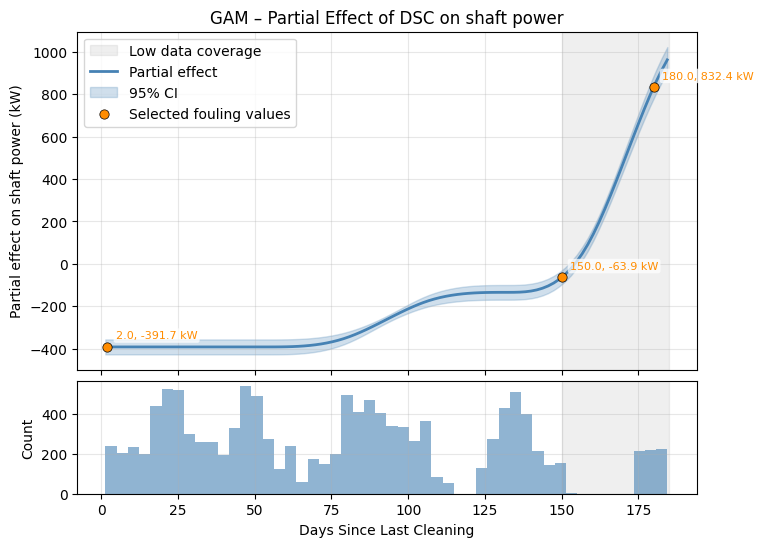

In [154]:
visualize_fouling_dependence(
    X=X_train,
    shaded_mean_max_areas = [(150,185)],
    fouling_marker_values = [2,150, 180],
    speed_foul_tensor = False,
)

### 3.1.2. Partial effect of other features

In [155]:
def visualize_all_terms_with_hist(
    X: pd.DataFrame,
    pipeline,
    n_grid: int = 100,
    n_cols: int = 2,              # 2 features per row
    figsize_per_col: tuple = (6, 4),
):
    """
    For each 1D GAM term: stacked layout (PDP + histogram), arranged with
    `n_cols` features per row, each feature looking like visualize_fouling_dependence.
    """
    # ── 1. Extract internals ────────────────────────────────────────────────
    feature_cols = list(pipeline.named_steps["preprocessor"].transformers[0][2])
    n_continuous = len(feature_cols)
    gam_model    = pipeline.named_steps["model"].gam_model_
    scaler       = pipeline.named_steps["preprocessor"].transformers_[0][1]

    X_scaled = pipeline.named_steps["preprocessor"].transform(X)

    def inv_scale(values, col_idx):
        return values * scaler.scale_[col_idx] + scaler.mean_[col_idx]

    # Collect indices of all non‑intercept, non‑tensor, continuous terms
    # (skip voyage dummies — PDP on binary 0/1 features is not meaningful)
    term_info = []
    for term_idx, term in enumerate(gam_model.terms):
        if term.isintercept:
            continue
        if getattr(term, "istensor", False):
            continue
        col_idx = term.feature
        if col_idx >= n_continuous:
            continue
        term_info.append((term_idx, col_idx))

    n_terms = len(term_info)
    if n_terms == 0:
        print("No 1D terms found.")
        return

    # ── 2. Prepare figure grid ──────────────────────────────────────────────
    n_rows = int(np.ceil(n_terms / n_cols))
    # 2 rows per feature (PDP + hist)
    fig_width  = figsize_per_col[0] * n_cols
    fig_height = figsize_per_col[1] * 2 * n_rows

    fig, axes = plt.subplots(
        n_rows * 2,
        n_cols,
        figsize=(fig_width, fig_height),
        sharex=False,
        gridspec_kw={"hspace": 0.35},
    )
    axes = np.atleast_2d(axes)

    # ── 3. Loop over terms ──────────────────────────────────────────────────
    for k, (term_idx, col_idx) in enumerate(term_info):
        term      = gam_model.terms[term_idx]
        feat_name = feature_cols[col_idx]

        # grid + partial dependence in scaled space
        X_grid = gam_model.generate_X_grid(term=term_idx)
        pdep, confi = gam_model.partial_dependence(
            term=term_idx, X=X_grid, width=0.95
        )

        x_grid_orig = inv_scale(X_grid[:, col_idx], col_idx)
        x_raw_orig  = inv_scale(X_scaled[:, col_idx], col_idx)

        row = k // n_cols
        col = k % n_cols

        ax_pdp  = axes[2 * row,     col]
        ax_hist = axes[2 * row + 1, col]

        # ── PDP (same style as fouling plot) ────────────────────────────────
        ax_pdp.plot(
            x_grid_orig,
            pdep,
            color="steelblue",
            linewidth=2,
            label="Partial effect",
        )
        ax_pdp.fill_between(
            x_grid_orig,
            confi[:, 0],
            confi[:, 1],
            alpha=0.25,
            color="steelblue",
            label="95% CI",
        )
        ax_pdp.axhline(0.0, color="black", linewidth=0.8, linestyle="--")
        ax_pdp.set_ylabel("Partial effect")
        ax_pdp.set_title(feat_name)
        ax_pdp.grid(alpha=0.3)
        ax_pdp.tick_params(labelbottom=False)

        # Add legend only to first subplot to save space
        if k == 0:
            ax_pdp.legend()

        # ── Histogram (same style as fouling plot) ──────────────────────────
        ax_hist.hist(
            x_raw_orig,
            bins=50,
            color="steelblue",
            alpha=0.6,
            edgecolor="none",
        )
        ax_hist.set_xlabel(feat_name)
        ax_hist.set_ylabel("Count")
        ax_hist.grid(alpha=0.3)
        ax_hist.yaxis.set_major_locator(plt.MaxNLocator(3, integer=True))

    # Hide any unused axes
    total_cells = (n_rows * 2) * n_cols
    used_cells  = len(term_info) * 2
    if used_cells < total_cells:
        for i in range(used_cells, total_cells):
            axes.flat[i].set_visible(False)

    plt.tight_layout()
    plt.show()

C:\Users\Augus\AppData\Local\Temp\ipykernel_23480\2486992578.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


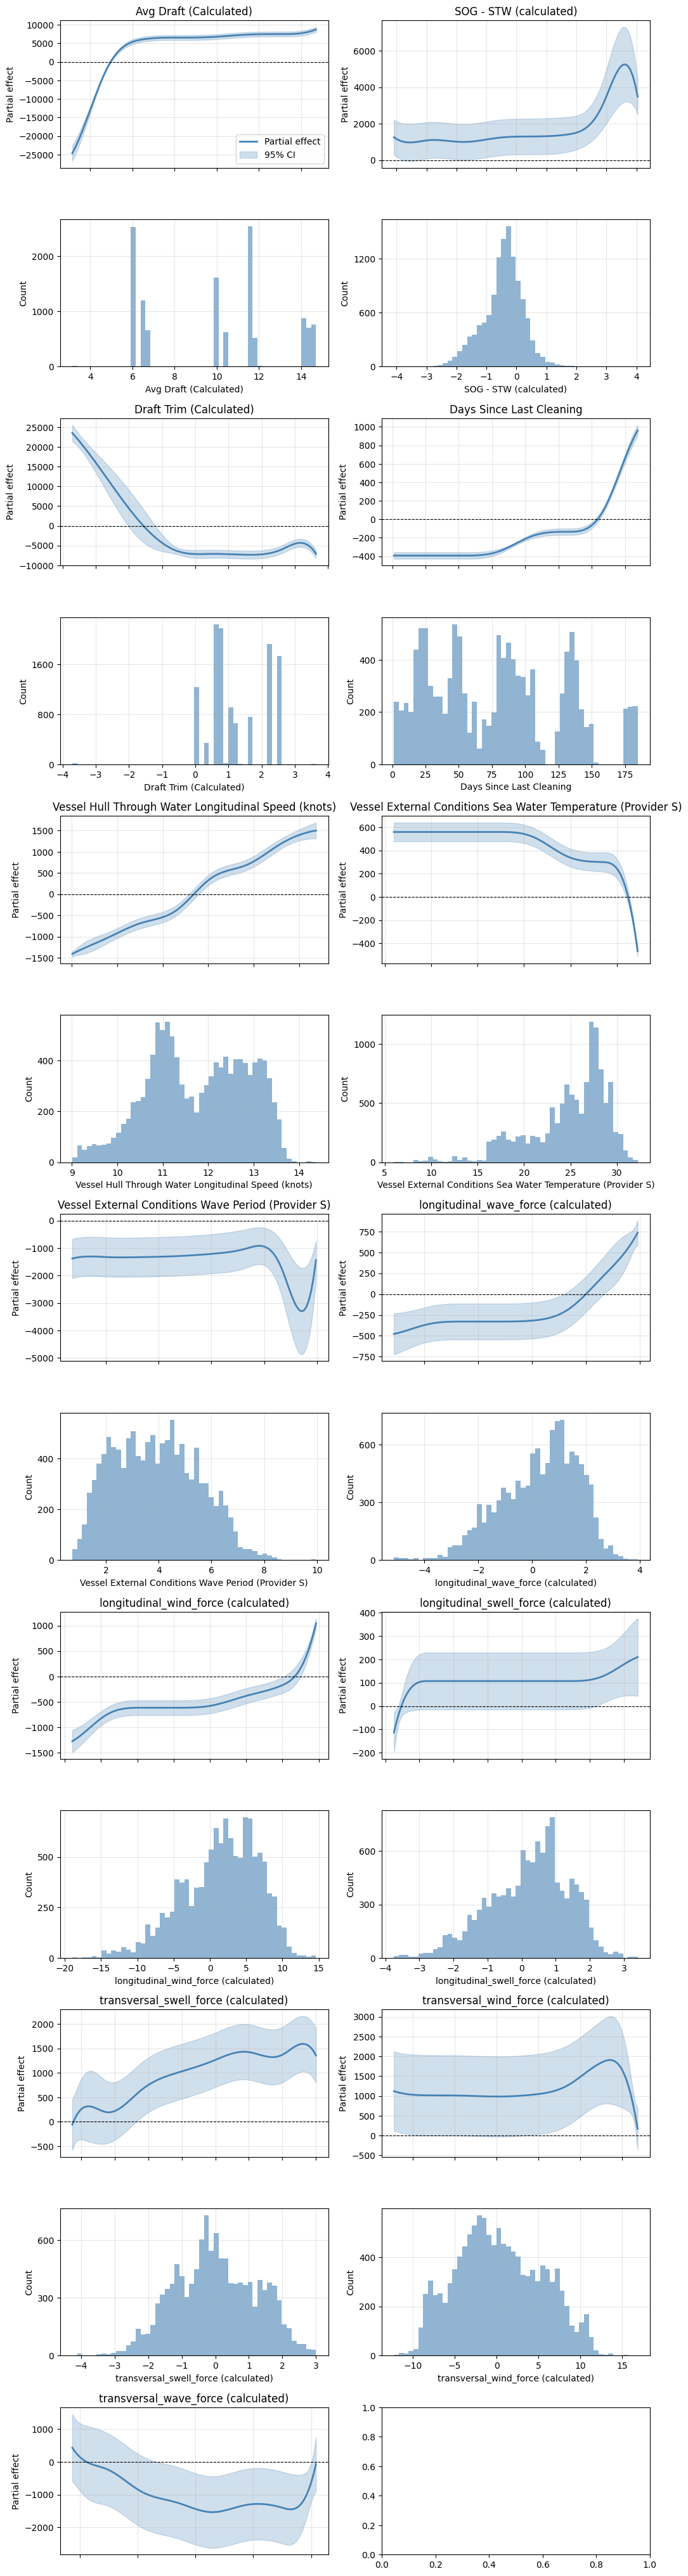

In [156]:
visualize_all_terms_with_hist(
    X=X_train,
    pipeline=model_pipelines_incl_foul["GAM"],
    n_grid=100,
    n_cols=2,                    # two features per line
    figsize_per_col=(6, 4),      # tweak if still cramped
)


## 3.2. Black Box-specific

In [157]:
from typing import Optional, List

valid_data_space = [0.0,150]

def plot_cice_with_global_pdp(
    model,
    preprocess,
    X: pd.DataFrame,
    feature_name: str,
    group_mask=None,
    model_name_for_title=None,
    n_samples: int = 200,
    grid_points: int = 60,
    alpha_ice: float = 0.08,
    color_ice: str = "tab:blue",
    color_pdp: str = "black",
    title_prefix: str = "",
    random_state: int = 42,
    valid_data_space: Optional[List[float]] = None,
):
    """
    Plot centered ICE (c-ICE) curves and a globally calculated PDP for a single feature.
    PDP is calculated on the full subset to ensure accuracy; ICE curves are sampled for visual clarity.
    All curves are centered at 0 for the lowest feature value to isolate the feature's effect.
    The histogram reflects the coverage of the ENTIRE dataset (X), not just the subset.
    """

    # 1. Determine which observations to use for the entire subset
    if group_mask is None:
        X_sub = X.copy()
    elif isinstance(group_mask, pd.Series) and pd.api.types.is_bool_dtype(group_mask):
        if group_mask.index.equals(X.index):
            X_sub = X.loc[group_mask].copy()
        elif len(group_mask) == len(X):
            X_sub = X.iloc[group_mask.to_numpy(dtype=bool)].copy()
        else:
            raise ValueError(
                "Boolean Series group_mask must have the same index as X or the same length as X."
            )
    else:
        mask_array = np.asarray(group_mask)
        if mask_array.dtype == bool:
            if mask_array.shape[0] != len(X):
                raise ValueError(
                    f"Boolean group_mask length ({mask_array.shape[0]}) does not match len(X) ({len(X)})."
                )
            X_sub = X.iloc[mask_array].copy()
        else:
            X_sub = X.loc[group_mask].copy()

    if len(X_sub) == 0:
        raise ValueError("No rows selected for ICE after applying group_mask.")

    # 2. Build feature grid (central observed range)
    f_min, f_max = X[feature_name].quantile([0.01, 0.99])
    feature_grid = np.linspace(f_min, f_max, grid_points)

    # 3. Calculate Global PDP (Using full X_sub)
    # To save memory on large datasets, we average predictions grid-point by grid-point
    global_pdp_vals = np.zeros(grid_points)
    for j, val in enumerate(feature_grid):
        X_tmp_full = X_sub.copy()
        X_tmp_full[feature_name] = val
        X_tmp_full_trans = preprocess.transform(X_tmp_full)
        global_pdp_vals[j] = model.predict(X_tmp_full_trans).mean()
        
    # Center the global PDP
    global_pdp_centered = global_pdp_vals - global_pdp_vals[0]

    # 4. Sample rows for ICE curve visualization
    rng = np.random.default_rng(random_state)
    n_samples_actual = min(n_samples, len(X_sub))
    sample_idx = rng.choice(len(X_sub), size=n_samples_actual, replace=False)
    X_sample = X_sub.iloc[sample_idx].copy()

    ice_vals = np.zeros((n_samples_actual, grid_points))

    # Calculate predictions for sampled ICE curves
    for j, val in enumerate(feature_grid):
        X_tmp_sample = X_sample.copy()
        X_tmp_sample[feature_name] = val
        X_tmp_sample_trans = preprocess.transform(X_tmp_sample)
        ice_vals[:, j] = model.predict(X_tmp_sample_trans)

    # Center the ICE curves (subtract the first column from all columns)
    ice_vals_centered = ice_vals - ice_vals[:, 0:1]

    # 5. Plot c-ICE + Global c-PDP with histogram below
    fig = plt.figure(figsize=(8, 6))
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)

    ax_main = fig.add_subplot(gs[0, 0])
    ax_hist = fig.add_subplot(gs[1, 0], sharex=ax_main)

    # Plot Centered ICE curves
    for i in range(ice_vals_centered.shape[0]):
        ax_main.plot(feature_grid, ice_vals_centered[i, :],
                     color=color_ice, alpha=alpha_ice, linewidth=0.7)

    # Plot Global Centered PDP curve
    ax_main.plot(feature_grid, global_pdp_centered,
                 color=color_pdp, linewidth=2.5, label=f"Global c-PDP (n={len(X_sub)})")
    
    # Add a horizontal line at 0 for reference
    ax_main.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    ax_main.set_ylabel("Change in Propeller Shaft Power (kW)")
    ax_main.grid(True, alpha=0.3)
    ax_main.legend()

    if title_prefix:
        title = f"{title_prefix} – c-ICE & c-PDP for {feature_name} ({model_name_for_title})"
    else:
        title = f"c-ICE & c-PDP for {feature_name}"
    ax_main.set_title(title)

    # Preserve y-limits for shading
    y_min, y_max = ax_main.get_ylim()

    # 6. Shade low-data regions, if requested
    if valid_data_space is not None:
        if (not isinstance(valid_data_space, (list, tuple)) or len(valid_data_space) != 2):
            raise ValueError("valid_data_space must be a list/tuple of two floats [low, high].")
        v_low, v_high = float(valid_data_space[0]), float(valid_data_space[1])

        def shade_region(x0, x1):
            if x1 <= x0:
                return
            ax_main.axvspan(x0, x1, ymin=0, ymax=1, color="lightgrey", alpha=0.4, zorder=-1)
            x_text = (x0 + x1) / 2.0
            ax_main.text(x_text, y_max - 0.05 * (y_max - y_min), "low data coverage",
                         color="dimgray", fontsize=9, ha="center", va="top", alpha=0.9)

        if v_low > f_min:
            shade_region(f_min, v_low)
        if v_high < f_max:
            shade_region(v_high, f_max)

        valid_mask = (feature_grid >= v_low) & (feature_grid <= v_high)
    else:
        valid_mask = np.ones_like(feature_grid, dtype=bool)

    ax_main.set_ylim(y_min, y_max)

    # Mark min and max PDP within valid data area
    if valid_mask.any():
        fg_valid = feature_grid[valid_mask]
        pdp_valid = global_pdp_centered[valid_mask]

        min_idx = np.argmin(pdp_valid)
        max_idx = np.argmax(pdp_valid)

        x_min, y_min_pdp = fg_valid[min_idx], pdp_valid[min_idx]
        x_max, y_max_pdp = fg_valid[max_idx], pdp_valid[max_idx]

        ax_main.scatter([x_min], [y_min_pdp], color="green", s=40, zorder=5)
        ax_main.scatter([x_max], [y_max_pdp], color="green", s=40, zorder=5)

        ax_main.text(x_min, y_min_pdp - 0.03 * (y_max - y_min), f"min: {y_min_pdp:.0f} kW",
                     color="green", fontsize=9, ha="center", va="top")
        
        ax_main.text(x_max, y_max_pdp + 0.03 * (y_max - y_min), f"max: {y_max_pdp:.0f} kW",
                     color="green", fontsize=9, ha="center", va="bottom")

    # Histogram of data coverage (Using entire dataset X, not X_sub)
    ax_hist.hist(X[feature_name], bins=30, color="tab:blue", alpha=0.6)
    ax_hist.set_ylabel("Total Count")
    ax_hist.set_xlabel(feature_name)

    plt.setp(ax_main.get_xticklabels(), visible=False)
    plt.tight_layout()
    plt.show()


### 3.2.1. Partial dependence on speed (pseudo speed-power curves)

In [158]:
rf_model_incl_fouling = model_pipelines_incl_foul["random_forest"].named_steps["model"]
nn_model_incl_fouling = model_pipelines_incl_foul["NN"].named_steps["model"]

black_boxes = {
#    "Random Forest": rf_model_incl_fouling,
    "Neural Network": nn_model_incl_fouling,
}

preprocessors = {
#    "Random Forest": model_pipelines_incl_foul["random_forest"].named_steps["preprocessor"],
    "Neural Network": model_pipelines_incl_foul["NN"].named_steps["preprocessor"],
}

C:\Users\Augus\AppData\Local\Temp\ipykernel_23480\737150665.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


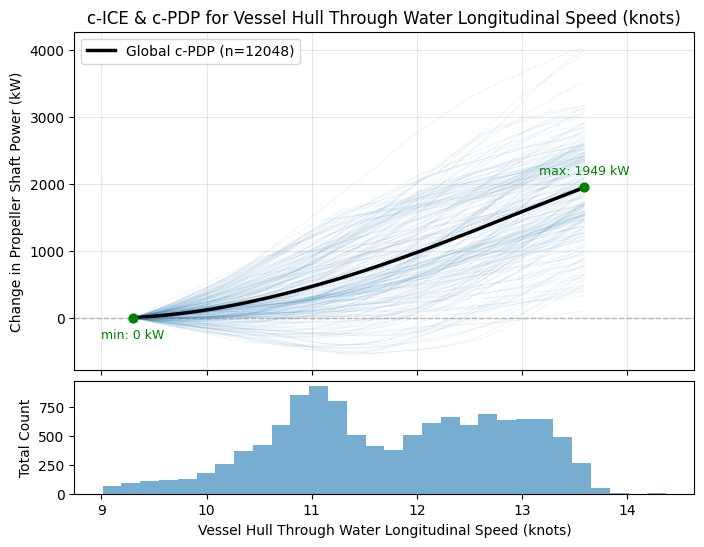

In [159]:
for model_name, model in black_boxes.items():
    plot_cice_with_global_pdp(
        model=model,             # RF trained on preprocessed data
        preprocess=preprocessors[model_name],                   # your fitted scaler / ColumnTransformer
        X=X_train,                           # raw validation features (DataFrame)
        feature_name= "Vessel Hull Through Water Longitudinal Speed (knots)",
        model_name_for_title=model_name,
        valid_data_space=valid_data_space
    ,
    )

### 3.2.2. ICE plots

What we want to see is nice and upward sloping curves that are somewhat parallel, especially when stratifying

C:\Users\Augus\AppData\Local\Temp\ipykernel_23480\737150665.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


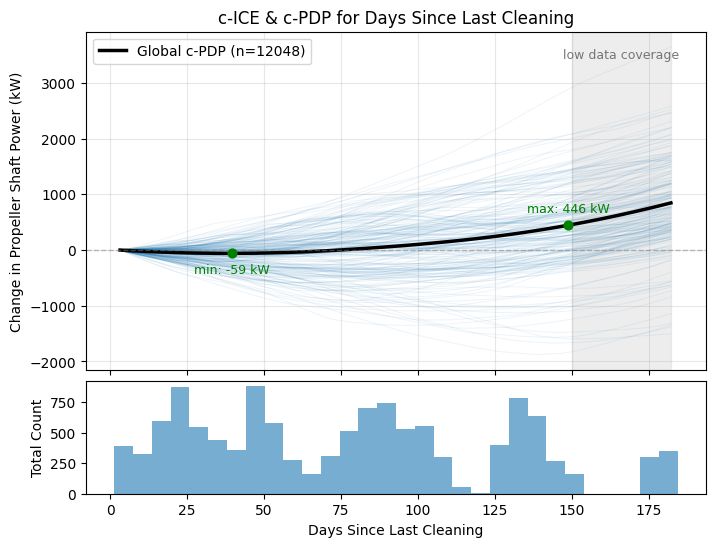

In [160]:
for model_name, model in black_boxes.items():
    plot_cice_with_global_pdp(
        model=model,             # RF trained on preprocessed data
        preprocess=preprocessors[model_name],                   # your fitted scaler / ColumnTransformer
        X=X_train,                           # raw validation features (DataFrame)
        feature_name= FOULING_PROXY_VAR_NAME_WITH_UNIT,
        model_name_for_title=model_name,
        valid_data_space=valid_data_space
    ,
    )

C:\Users\Augus\AppData\Local\Temp\ipykernel_23480\737150665.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


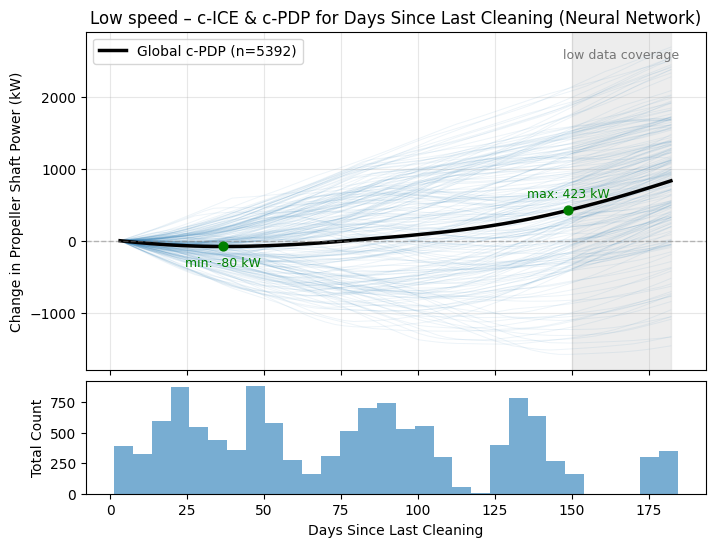

C:\Users\Augus\AppData\Local\Temp\ipykernel_23480\737150665.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


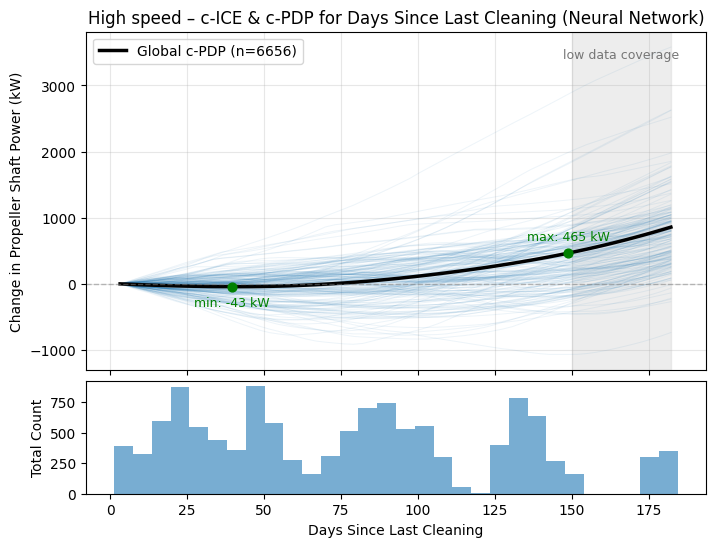

In [161]:
speed_col = "Vessel Hull Through Water Longitudinal Speed (knots)"
fouling_col = FOULING_PROXY_VAR_NAME_WITH_UNIT

# Define speed bands (adjust thresholds to your data)
low_speed_mask  = X_train[speed_col] < 11.5
high_speed_mask = X_train[speed_col] >= 11.5

for model_name, model in black_boxes.items():
    # Low-speed ICE for fouling
    plot_cice_with_global_pdp(
        model=model,
        preprocess=preprocessors[model_name],
        X=X_train,
        feature_name=fouling_col,
        group_mask=low_speed_mask,
        title_prefix="Low speed",
        model_name_for_title=model_name,
        valid_data_space=valid_data_space
    )

    # High-speed ICE for fouling
    plot_cice_with_global_pdp(
        model=model,
        preprocess=preprocessors[model_name],
        X=X_train,
        feature_name=fouling_col,
        group_mask=high_speed_mask,
        title_prefix="High speed",
        model_name_for_title=model_name,
        valid_data_space=valid_data_space
    )


Draft 6.42 m: 1197 observations in [6.32, 6.52]


C:\Users\Augus\AppData\Local\Temp\ipykernel_23480\737150665.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


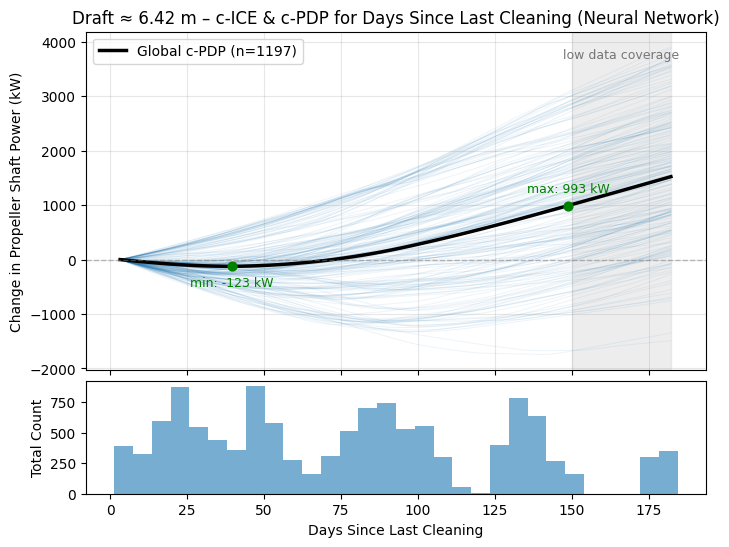

Draft 6.75 m: 655 observations in [6.65, 6.85]


C:\Users\Augus\AppData\Local\Temp\ipykernel_23480\737150665.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


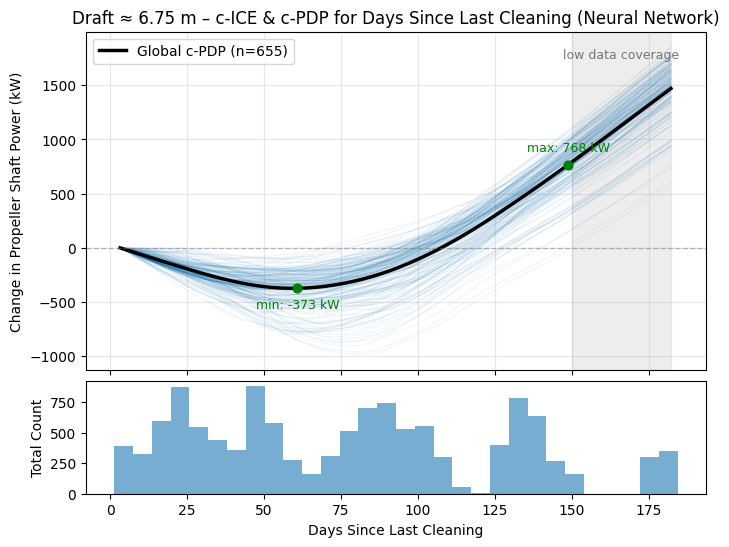

Draft 14.25 m: 1573 observations in [14.15, 14.35]


C:\Users\Augus\AppData\Local\Temp\ipykernel_23480\737150665.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


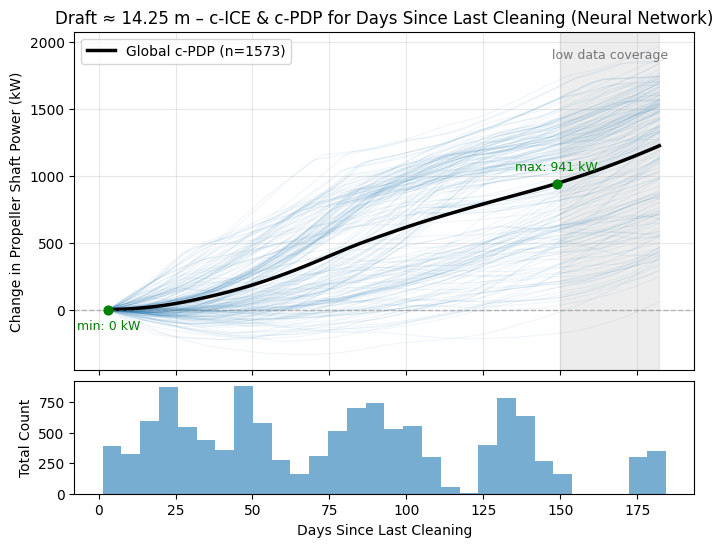

In [162]:
draft_col = "Avg Draft (Calculated)"
drafts_to_test = [6.42, 6.75, 14.25]
tol = 0.1  # meters
fouling_col = FOULING_PROXY_VAR_NAME_WITH_UNIT


for model_name, model in black_boxes.items():
    for target_draft in drafts_to_test:
        mask = (
            (X_train[draft_col] >= target_draft - tol) &
            (X_train[draft_col] <= target_draft + tol)
        )

        print(
            f"Draft {target_draft:.2f} m: "
            f"{mask.sum()} observations in [{target_draft - tol:.2f}, {target_draft + tol:.2f}]"
        )

        if mask.sum() < 20:   # require a minimum sample size
            continue

        plot_cice_with_global_pdp(
            model=model,
            preprocess=preprocessors[model_name],
            X=X_train,
            feature_name=fouling_col,
            group_mask=mask,
            title_prefix=f"Draft ≈ {target_draft:.2f} m",
            n_samples=min(200, mask.sum()),
            model_name_for_title=model_name,
            valid_data_space=valid_data_space
        )


### 3.2.3. ALE plots

In [163]:
def plot_ale_1d(
    model,
    preprocess,
    X: pd.DataFrame,
    feature_name: str,
    group_mask=None,
    title_suffix: str = "",
    model_name_for_title: str | None = None,
    n_bins: int = 20,
    figsize: tuple = (8, 6),
    show_data_coverage: bool = True,
    color: str = "tab:blue",
    fouling_marker_values: list[float] | None = None,
    shaded_mean_max_areas: list[tuple[float, float]] | None = None,
):
    """
    Plot first-order ALE for one feature with optional stacked data-support histogram.

    Top panel: ALE curve.
    Bottom panel: Histogram of selected feature values (subset used for ALE).

    Parameters
    ----------
    model : fitted estimator
        Must implement .predict() on preprocessed features.
    preprocess : fitted transformer
        Must implement .transform() from raw X to model input.
    X : pd.DataFrame
        Raw feature dataframe.
    feature_name : str
        Feature for ALE.
    group_mask : optional
        Boolean mask or index-like subset of X.
    model_name_for_title : str | None
        Optional model name for title.
    n_bins : int
        Number of quantile bins.
    figsize : tuple
        Figure size.
    show_data_coverage : bool
        If True, include the bottom histogram.
    color : str
        Line and histogram color.
    fouling_marker_values : list[float] | None
        Optional x-values to mark on ALE curve with (x, y) annotations.
    shaded_mean_max_areas : list[tuple[float, float]] | None
        Optional (mean, max) x-ranges to lightly shade.

    Returns
    -------
    pd.DataFrame
        Columns: bin_left, bin_right, bin_center, n_obs, local_effect, ale
    """
    if feature_name not in X.columns:
        raise KeyError(f"Feature '{feature_name}' not found in X columns.")

    if group_mask is None:
        X_sub = X.copy()
    elif isinstance(group_mask, pd.Series) and pd.api.types.is_bool_dtype(group_mask):
        aligned_mask = group_mask.reindex(X.index, fill_value=False)
        X_sub = X.loc[aligned_mask].copy()
    else:
        mask_array = np.asarray(group_mask)
        if mask_array.dtype == bool:
            if mask_array.shape[0] != len(X):
                raise ValueError(
                    f"Boolean group_mask length ({mask_array.shape[0]}) does not match len(X) ({len(X)})."
                )
            X_sub = X.iloc[mask_array].copy()
        else:
            X_sub = X.loc[group_mask].copy()

    if len(X_sub) == 0:
        raise ValueError("No rows selected for ALE after applying group_mask.")

    x_vals = X_sub[feature_name].to_numpy(dtype=float)

    # Quantile bins in the selected subset
    raw_edges = np.quantile(x_vals, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(raw_edges)
    if len(edges) < 2:
        raise ValueError(
            f"Feature '{feature_name}' has insufficient variation for ALE in selected data."
        )

    K = len(edges) - 1
    local_effects = np.zeros(K, dtype=float)
    counts = np.zeros(K, dtype=int)

    for k in range(K):
        left, right = edges[k], edges[k + 1]

        if k < K - 1:
            mask_k = (x_vals >= left) & (x_vals < right)
        else:
            mask_k = (x_vals >= left) & (x_vals <= right)

        idx = np.where(mask_k)[0]
        counts[k] = len(idx)

        if len(idx) == 0:
            continue

        X_low = X_sub.iloc[idx].copy()
        X_high = X_sub.iloc[idx].copy()
        X_low[feature_name] = left
        X_high[feature_name] = right

        pred_low = model.predict(preprocess.transform(X_low))
        pred_high = model.predict(preprocess.transform(X_high))

        local_effects[k] = float(np.mean(pred_high - pred_low))

    # Accumulate from local effects to ALE (piecewise approximation at bin centers)
    ale_edges = np.concatenate([[0.0], np.cumsum(local_effects)])
    ale_vals = 0.5 * (ale_edges[:-1] + ale_edges[1:])

    # Center ALE: weighted mean zero over empirical feature distribution
    if counts.sum() > 0:
        ale_vals = ale_vals - np.average(ale_vals, weights=np.maximum(counts, 1))

    centers = 0.5 * (edges[:-1] + edges[1:])
    sort_idx = np.argsort(centers)
    centers = centers[sort_idx]
    ale_vals = ale_vals[sort_idx]

    ale_df = pd.DataFrame(
        {
            "bin_left": edges[:-1],
            "bin_right": edges[1:],
            "bin_center": centers,
            "n_obs": counts,
            "local_effect": local_effects,
            "ale": ale_vals,
        }
    )

    # ---- Plot ----
    if show_data_coverage:
        fig, (ax_main, ax_hist) = plt.subplots(
            2, 1,
            figsize=figsize,
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
        )
    else:
        fig, ax_main = plt.subplots(figsize=figsize)
        ax_hist = None

    if shaded_mean_max_areas:
        for i, (mean_val, max_val) in enumerate(shaded_mean_max_areas):
            x0, x1 = sorted((float(mean_val), float(max_val)))
            label = "Low data coverage" if i == 0 else None
            ax_main.axvspan(x0, x1, color="grey", alpha=0.12, zorder=0, label=label)
            if ax_hist is not None:
                ax_hist.axvspan(x0, x1, color="grey", alpha=0.12, zorder=0)

    ax_main.plot(centers, ale_vals, color=color, linewidth=2.2, label="ALE")
    ax_main.axhline(0, color="black", linestyle="--", linewidth=1)

    if fouling_marker_values:
        marker_x = []
        marker_y = []
        x_min = float(np.min(centers))
        x_max = float(np.max(centers))

        for x_val in fouling_marker_values:
            x_val = float(x_val)
            if x_val < x_min or x_val > x_max:
                print(
                    f"Skipping marker at {x_val:.2f}: outside plotted range [{x_min:.2f}, {x_max:.2f}]."
                )
                continue

            y_val = float(np.interp(x_val, centers, ale_vals))
            marker_x.append(x_val)
            marker_y.append(y_val)

        if marker_x:
            ax_main.scatter(
                marker_x,
                marker_y,
                color="darkorange",
                edgecolor="black",
                linewidth=0.5,
                s=45,
                zorder=4,
                label="Selected fouling values",
            )

            for x_val, y_val in zip(marker_x, marker_y):
                ax_main.annotate(
                    f"{x_val:.1f}, {y_val:.1f} kW",
                    (x_val, y_val),
                    textcoords="offset points",
                    xytext=(6, 6),
                    fontsize=8,
                    color="darkorange",
                    bbox=dict(
                        boxstyle="round,pad=0.2",
                        facecolor="white",
                        edgecolor="none",
                        alpha=0.75,
                    ),
                )
    ax_main.set_xlabel(feature_name)
    ax_main.set_ylabel(f"ALE on {TARGET_VARIABLE}")
    ax_main.grid(alpha=0.25)

    title = f"ALE: {feature_name}"
    if title_suffix:
        title += f" ({title_suffix})"
    if model_name_for_title:
        title += f" ({model_name_for_title})"
    ax_main.set_title(title)
    ax_main.legend(loc="best")

    if ax_hist is not None:
        ax_hist.hist(
            x_vals,
            bins=min(40, max(10, K)),
            color=color,
            alpha=0.6,
            edgecolor="white",
        )
        ax_hist.set_xlabel(feature_name)
        ax_hist.set_ylabel("Count")
        ax_hist.grid(alpha=0.2)
        ax_hist.yaxis.set_major_locator(plt.MaxNLocator(3, integer=True))
        ax_main.tick_params(labelbottom=False)

    plt.tight_layout()
    plt.show()

    return ale_df

def plot_ale_2d(
    model,
    preprocess,
    X: pd.DataFrame,
    feature_x: str,
    feature_y: str,
    group_mask=None,
    model_name_for_title: str | None = None,
    n_bins_x: int = 12,
    n_bins_y: int = 12,
    figsize: tuple = (16, 6),
    cmap: str = "viridis",
    show_data_coverage: bool = True,
):
    """
    Plot second-order ALE for two features and optionally show data support side-by-side.

    Left panel: 3D ALE surface.
    Right panel: 2D heatmap of two-feature cell counts.

    Parameters
    ----------
    model : fitted estimator
        Must implement .predict() on preprocessed features.
    preprocess : fitted transformer
        Must implement .transform() from raw X to model input.
    X : pd.DataFrame
        Raw feature dataframe.
    feature_x : str
        First feature (x-axis).
    feature_y : str
        Second feature (y-axis).
    group_mask : optional
        Boolean mask or index-like subset of X.
    model_name_for_title : str | None
        Optional model name for title.
    n_bins_x : int
        Number of quantile bins for feature_x.
    n_bins_y : int
        Number of quantile bins for feature_y.
    figsize : tuple
        Figure size.
    cmap : str
        Matplotlib colormap for ALE surface.
    show_data_coverage : bool
        If True, include the right-panel 2D density heatmap.

    Returns
    -------
    dict
        {
            "ale_surface": pd.DataFrame,
            "cell_counts": pd.DataFrame,
            "x_edges": np.ndarray,
            "y_edges": np.ndarray,
        }
    """
    for f in [feature_x, feature_y]:
        if f not in X.columns:
            raise KeyError(f"Feature '{f}' not found in X columns.")

    if group_mask is None:
        X_sub = X.copy()
    elif isinstance(group_mask, pd.Series) and pd.api.types.is_bool_dtype(group_mask):
        aligned_mask = group_mask.reindex(X.index, fill_value=False)
        X_sub = X.loc[aligned_mask].copy()
    else:
        mask_array = np.asarray(group_mask)
        if mask_array.dtype == bool:
            if mask_array.shape[0] != len(X):
                raise ValueError(
                    f"Boolean group_mask length ({mask_array.shape[0]}) does not match len(X) ({len(X)})."
                )
            X_sub = X.iloc[mask_array].copy()
        else:
            X_sub = X.loc[group_mask].copy()

    if len(X_sub) == 0:
        raise ValueError("No rows selected for ALE after applying group_mask.")

    x = X_sub[feature_x].to_numpy(dtype=float)
    y = X_sub[feature_y].to_numpy(dtype=float)

    x_edges = np.unique(np.quantile(x, np.linspace(0, 1, n_bins_x + 1)))
    y_edges = np.unique(np.quantile(y, np.linspace(0, 1, n_bins_y + 1)))

    if len(x_edges) < 2 or len(y_edges) < 2:
        raise ValueError(
            "Insufficient feature variation for 2D ALE with current bins/subset."
        )

    Kx = len(x_edges) - 1
    Ky = len(y_edges) - 1

    delta = np.zeros((Kx, Ky), dtype=float)
    counts = np.zeros((Kx, Ky), dtype=int)

    # Compute local second-order effects in each (x_bin, y_bin)
    for i in range(Kx):
        xl, xu = x_edges[i], x_edges[i + 1]
        x_mask = (x >= xl) & (x < xu) if i < Kx - 1 else (x >= xl) & (x <= xu)

        for j in range(Ky):
            yl, yu = y_edges[j], y_edges[j + 1]
            y_mask = (y >= yl) & (y < yu) if j < Ky - 1 else (y >= yl) & (y <= yu)

            cell_idx = np.where(x_mask & y_mask)[0]
            counts[i, j] = len(cell_idx)

            if len(cell_idx) == 0:
                continue

            X_ll = X_sub.iloc[cell_idx].copy()
            X_lu = X_sub.iloc[cell_idx].copy()
            X_ul = X_sub.iloc[cell_idx].copy()
            X_uu = X_sub.iloc[cell_idx].copy()

            X_ll[feature_x], X_ll[feature_y] = xl, yl
            X_lu[feature_x], X_lu[feature_y] = xl, yu
            X_ul[feature_x], X_ul[feature_y] = xu, yl
            X_uu[feature_x], X_uu[feature_y] = xu, yu

            f_ll = model.predict(preprocess.transform(X_ll))
            f_lu = model.predict(preprocess.transform(X_lu))
            f_ul = model.predict(preprocess.transform(X_ul))
            f_uu = model.predict(preprocess.transform(X_uu))

            # Local second-order effect
            delta[i, j] = float(np.mean(f_uu - f_ul - f_lu + f_ll))

    # Double accumulation to obtain ALE surface on grid cells
    ale_surface = np.cumsum(np.cumsum(delta, axis=0), axis=1)

    # Center surface to weighted mean zero across occupied cells
    if counts.sum() > 0:
        weights = np.where(counts > 0, counts, 0)
        mean_ale = np.sum(ale_surface * weights) / np.sum(weights)
        ale_surface = ale_surface - mean_ale

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    Xg, Yg = np.meshgrid(x_centers, y_centers, indexing="ij")

    # ---- Plot ----
    fig = plt.figure(figsize=figsize)
    if show_data_coverage:
        ax_ale = fig.add_subplot(1, 2, 1, projection="3d")
        ax_cov = fig.add_subplot(1, 2, 2)
    else:
        ax_ale = fig.add_subplot(111, projection="3d")
        ax_cov = None

    surf = ax_ale.plot_surface(
        Xg,
        Yg,
        ale_surface,
        cmap=cmap,
        linewidth=0,
        antialiased=True,
        alpha=0.9,
    )

    cbar = fig.colorbar(surf, ax=ax_ale, shrink=0.65, pad=0.1)
    cbar.set_label("2D ALE effect")

    ale_title = f"2D ALE: {feature_x} x {feature_y}"
    if model_name_for_title:
        ale_title += f" ({model_name_for_title})"
    ax_ale.set_title(ale_title)
    ax_ale.set_xlabel(feature_x)
    ax_ale.set_ylabel(feature_y)
    ax_ale.set_zlabel(f"ALE on {TARGET_VARIABLE}")

    if ax_cov is not None:
        # Heatmap of support counts on the same quantile-bin grid.
        heatmap = ax_cov.pcolormesh(
            x_edges,
            y_edges,
            counts.T,
            cmap="magma",
            shading="auto",
        )
        cov_cbar = fig.colorbar(heatmap, ax=ax_cov, shrink=0.9, pad=0.02)
        cov_cbar.set_label("Count")
        ax_cov.set_title(f"Data support heatmap: {feature_x} x {feature_y}")
        ax_cov.set_xlabel(feature_x)
        ax_cov.set_ylabel(feature_y)

    plt.tight_layout()
    plt.show()

    ale_df = pd.DataFrame(
        ale_surface,
        index=pd.Index(x_centers, name=feature_x),
        columns=pd.Index(y_centers, name=feature_y),
    )
    count_df = pd.DataFrame(
        counts,
        index=pd.Index(x_centers, name=feature_x),
        columns=pd.Index(y_centers, name=feature_y),
    )

    return {
        "ale_surface": ale_df,
        "cell_counts": count_df,
        "x_edges": x_edges,
        "y_edges": y_edges,
    }

C:\Users\Augus\AppData\Local\Temp\ipykernel_23480\2677644259.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


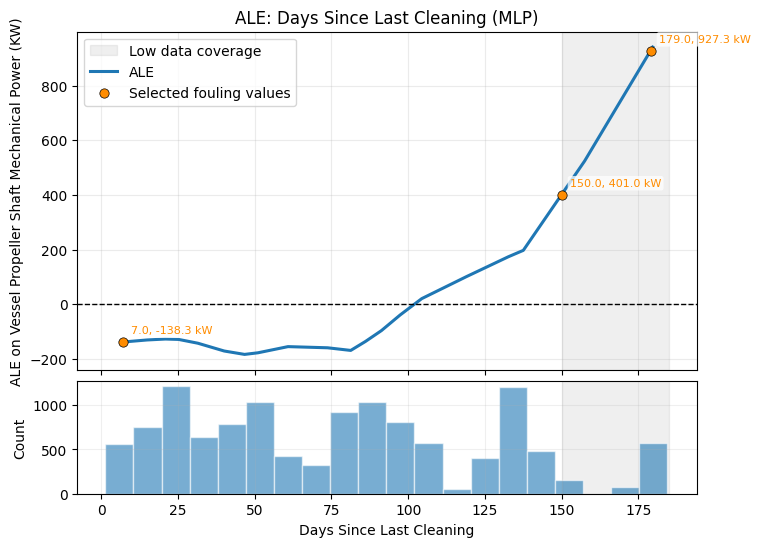

In [164]:
ale_1d = plot_ale_1d(
model=black_boxes["Neural Network"],
preprocess=preprocessors["Neural Network"],
X=X_train,
feature_name=FOULING_PROXY_VAR_NAME_WITH_UNIT,
model_name_for_title="MLP",
show_data_coverage=True,
shaded_mean_max_areas = [(150,185)],
fouling_marker_values = [7,150, 179],
)

C:\Users\Augus\AppData\Local\Temp\ipykernel_23480\2677644259.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


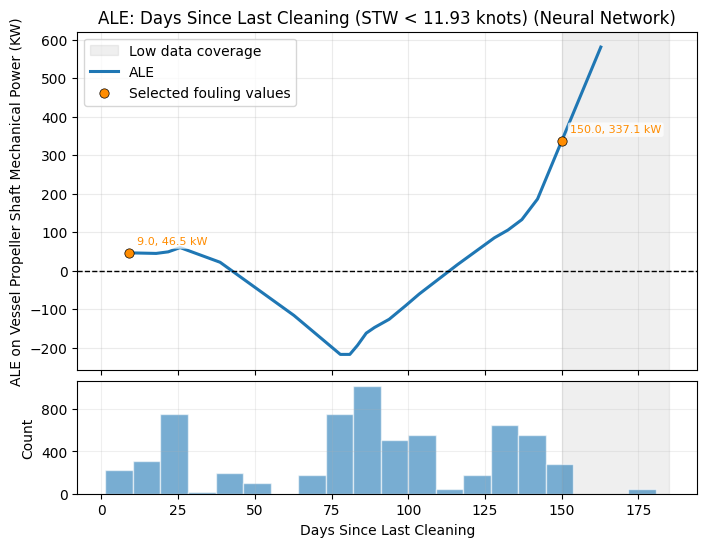

C:\Users\Augus\AppData\Local\Temp\ipykernel_23480\2677644259.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


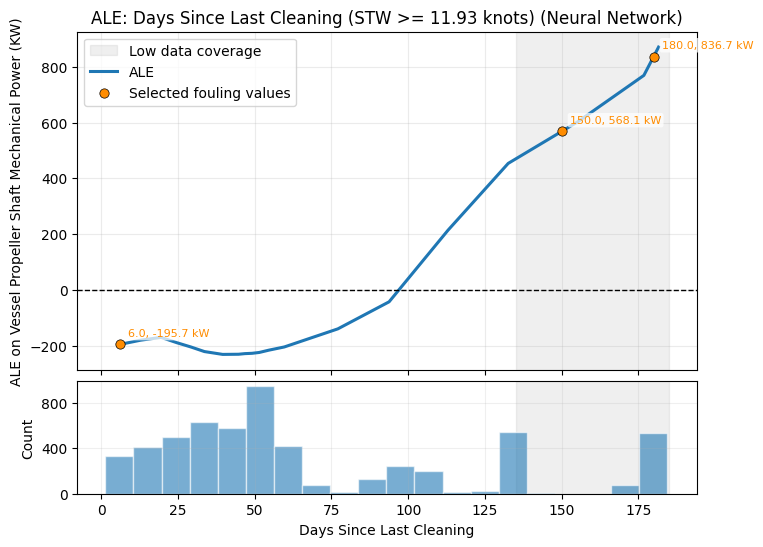

In [165]:
speed_col = "Vessel Hull Through Water Longitudinal Speed (knots)"
fouling_col = FOULING_PROXY_VAR_NAME_WITH_UNIT

speed_threshold = 11.93

# Define two speed bands: below threshold and at-or-above threshold
below_speed_mask = X_train[speed_col] < speed_threshold
at_or_above_speed_mask = X_train[speed_col] >= speed_threshold

for model_name, model in black_boxes.items():
    # Below-threshold ALE for fouling
    plot_ale_1d(
        model=model,
        preprocess=preprocessors[model_name],
        X=X_train,
        feature_name=fouling_col,
        group_mask=below_speed_mask,
        title_suffix=f"STW < {speed_threshold} knots",
        model_name_for_title=model_name,
        show_data_coverage=True,
        shaded_mean_max_areas = [(150,185)],
        fouling_marker_values = [9,150],
    )

    # At-or-above-threshold ALE for fouling
    plot_ale_1d(
        model=model,
        preprocess=preprocessors[model_name],
        X=X_train,
        feature_name=fouling_col,
        group_mask=at_or_above_speed_mask,
        title_suffix=f"STW >= {speed_threshold} knots",
        model_name_for_title=model_name,
        show_data_coverage=True,
        shaded_mean_max_areas = [(135,185)],
        fouling_marker_values = [6,150, 180],
    )

Draft 6.42 m: 1197 observations in [6.32, 6.52]


C:\Users\Augus\AppData\Local\Temp\ipykernel_23480\2677644259.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


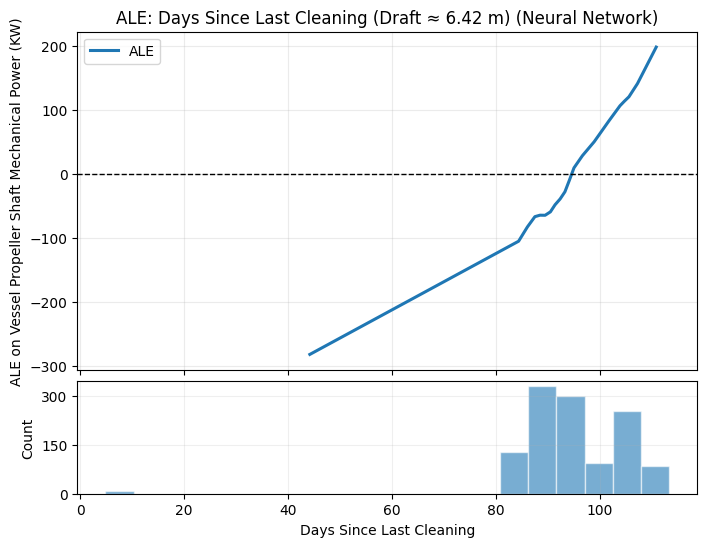

Draft 6.75 m: 655 observations in [6.65, 6.85]


C:\Users\Augus\AppData\Local\Temp\ipykernel_23480\2677644259.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


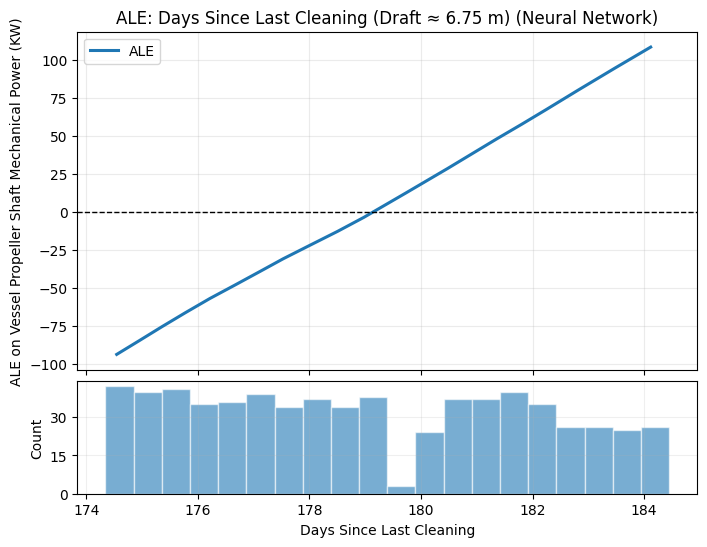

Draft 14.25 m: 1573 observations in [14.15, 14.35]


C:\Users\Augus\AppData\Local\Temp\ipykernel_23480\2677644259.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


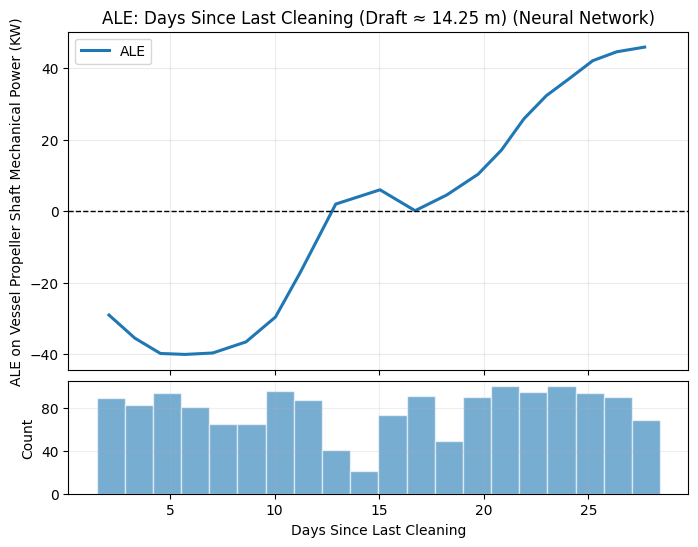

In [166]:
# make the same ALE plot for speeds around 

drafts_to_test = [6.42, 6.75, 14.25]
tol = 0.1  # meters
draft_col = "Avg Draft (Calculated)"

for model_name, model in black_boxes.items():
    for target_draft in drafts_to_test:
        mask = (
            (X_train[draft_col] >= target_draft - tol) &
            (X_train[draft_col] <= target_draft + tol)
        )

        print(
            f"Draft {target_draft:.2f} m: "
            f"{mask.sum()} observations in [{target_draft - tol:.2f}, {target_draft + tol:.2f}]"
        )

        if mask.sum() < 20:   # require a minimum sample size
            continue

        plot_ale_1d(
            model=model,
            preprocess=preprocessors[model_name],
            X=X_train,
            feature_name=fouling_col,
            group_mask=mask,
            title_suffix=f"Draft ≈ {target_draft:.2f} m",
            model_name_for_title=model_name,
            show_data_coverage=True,
        )

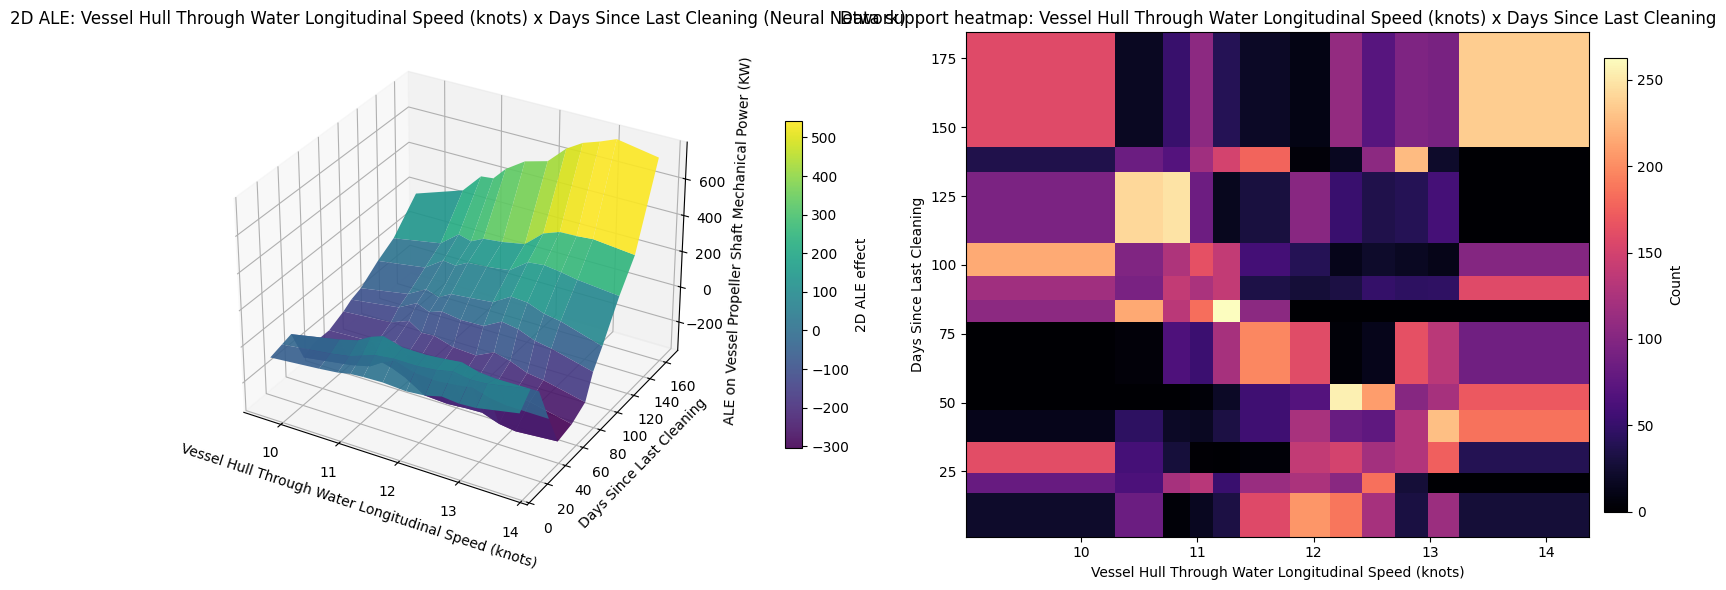

In [167]:
ale_2d = plot_ale_2d(
model=black_boxes["Neural Network"],
preprocess=preprocessors["Neural Network"],
X=X_train,
feature_x="Vessel Hull Through Water Longitudinal Speed (knots)",
feature_y=FOULING_PROXY_VAR_NAME_WITH_UNIT,
model_name_for_title="Neural Network"
)

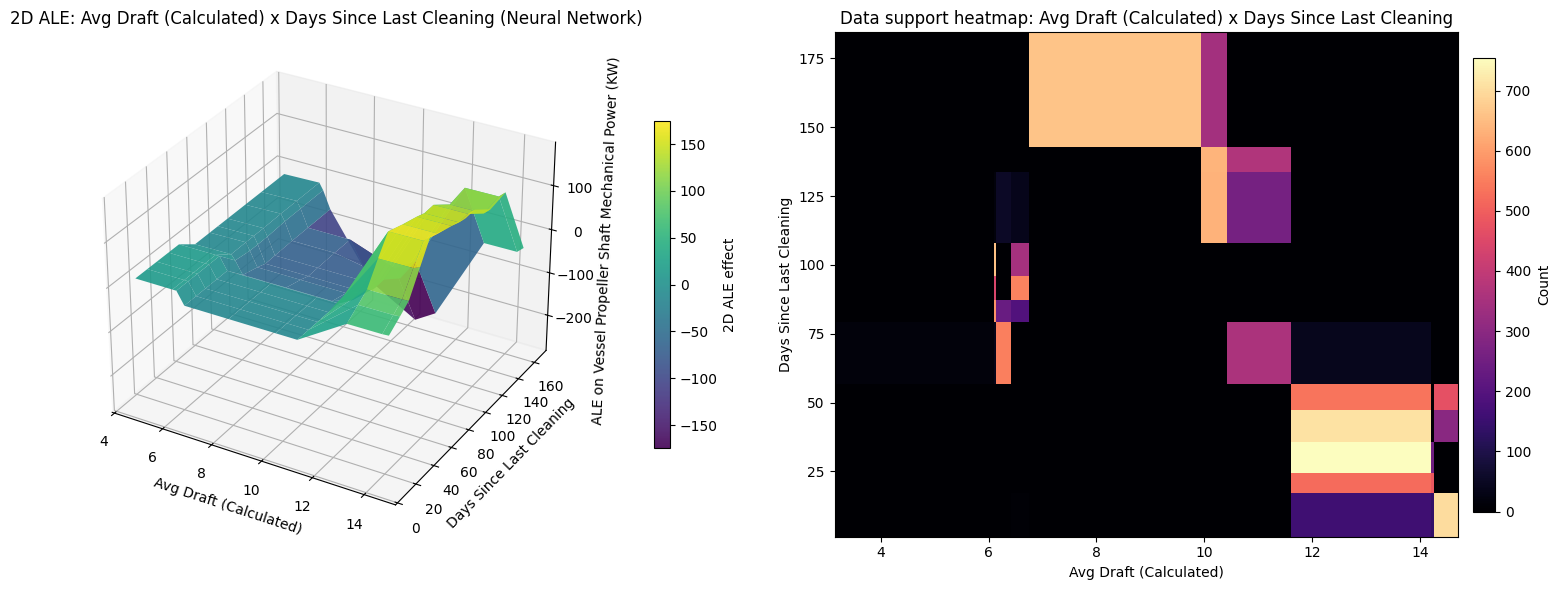

In [168]:
ale_2d = plot_ale_2d(
model=black_boxes["Neural Network"],
preprocess=preprocessors["Neural Network"],
X=X_train,
feature_x="Avg Draft (Calculated)",
feature_y=FOULING_PROXY_VAR_NAME_WITH_UNIT,
model_name_for_title="Neural Network"
)

## 3.3. All models

### 3.3.1. 2D Scenario plots (Secondary to ALE)

In [183]:
# Paths to the pre-built controlled-variable CSVs
fouling_only_path = os.path.join(train_test_dir, f"controlled_var_{WINDOW_LENGTH}_{FOULING_PROXY_VAR_NAME_WITH_UNIT}.csv")
fouling_speed_path = os.path.join(train_test_dir, f"controlled_var_{WINDOW_LENGTH}_{FOULING_PROXY_VAR_NAME_WITH_UNIT}_{SPEED_VARIABLE}.csv")
fouling_draft_path = os.path.join(train_test_dir, f"controlled_var_{WINDOW_LENGTH}_{FOULING_PROXY_VAR_NAME_WITH_UNIT}_Avg Draft (Calculated).csv")
fouling_speed_draft_path = os.path.join(
    train_test_dir,
    f"controlled_var_{WINDOW_LENGTH}_{FOULING_PROXY_VAR_NAME_WITH_UNIT}_{SPEED_VARIABLE}_Avg Draft (Calculated).csv",
)

In [195]:
def load_and_predict_controlled_var(
    controlled_var_path: str,
    model_pipelines: dict,
) -> pd.DataFrame:
    """
    Load a pre-built controlled-variable CSV and add a prediction column
    for every model in the dict.

    Returns the DataFrame with one '<model_name>_pred' column per model.
    """
    df = pd.read_csv(controlled_var_path)
    feature_cols = [c for c in df.columns if c != TARGET_VARIABLE]
    for name, pipeline in model_pipelines.items():
        df[f"{name}_pred"] = pipeline.predict(df[feature_cols])
    return df


def plot_controlled_var_predictions(
    controlled_var_path: str,
    model_pipelines: dict,
    controlled_var_name: str = FOULING_PROXY_VAR_NAME_WITH_UNIT,
    second_controlled_var_name: str | None = None,
    second_controlled_var_values: list | None = None,
    fouling_values: list[float] | None = None,
    scenario_filters: dict[str, dict[str, float]] | None = None,
    scenario_tolerance: float = 1e-6,
    support_reference_X: pd.DataFrame | None = None,
    show_data_support_hist: bool = True,
    support_draft_tolerance: float = 0.15,
    support_trim_tolerance: float = 0.25,
    figsize: tuple = (12, 7),
):
    """
    Load a controlled-variable CSV, predict with every model, and plot.

    Single-variable case (second_controlled_var_name is None):
        One plot with one line per model - predicted power vs fouling.

    Two-variable case (plus optional scenario filters):
        One fitted pseudo speed-power curve per selected fouling level.
        If scenario_filters is provided, separate plots are produced per
        scenario filter (e.g. ballast/design/scantling).
        A table is printed for each plot with the exact prediction values used.

    Parameters
    ----------
    controlled_var_path : str
        Path to the controlled-variable CSV.
    model_pipelines : dict
        {model_name: fitted_pipeline}.
    controlled_var_name : str
        Primary controlled variable (fouling proxy by default).
    second_controlled_var_name : str or None
        Second controlled variable in the CSV (e.g. speed, draft).
    second_controlled_var_values : list or None
        Specific values of the second variable to include on the x-axis.
        If None, all unique values in the CSV are used.
    fouling_values : list of float, optional
        Absolute fouling values used to define the line groups. Each requested
        value is matched to the nearest available fouling value in the data.
        Default: [min, median, max] of available fouling values.
    scenario_filters : dict[str, dict[str, float]], optional
        Mapping scenario name -> {column_name: target_value}.
    scenario_tolerance : float
        Absolute tolerance used when matching float filter values.
    support_reference_X : pd.DataFrame, optional
        Reference data for conditional support histogram (typically X_train).
        If None, attempts to use global X_train if available.
    show_data_support_hist : bool
        If True, show a support histogram in a row below each plot.
    support_draft_tolerance : float
        Tolerance for matching draft values in support data.
    support_trim_tolerance : float
        Tolerance for matching trim values in support data.
    figsize : tuple
        Figure size for each plot.
    """
    speed_col_name = SPEED_VARIABLE
    draft_col_name = "Avg Draft (Calculated)"
    trim_col_name = "Draft Trim (Calculated)"

    if support_reference_X is None and "X_train" in globals():
        global_x_train = globals()["X_train"]
        if isinstance(global_x_train, pd.DataFrame):
            support_reference_X = global_x_train

    def _grouped_means_for_column(source_df: pd.DataFrame, group_col: str, value_col: str) -> np.ndarray:
        grouped = (
            source_df.groupby(group_col, as_index=False)[value_col]
            .mean()
            .sort_values(group_col)
        )
        return grouped[value_col].to_numpy(dtype=float)

    def _get_conditional_support_values(
        scenario_spec: dict[str, float],
        x_col: str,
    ) -> np.ndarray:
        if support_reference_X is None or not isinstance(support_reference_X, pd.DataFrame):
            return np.array([])
        if x_col not in support_reference_X.columns:
            return np.array([])

        support_df = support_reference_X.copy()
        support_mask = np.ones(len(support_df), dtype=bool)

        # Conditional support is based on draft, as requested.
        if draft_col_name in scenario_spec and draft_col_name in support_df.columns:
            draft_target = float(scenario_spec[draft_col_name])
            draft_vals = support_df[draft_col_name].to_numpy(dtype=float)
            support_mask &= np.abs(draft_vals - draft_target) <= support_draft_tolerance
        else:
            for filter_col, filter_value in scenario_spec.items():
                if filter_col not in support_df.columns:
                    continue
                if filter_col in (x_col, controlled_var_name, trim_col_name):
                    continue
                col_vals = support_df[filter_col].to_numpy(dtype=float)
                target_val = float(filter_value)
                support_mask &= np.isclose(col_vals, target_val, atol=scenario_tolerance)

        return support_df.loc[support_mask, x_col].to_numpy(dtype=float)

    def _display_prediction_table(table_df: pd.DataFrame) -> None:
        print("Prediction values used for this plot:")
        table_df = table_df.sort_values(
            ["Fouling Level", "Speed", "Draft", "Trim"],
            na_position="last",
        ).reset_index(drop=True)

        formatters = {
            "Fouling Level": "{:.0f}",
            "Speed": "{:.1f}",
            "Draft": "{:.2f}",
            "Trim": "{:.1f}",
            "Power (kW)": "{:.1f}",
        }
        if "display" in globals():
            display(table_df.style.format(formatters, na_rep="-"))
        else:
            print(
                table_df.to_string(
                    index=False,
                    na_rep="-",
                    formatters={
                        "Fouling Level": lambda v: f"{v:.0f}",
                        "Speed": lambda v: f"{v:.1f}",
                        "Draft": lambda v: f"{v:.2f}",
                        "Trim": lambda v: f"{v:.1f}",
                        "Power (kW)": lambda v: f"{v:.1f}",
                    },
                )
            )

    df = load_and_predict_controlled_var(controlled_var_path, model_pipelines)
    pred_cols = [c for c in df.columns if c.endswith("_pred")]

    if second_controlled_var_name is None:
        # Single controlled variable: one plot, one line per model
        palette = plt.cm.plasma(np.linspace(0.15, 0.9, len(pred_cols)))
        fig, ax = plt.subplots(figsize=figsize)
        x = df[controlled_var_name]
        for color, col in zip(palette, pred_cols):
            label = col.replace("_pred", "")
            ax.plot(x, df[col], linewidth=2, color=color, label=label)
        ax.set_xlabel(controlled_var_name)
        ax.set_ylabel(f"Predicted {TARGET_VARIABLE}")
        ax.set_title(f"Predicted Power vs. {controlled_var_name}")
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
        return

    # Two controlled variables (with optional scenario filtering)
    if second_controlled_var_values is not None:
        df = df[df[second_controlled_var_name].isin(second_controlled_var_values)]

    if df.empty:
        raise ValueError("No rows available after filtering second_controlled_var_values.")

    all_fouling = np.array(sorted(df[controlled_var_name].unique()), dtype=float)
    if fouling_values is None:
        fouling_values = [
            float(all_fouling[0]),
            float(np.median(all_fouling)),
            float(all_fouling[-1]),
        ]

    requested_fouling = np.asarray(fouling_values, dtype=float)
    closest_idx = np.abs(all_fouling[:, None] - requested_fouling[None, :]).argmin(axis=0)
    selected_fouling = [float(v) for v in all_fouling[closest_idx]]
    selected_fouling = list(dict.fromkeys(selected_fouling))

    if not selected_fouling:
        raise ValueError("No fouling levels were selected for plotting.")

    if scenario_filters is None:
        scenario_filters = {"All": {}}

    # Requested color scheme change: use plasma colormap for fouling lines.
    cmap = plt.cm.plasma
    if len(selected_fouling) == 1:
        only_val = selected_fouling[0]
        norm = plt.Normalize(vmin=only_val - 0.5, vmax=only_val + 0.5)
    else:
        norm = plt.Normalize(vmin=min(selected_fouling), vmax=max(selected_fouling))

    for pred_col in pred_cols:
        model_name = pred_col.replace("_pred", "")

        for scenario_name, scenario_spec in scenario_filters.items():
            sub_df = df.copy()
            resolved_spec = {}

            for filter_col, filter_value in scenario_spec.items():
                if filter_col not in sub_df.columns:
                    raise ValueError(
                        f"scenario_filters column '{filter_col}' not found in dataframe columns."
                    )

                available_vals = np.asarray(
                    sorted(sub_df[filter_col].dropna().astype(float).unique()),
                    dtype=float,
                )
                if available_vals.size == 0:
                    sub_df = sub_df.iloc[0:0]
                    break

                nearest_val = float(
                    available_vals[np.abs(available_vals - float(filter_value)).argmin()]
                )
                resolved_spec[filter_col] = nearest_val
                sub_df = sub_df[
                    np.isclose(sub_df[filter_col].astype(float), nearest_val, atol=scenario_tolerance)
                ]

            if sub_df.empty:
                continue

            if show_data_support_hist:
                fig, (ax_main, ax_hist) = plt.subplots(
                    2, 1,
                    figsize=(figsize[0], max(figsize[1], 7)),
                    sharex=True,
                    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
                )
            else:
                fig, ax_main = plt.subplots(figsize=figsize)
                ax_hist = None

            plotted_any = False
            table_rows = []

            for fouling_val in selected_fouling:
                fouling_mask = np.isclose(
                    sub_df[controlled_var_name].astype(float),
                    float(fouling_val),
                    atol=scenario_tolerance,
                )
                fouling_df = sub_df.loc[fouling_mask].copy()
                if fouling_df.empty:
                    continue

                line_df = (
                    fouling_df.groupby(second_controlled_var_name, as_index=False)[pred_col]
                    .mean()
                    .sort_values(second_controlled_var_name)
                )

                x_vals = line_df[second_controlled_var_name].to_numpy(dtype=float)
                y_vals = line_df[pred_col].to_numpy(dtype=float)

                if len(x_vals) < 2:
                    continue

                # Pseudo speed-power fit: y = a * x^3 + b
                design = np.column_stack((x_vals ** 3, np.ones_like(x_vals)))
                a_coef, b_coef = np.linalg.lstsq(design, y_vals, rcond=None)[0]

                fit_x = np.linspace(x_vals.min(), x_vals.max(), 200)
                fit_y = a_coef * (fit_x ** 3) + b_coef

                color = cmap(norm(fouling_val))
                ax_main.scatter(
                    x_vals,
                    y_vals,
                    s=20,
                    alpha=0.45,
                    color=color,
                    edgecolor="white",
                    linewidth=0.3,
                )
                ax_main.plot(
                    fit_x,
                    fit_y,
                    linewidth=2.4,
                    color=color,
                    # Legend values requested without decimals.
                    label=f"{controlled_var_name} = {fouling_val:.0f}",
                )
                plotted_any = True

                # Build table rows for this fouling curve.
                speed_vals = np.full(len(line_df), np.nan)
                draft_vals = np.full(len(line_df), np.nan)
                trim_vals = np.full(len(line_df), np.nan)

                if speed_col_name in fouling_df.columns:
                    if second_controlled_var_name == speed_col_name:
                        speed_vals = x_vals
                    else:
                        speed_vals = _grouped_means_for_column(
                            fouling_df, second_controlled_var_name, speed_col_name
                        )

                if draft_col_name in fouling_df.columns:
                    if second_controlled_var_name == draft_col_name:
                        draft_vals = x_vals
                    else:
                        draft_vals = _grouped_means_for_column(
                            fouling_df, second_controlled_var_name, draft_col_name
                        )

                if trim_col_name in fouling_df.columns:
                    if second_controlled_var_name == trim_col_name:
                        trim_vals = x_vals
                    else:
                        trim_vals = _grouped_means_for_column(
                            fouling_df, second_controlled_var_name, trim_col_name
                        )

                table_rows.append(
                    pd.DataFrame(
                        {
                            "Fouling Level": np.full(len(line_df), float(fouling_val)),
                            "Speed": speed_vals,
                            "Draft": draft_vals,
                            "Trim": trim_vals,
                            "Power (kW)": y_vals,
                        }
                    )
                )

            if not plotted_any:
                plt.close(fig)
                continue

            if resolved_spec:
                resolved_txt = ", ".join([f"{k}={v:g}" for k, v in resolved_spec.items()])
                title_suffix = f" | {scenario_name} ({resolved_txt})"
            else:
                title_suffix = "" if scenario_name == "All" else f" | {scenario_name}"

            ax_main.set_ylabel(f"Predicted {TARGET_VARIABLE}")
            ax_main.set_title(
                f"{model_name}: Predicted Power by {second_controlled_var_name}{title_suffix}"
            )
            ax_main.legend(fontsize=8, loc="upper left")
            ax_main.grid(alpha=0.3)

            if ax_hist is not None:
                support_x = _get_conditional_support_values(resolved_spec, second_controlled_var_name)
                if support_x.size > 0:
                    n_bins = min(30, max(10, int(np.sqrt(len(support_x)))))
                    ax_hist.hist(
                        support_x,
                        bins=n_bins,
                        color=plt.cm.plasma(0.35),
                        alpha=0.65,
                        edgecolor="white",
                        linewidth=0.3,
                    )
                else:
                    ax_hist.text(
                        0.5,
                        0.5,
                        "No draft-conditioned support in training data",
                        transform=ax_hist.transAxes,
                        ha="center",
                        va="center",
                        fontsize=9,
                        color="dimgray",
                    )
                ax_hist.set_ylabel("Count")
                ax_hist.set_xlabel(second_controlled_var_name)
                ax_hist.grid(alpha=0.25)
                ax_main.tick_params(labelbottom=False)
            else:
                ax_main.set_xlabel(second_controlled_var_name)

            if ax_hist is not None:
                fig.subplots_adjust(hspace=0.08)
            else:
                fig.tight_layout()
            plt.show()

            if table_rows:
                plot_table_df = pd.concat(table_rows, ignore_index=True)
                _display_prediction_table(plot_table_df)

In [192]:
# give the top 10 most common draft values in the training data
draft_counts = X_train["Avg Draft (Calculated)"].value_counts().sort_values(ascending=False)
print("Top 10 most common draft values in training data:")
print(draft_counts.head(10))

Top 10 most common draft values in training data:
Avg Draft (Calculated)
11.615    2181
6.100     1734
9.945     1606
6.420     1141
14.200     851
6.145      789
14.700     765
6.750      655
14.250     638
10.430     627
Name: count, dtype: int64


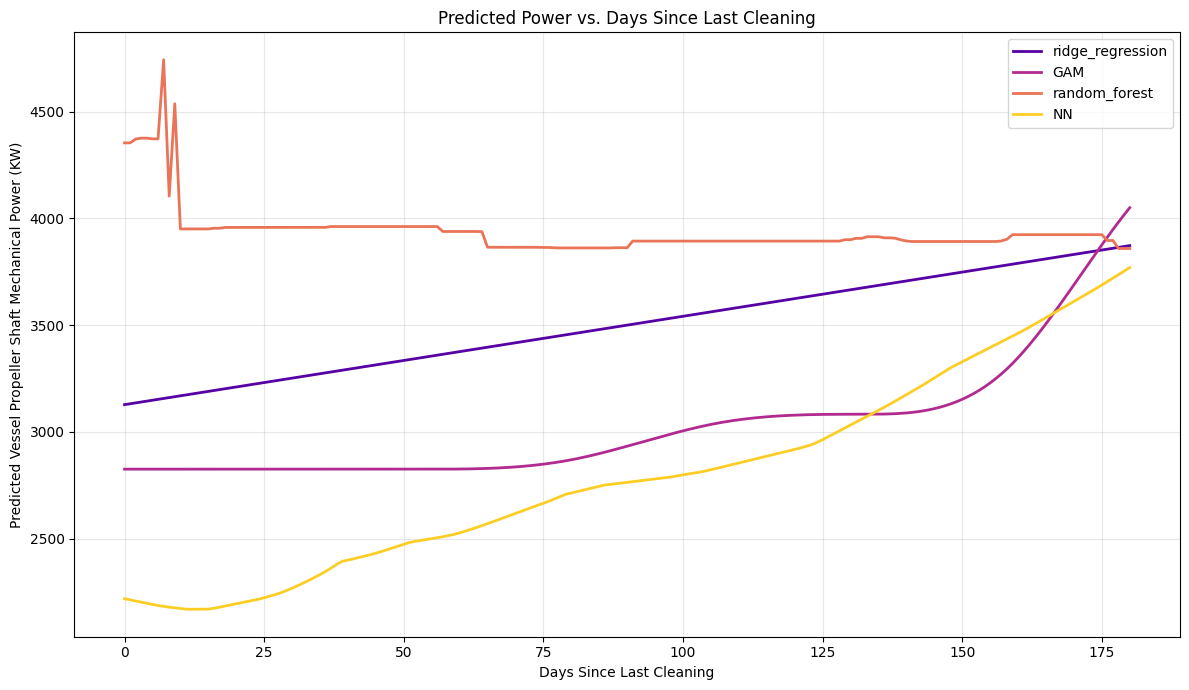

In [189]:
# Fouling only (all other features at median)
plot_controlled_var_predictions(fouling_only_path, model_pipelines_incl_foul)

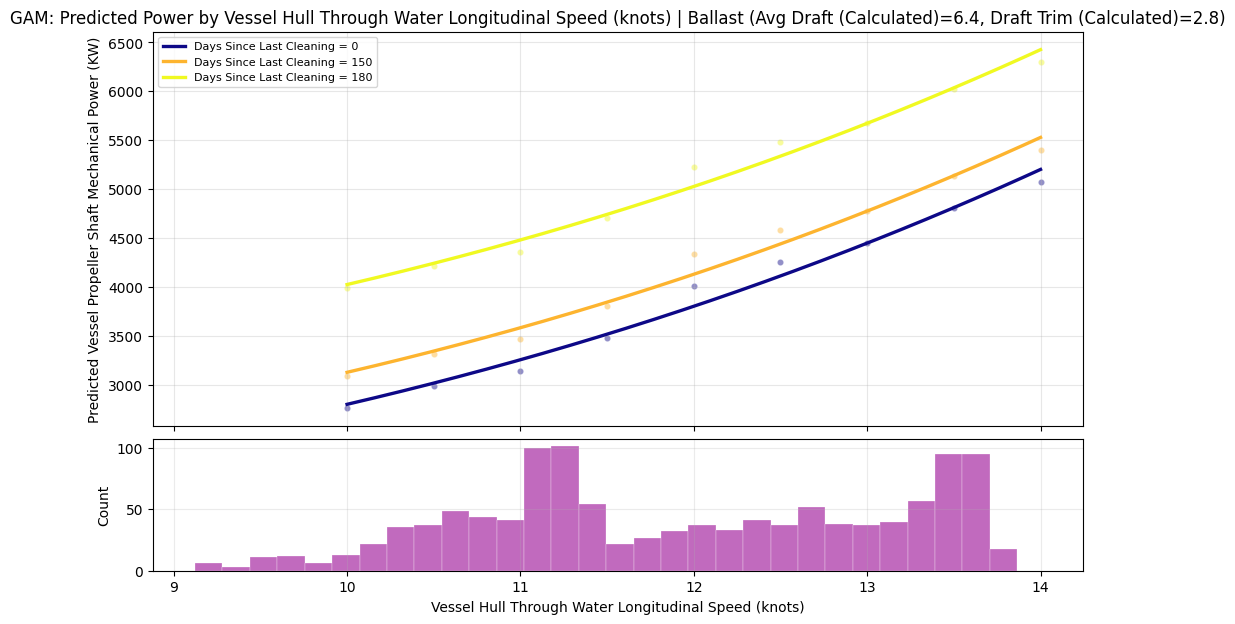

Prediction values used for this plot:


,Fouling Level,Speed,Draft,Trim,Power (kW)
0,0,10.0,6.40,2.8,2760.4
1,0,10.5,6.40,2.8,2991.3
2,0,11.0,6.40,2.8,3137.7
3,0,11.5,6.40,2.8,3480.1
4,0,12.0,6.40,2.8,4005.8
5,0,12.5,6.40,2.8,4256.9
6,0,13.0,6.40,2.8,4452.9
7,0,13.5,6.40,2.8,4803.2
8,0,14.0,6.40,2.8,5076.3
9,150,10.0,6.40,2.8,3087.7


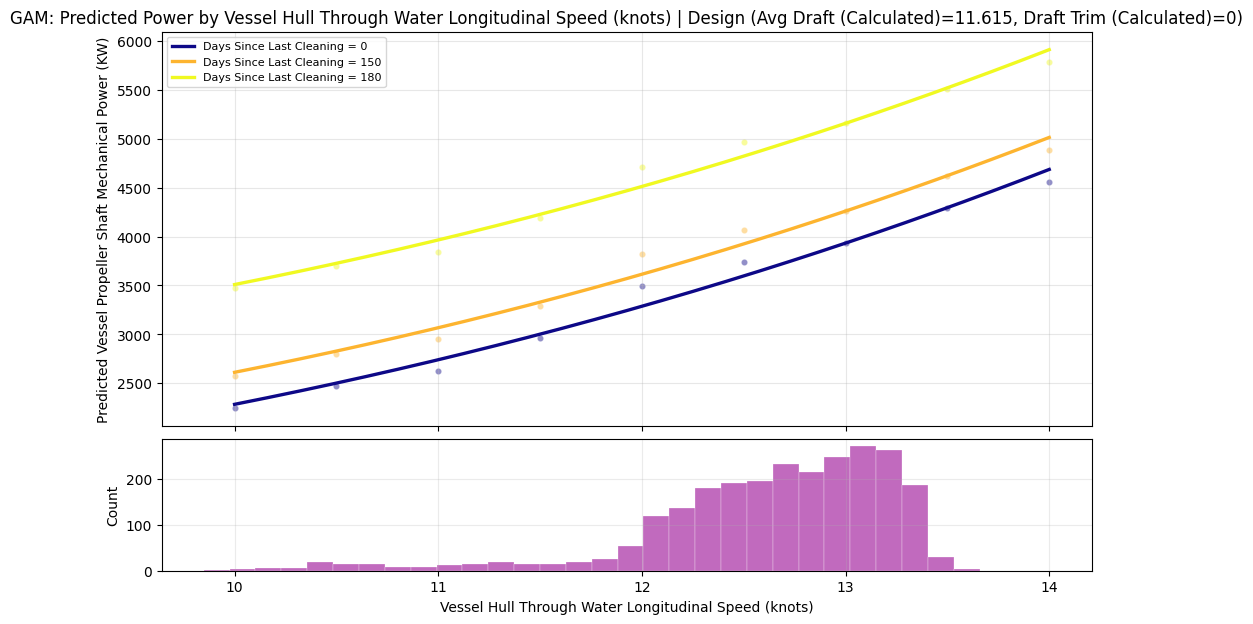

Prediction values used for this plot:


,Fouling Level,Speed,Draft,Trim,Power (kW)
0,0,10.0,11.62,0.0,2245.6
1,0,10.5,11.62,0.0,2476.5
2,0,11.0,11.62,0.0,2622.9
3,0,11.5,11.62,0.0,2965.3
4,0,12.0,11.62,0.0,3491.1
5,0,12.5,11.62,0.0,3742.2
6,0,13.0,11.62,0.0,3938.2
7,0,13.5,11.62,0.0,4288.4
8,0,14.0,11.62,0.0,4561.5
9,150,10.0,11.62,0.0,2572.9


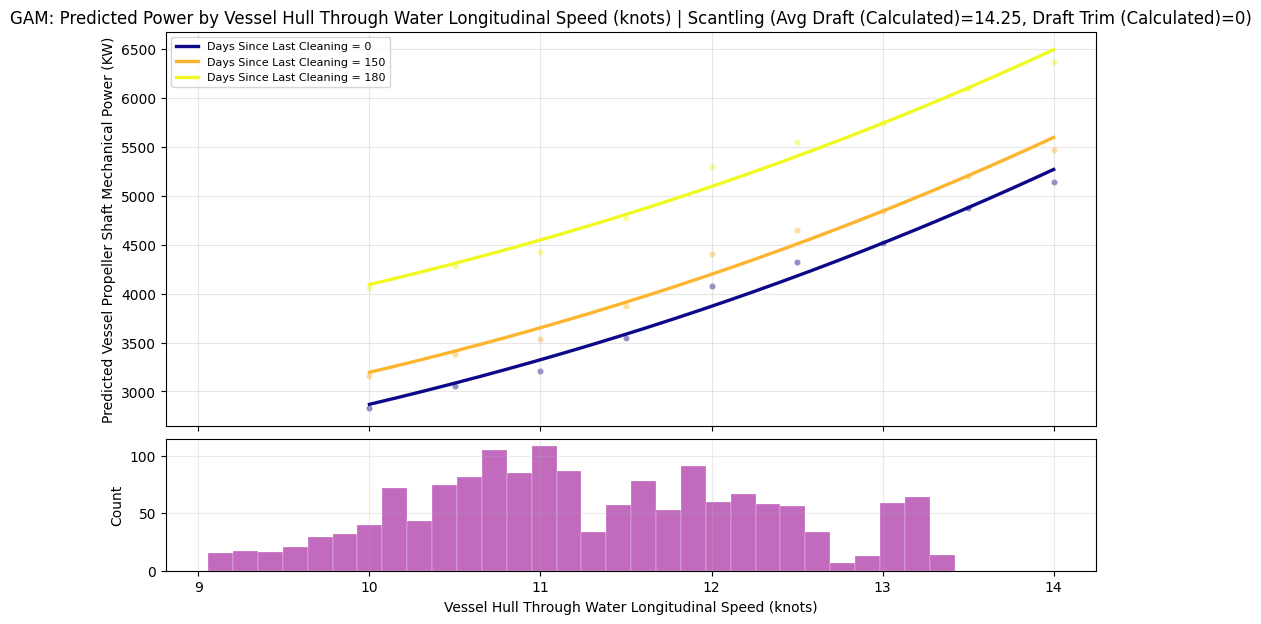

Prediction values used for this plot:


,Fouling Level,Speed,Draft,Trim,Power (kW)
0,0,10.0,14.25,0.0,2829.0
1,0,10.5,14.25,0.0,3059.8
2,0,11.0,14.25,0.0,3206.2
3,0,11.5,14.25,0.0,3548.6
4,0,12.0,14.25,0.0,4074.4
5,0,12.5,14.25,0.0,4325.5
6,0,13.0,14.25,0.0,4521.5
7,0,13.5,14.25,0.0,4871.8
8,0,14.0,14.25,0.0,5144.9
9,150,10.0,14.25,0.0,3156.2


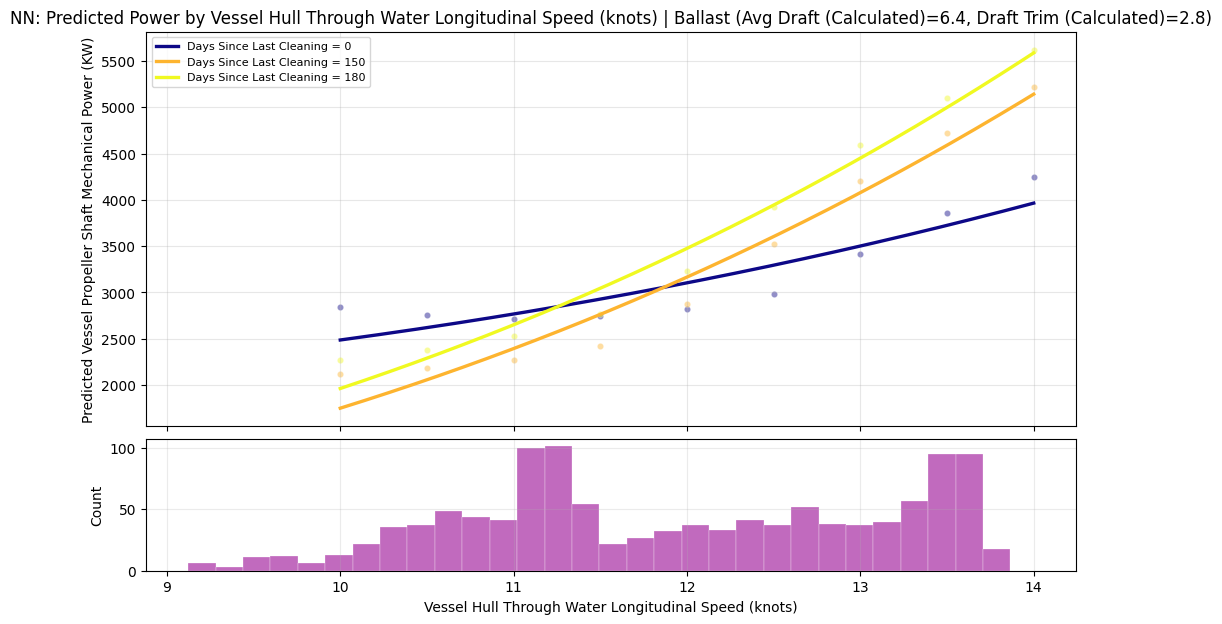

Prediction values used for this plot:


,Fouling Level,Speed,Draft,Trim,Power (kW)
0,0,10.0,6.40,2.8,2846.5
1,0,10.5,6.40,2.8,2752.9
2,0,11.0,6.40,2.8,2718.0
3,0,11.5,6.40,2.8,2743.2
4,0,12.0,6.40,2.8,2819.4
5,0,12.5,6.40,2.8,2986.0
6,0,13.0,6.40,2.8,3412.5
7,0,13.5,6.40,2.8,3861.7
8,0,14.0,6.40,2.8,4251.8
9,150,10.0,6.40,2.8,2117.2


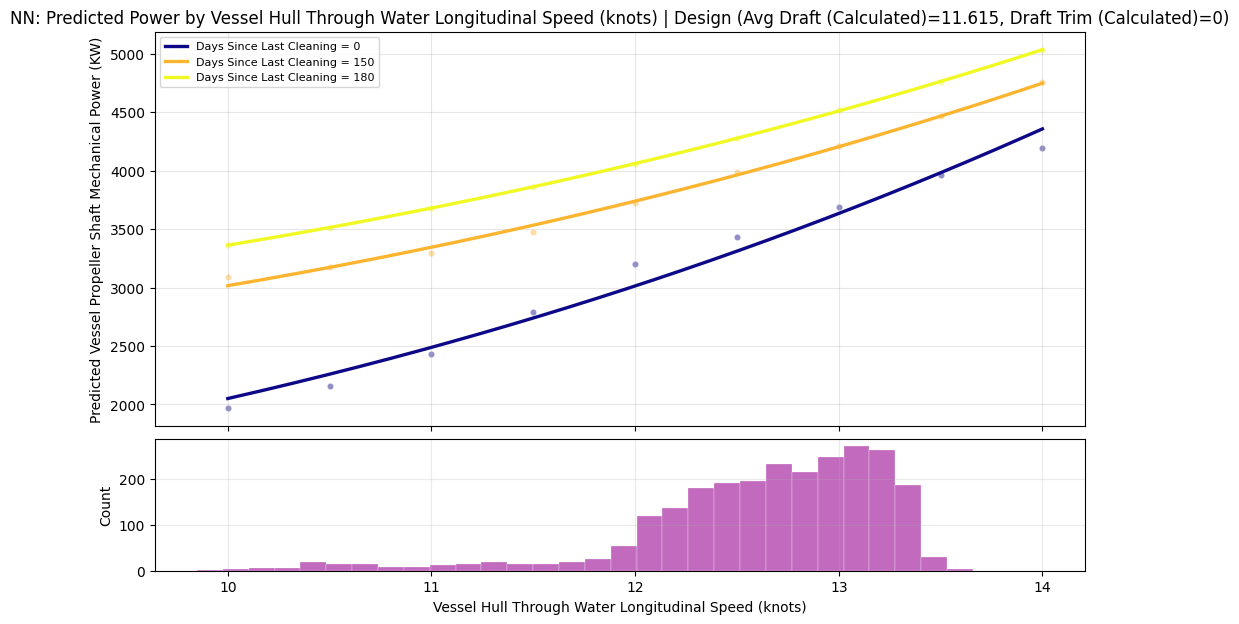

Prediction values used for this plot:


,Fouling Level,Speed,Draft,Trim,Power (kW)
0,0,10.0,11.62,0.0,1968.0
1,0,10.5,11.62,0.0,2158.7
2,0,11.0,11.62,0.0,2434.3
3,0,11.5,11.62,0.0,2793.9
4,0,12.0,11.62,0.0,3203.0
5,0,12.5,11.62,0.0,3432.2
6,0,13.0,11.62,0.0,3693.9
7,0,13.5,11.62,0.0,3960.3
8,0,14.0,11.62,0.0,4194.5
9,150,10.0,11.62,0.0,3086.6


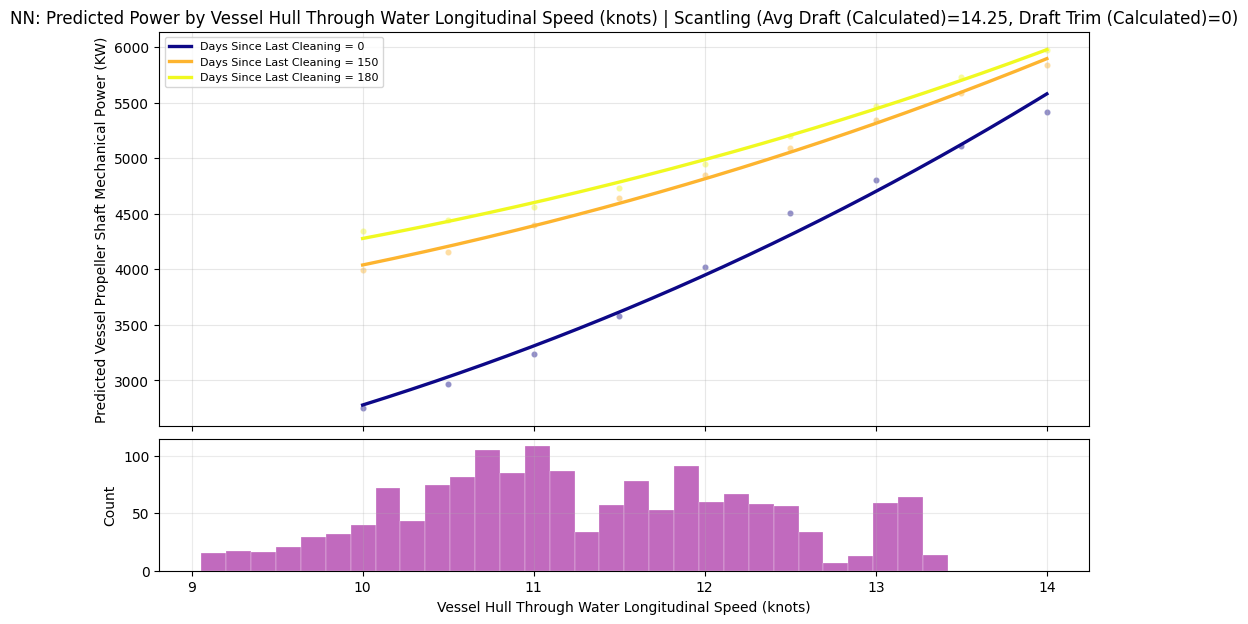

Prediction values used for this plot:


,Fouling Level,Speed,Draft,Trim,Power (kW)
0,0,10.0,14.25,0.0,2750.2
1,0,10.5,14.25,0.0,2971.9
2,0,11.0,14.25,0.0,3238.8
3,0,11.5,14.25,0.0,3582.4
4,0,12.0,14.25,0.0,4023.7
5,0,12.5,14.25,0.0,4509.5
6,0,13.0,14.25,0.0,4803.4
7,0,13.5,14.25,0.0,5106.6
8,0,14.0,14.25,0.0,5412.1
9,150,10.0,14.25,0.0,3997.6


In [ ]:
# make a pipelines object without random forest and linear regression
model_pipelines_incl_foul_no_rf_lr = {
    k: v for k, v in model_pipelines_incl_foul.items()
    if k not in ["random_forest", "ridge_regression"]
}

# Loading-condition scenarios from ship particulars
loading_condition_scenarios = {
    "Ballast": {"Avg Draft (Calculated)": 6.42, "Draft Trim (Calculated)": 2.8},
    "Design": {"Avg Draft (Calculated)": 11.615, "Draft Trim (Calculated)": 0.0},
    "Scantling": {"Avg Draft (Calculated)": 14.25, "Draft Trim (Calculated)": 0.0},
}

# Fouling x Speed across loading conditions (three scenario plots per model)
plot_controlled_var_predictions(
    fouling_speed_draft_path,
    model_pipelines_incl_foul_no_rf_lr,
    second_controlled_var_name=SPEED_VARIABLE,
    second_controlled_var_values=[9, 9.5, 10, 10.5, 11, 11.5, 12, 12.5, 13, 13.5, 14],
    fouling_values=[0, 150, 180],
    scenario_filters=loading_condition_scenarios,
)

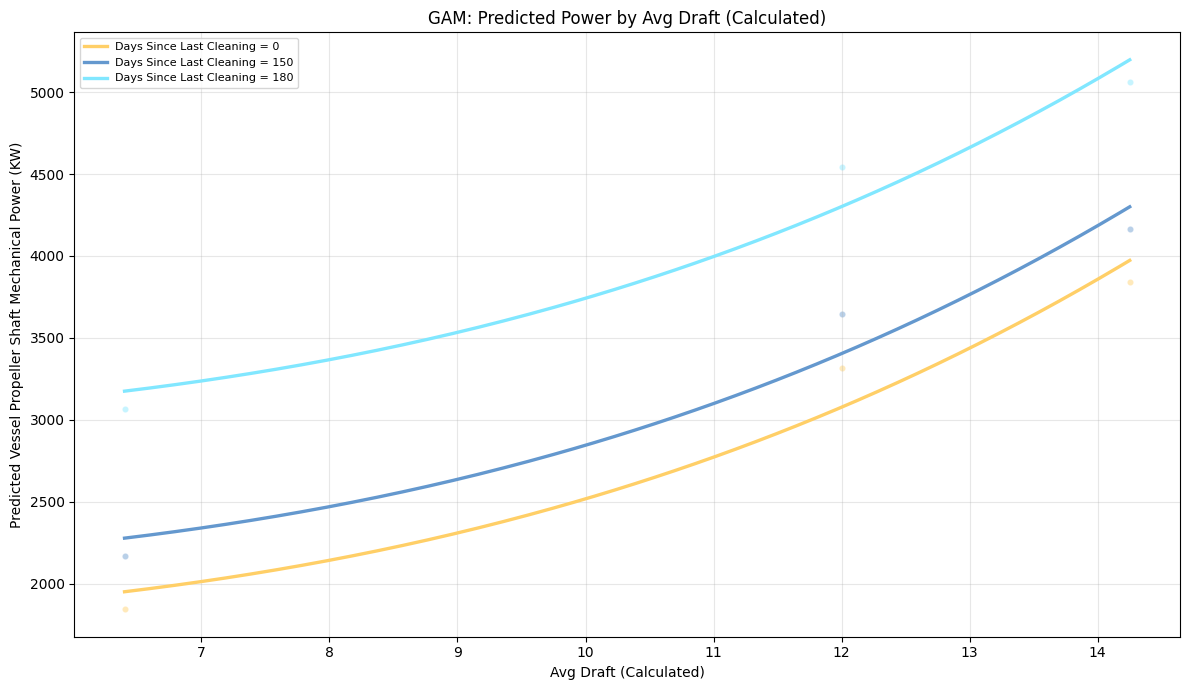

Prediction values used for this plot:


,Fouling Level,Speed,Draft,Trim,Power (kW)
0,0,11.8,6.40,1.0,1843.2
1,0,11.8,12.00,1.0,3318.0
2,0,11.8,14.25,1.0,3838.5
3,150,11.8,6.40,1.0,2170.5
4,150,11.8,12.00,1.0,3645.3
5,150,11.8,14.25,1.0,4165.8
6,180,11.8,6.40,1.0,3067.8
7,180,11.8,12.00,1.0,4542.7
8,180,11.8,14.25,1.0,5063.1


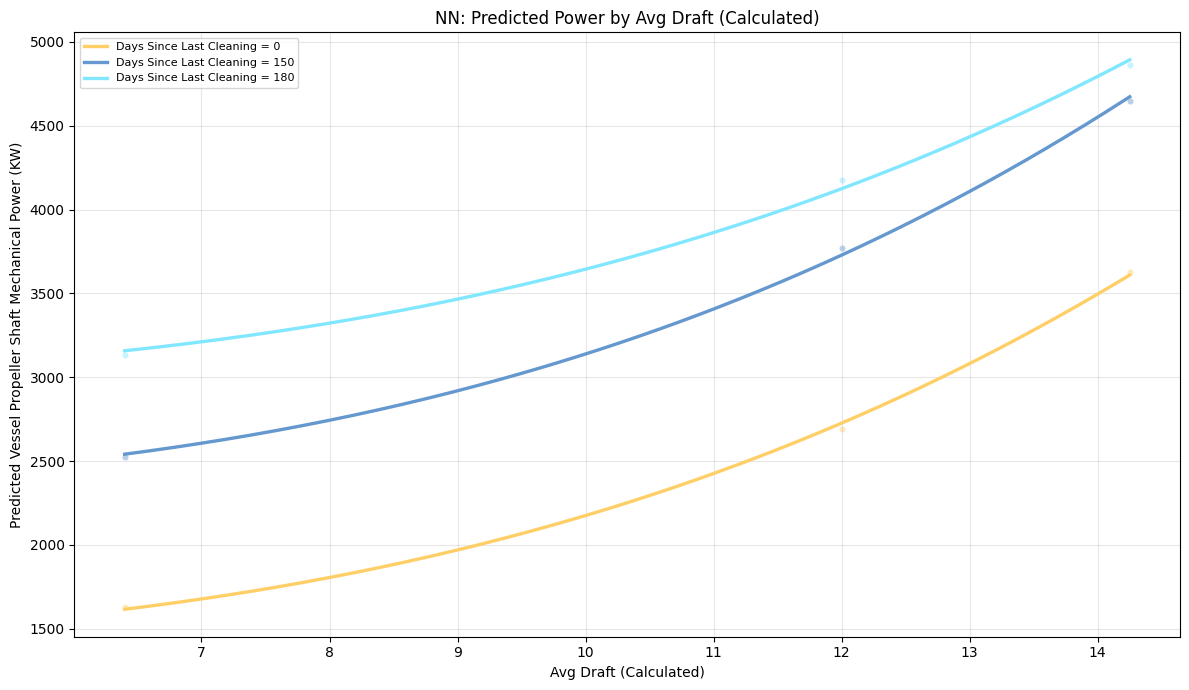

Prediction values used for this plot:


,Fouling Level,Speed,Draft,Trim,Power (kW)
0,0,11.8,6.40,1.0,1632.4
1,0,11.8,12.00,1.0,2690.1
2,0,11.8,14.25,1.0,3629.8
3,150,11.8,6.40,1.0,2522.4
4,150,11.8,12.00,1.0,3770.7
5,150,11.8,14.25,1.0,4649.3
6,180,11.8,6.40,1.0,3134.4
7,180,11.8,12.00,1.0,4177.6
8,180,11.8,14.25,1.0,4863.7


In [191]:
# Fouling x Draft - one plot per model, lines at selected absolute fouling levels
drafts_to_test = [6.4, 12.0, 14.25]

plot_controlled_var_predictions(
    fouling_draft_path,
    model_pipelines_incl_foul_no_rf_lr,
    second_controlled_var_name="Avg Draft (Calculated)",
    second_controlled_var_values=drafts_to_test,
    fouling_values=[0, 150, 180],
)

### 3.3.2. 3D Synhtetic Scenario plots (secondaty to ALE)

In [175]:

def plot_3d_scenario_power_surface(
    model_pipeline,
    scenario_csv_path: str | None = None,
    scenario_dir: str | None = None,
    window_length: str | None = None,
    feature_x: str = SPEED_VARIABLE,
    feature_y: str = FOULING_PROXY_VAR_NAME_WITH_UNIT,
    target_variable: str = TARGET_VARIABLE,
    model_name_for_title: str | None = None,
    predicted_label: str = "Predicted Shaft Power (kW)",
    figsize: tuple = (14, 6),
    cmap: str = "viridis",
    coverage_check: bool = True,
    coverage_reference_X: pd.DataFrame | None = None,
    coverage_k: int = 20,
    coverage_stat: str = "kth",          # {"kth", "mean"}
    coverage_metric: str = "euclidean",
    coverage_cmap: str = "magma_r",
    coverage_show_percentile: bool = True,
    coverage_threshold_quantile: float = 0.95,
    coverage_mask_weak: bool = False,
):
    """
    Plot a 3D surface of predicted power as a function of two scenario features,
    optionally with a grid-wide k-NN coverage/support heatmap.

    Defaults are chosen for speed x fouling. To inspect fouling x draft instead,
    pass feature_x=FOULING_PROXY_VAR_NAME_WITH_UNIT and feature_y="Avg Draft (Calculated)".

    Scenario data can be provided directly via `scenario_csv_path`, or inferred from
    `scenario_dir` + `window_length` using either filename order:
      controlled_var_{window_length}_{feature_x}_{feature_y}.csv
      controlled_var_{window_length}_{feature_y}_{feature_x}.csv

    Parameters
    ----------
    model_pipeline : fitted sklearn-like pipeline
        Must implement .predict() on a DataFrame of feature columns.
    scenario_csv_path : str or None
        Full path to a pre-built scenario CSV.
    scenario_dir : str or None
        Directory containing scenario CSV files.
    window_length : str or None
        Window length token used in scenario filename construction.
    feature_x : str
        Column name for x-axis.
    feature_y : str
        Column name for y-axis.
    target_variable : str
        Target column name to exclude from model features if present in CSV.
    model_name_for_title : str or None
        Optional model name shown in title.
    predicted_label : str
        Label for z-axis and colorbar.
    figsize : tuple
        Figure size.
    cmap : str
        Matplotlib colormap for surface.

    coverage_check : bool, default=True
        If True, compute a grid-wide support map based on k-nearest neighbors in
        transformed feature space.
    coverage_reference_X : pd.DataFrame or None
        Training feature matrix used as the support reference set. Must contain
        all model feature columns.
    coverage_k : int, default=20
        Number of nearest neighbors used for support scoring.
    coverage_stat : {"kth", "mean"}, default="kth"
        "kth"  -> use distance to the k-th nearest neighbor
        "mean" -> use mean distance to the k nearest neighbors
    coverage_metric : str, default="euclidean"
        Metric passed to sklearn.neighbors.NearestNeighbors.
    coverage_cmap : str, default="magma_r"
        Colormap for side support heatmap.
    coverage_show_percentile : bool, default=True
        If True, visualize support as percentile rank vs the training reference
        distribution. Lower percentile = better support.
    coverage_threshold_quantile : float, default=0.95
        Quantile of the training reference support distribution used to define
        weak support.
    coverage_mask_weak : bool, default=False
        If True and coverage_check=True, weak-support cells are masked on the
        3D surface.

    Returns
    -------
    dict
        {
            "scenario_with_predictions": pd.DataFrame,
            "surface_grid": pd.DataFrame,
            "scenario_csv_path": str,
            "coverage_long": pd.DataFrame | None,
            "coverage_grid": pd.DataFrame | None,
            "coverage_reference_scores": np.ndarray | None,
            "coverage_threshold": float | None,
        }
    """

    def _find_scenario_path():
        if scenario_csv_path is not None:
            return scenario_csv_path

        if scenario_dir is None or window_length is None:
            raise ValueError(
                "Provide either scenario_csv_path, or both scenario_dir and window_length."
            )

        candidate_paths = [
            os.path.join(
                scenario_dir,
                f"controlled_var_{window_length}_{feature_x}_{feature_y}.csv",
            ),
            os.path.join(
                scenario_dir,
                f"controlled_var_{window_length}_{feature_y}_{feature_x}.csv",
            ),
        ]

        existing_candidates = [p for p in candidate_paths if os.path.exists(p)]
        if len(existing_candidates) == 0:
            raise FileNotFoundError(
                "Scenario file not found. Tried: " + " | ".join(candidate_paths)
            )
        return existing_candidates[0]

    def _transform_for_support(fitted_pipeline, X):
        X = X.copy()
        try:
            if hasattr(fitted_pipeline, "__getitem__"):
                preproc = fitted_pipeline[:-1]
                Xt = preproc.transform(X)
            elif hasattr(fitted_pipeline, "transform"):
                Xt = fitted_pipeline.transform(X)
            else:
                Xt = X.to_numpy()
        except Exception:
            Xt = X.to_numpy()

        if hasattr(Xt, "toarray"):
            Xt = Xt.toarray()

        return np.asarray(Xt, dtype=float)

    def _score_distances(dist_matrix, stat):
        if stat == "kth":
            return dist_matrix[:, -1]
        if stat == "mean":
            return dist_matrix.mean(axis=1)
        raise ValueError("coverage_stat must be one of {'kth', 'mean'}.")

    def _percentile_rank(values, reference):
        ref_sorted = np.sort(np.asarray(reference, dtype=float))
        return np.searchsorted(ref_sorted, values, side="right") / len(ref_sorted)

    scenario_path = _find_scenario_path()

    if not os.path.exists(scenario_path):
        raise FileNotFoundError(f"Scenario file not found: {scenario_path}")

    scenario_df = pd.read_csv(scenario_path)

    for col in [feature_x, feature_y]:
        if col not in scenario_df.columns:
            raise KeyError(f"Required column '{col}' not found in scenario data.")

    feature_cols = [c for c in scenario_df.columns if c != target_variable]

    y_pred = model_pipeline.predict(scenario_df[feature_cols])

    plot_df = scenario_df[[feature_x, feature_y]].copy()
    plot_df["predicted_power"] = y_pred

    grouped_df = (
        plot_df.groupby([feature_y, feature_x], as_index=False)["predicted_power"]
        .mean()
        .sort_values([feature_y, feature_x])
    )

    surface_df = grouped_df.pivot(
        index=feature_y,
        columns=feature_x,
        values="predicted_power",
    ).sort_index().sort_index(axis=1)

    x_vals = surface_df.columns.to_numpy(dtype=float)
    y_vals = surface_df.index.to_numpy(dtype=float)
    Xg, Yg = np.meshgrid(x_vals, y_vals)
    Z = surface_df.to_numpy(dtype=float)

    coverage_long = None
    coverage_df = None
    coverage_reference_scores = None
    coverage_threshold = None
    weak_mask = None

    if coverage_check:
        if coverage_reference_X is None:
            warnings.warn(
                "coverage_check=True but coverage_reference_X is None. "
                "Skipping coverage computation."
            )
            coverage_check = False
        else:
            missing_cols = [c for c in feature_cols if c not in coverage_reference_X.columns]
            if missing_cols:
                raise KeyError(
                    "coverage_reference_X is missing required feature columns: "
                    + ", ".join(missing_cols)
                )

            X_ref_raw = coverage_reference_X[feature_cols].copy()
            X_query_raw = scenario_df[feature_cols].copy()

            X_ref = _transform_for_support(model_pipeline, X_ref_raw)
            X_query = _transform_for_support(model_pipeline, X_query_raw)

            nn = NearestNeighbors(
                n_neighbors=coverage_k,
                metric=coverage_metric,
            )
            nn.fit(X_ref)

            query_distances, _ = nn.kneighbors(X_query, n_neighbors=coverage_k)
            query_scores = _score_distances(query_distances, coverage_stat)

            ref_distances, _ = nn.kneighbors(X_ref, n_neighbors=min(coverage_k + 1, len(X_ref)))
            if ref_distances.shape[1] > coverage_k:
                ref_distances = ref_distances[:, 1:]
            else:
                ref_distances = ref_distances[:, 1:]
                if ref_distances.shape[1] == 0:
                    raise ValueError("Not enough rows in coverage_reference_X for coverage_k.")

            coverage_reference_scores = _score_distances(ref_distances, coverage_stat)
            coverage_threshold = np.quantile(
                coverage_reference_scores,
                coverage_threshold_quantile
            )

            coverage_long = scenario_df[[feature_x, feature_y]].copy()
            coverage_long["coverage_score"] = query_scores
            coverage_long["coverage_percentile"] = _percentile_rank(
                query_scores,
                coverage_reference_scores
            )
            coverage_long["weak_support"] = (
                coverage_long["coverage_score"] > coverage_threshold
            )

            coverage_value_col = (
                "coverage_percentile" if coverage_show_percentile else "coverage_score"
            )

            coverage_df = (
                coverage_long.groupby([feature_y, feature_x], as_index=False)[coverage_value_col]
                .mean()
                .sort_values([feature_y, feature_x])
                .pivot(index=feature_y, columns=feature_x, values=coverage_value_col)
                .sort_index()
                .sort_index(axis=1)
            )

            weak_mask = (
                coverage_long.groupby([feature_y, feature_x], as_index=False)["weak_support"]
                .mean()
                .sort_values([feature_y, feature_x])
                .pivot(index=feature_y, columns=feature_x, values="weak_support")
                .sort_index()
                .sort_index(axis=1)
                .to_numpy(dtype=float) > 0
            )

            if coverage_mask_weak and weak_mask is not None:
                Z = Z.copy()
                Z[weak_mask] = np.nan

    if coverage_check and coverage_df is not None:
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(1, 2, width_ratios=[1.7, 1.0])

        ax = fig.add_subplot(gs[0, 0], projection="3d")
        ax_cov = fig.add_subplot(gs[0, 1])
    else:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111, projection="3d")
        ax_cov = None

    if np.isnan(Z).any():
        valid = ~np.isnan(Z)
        surf = ax.plot_trisurf(
            Xg[valid],
            Yg[valid],
            Z[valid],
            cmap=cmap,
            linewidth=0.2,
            antialiased=True,
            alpha=0.95,
        )
    else:
        surf = ax.plot_surface(
            Xg,
            Yg,
            Z,
            cmap=cmap,
            linewidth=0,
            antialiased=True,
            alpha=0.95,
        )

    cbar = fig.colorbar(surf, ax=ax, shrink=0.65, pad=0.08)
    cbar.set_label(predicted_label)

    title = f"Predicted power surface: {feature_x} x {feature_y}"
    if model_name_for_title:
        title += f" ({model_name_for_title})"
    if window_length is not None:
        title += f" | window={window_length}"

    ax.set_title(title)
    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)
    ax.set_zlabel(predicted_label)

    if coverage_check and coverage_df is not None and ax_cov is not None:
        cov_vals = coverage_df.to_numpy(dtype=float)

        im = ax_cov.imshow(
            cov_vals,
            origin="lower",
            aspect="auto",
            cmap=coverage_cmap,
            extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
        )

        if coverage_show_percentile:
            cbar_cov = fig.colorbar(im, ax=ax_cov, shrink=0.9, pad=0.03)
            cbar_cov.set_label("Coverage percentile vs training set\n(lower = better support)")
        else:
            cbar_cov = fig.colorbar(im, ax=ax_cov, shrink=0.9, pad=0.03)
            cbar_cov.set_label(f"{coverage_stat}-NN distance (k={coverage_k})")

        ax_cov.set_title("Coverage check")
        ax_cov.set_xlabel(feature_x)
        ax_cov.set_ylabel(feature_y)

        if weak_mask is not None:
            ax_cov.contour(
                x_vals,
                y_vals,
                weak_mask.astype(float),
                levels=[0.5],
                colors="cyan",
                linewidths=1.5,
            )

        if coverage_show_percentile:
            ax_cov.text(
                0.02, 0.02,
                f"Weak-support threshold: > {int(coverage_threshold_quantile * 100)}th pct\n"
                f"of training {coverage_stat}-NN distance",
                transform=ax_cov.transAxes,
                va="bottom",
                ha="left",
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="0.8")
            )

    plt.tight_layout()
    plt.show()

    return {
        "scenario_with_predictions": plot_df,
        "surface_grid": surface_df,
        "scenario_csv_path": scenario_path,
        "coverage_long": coverage_long,
        "coverage_grid": coverage_df,
        "coverage_reference_scores": coverage_reference_scores,
        "coverage_threshold": coverage_threshold,
    }

def plot_scenario_power_slice(
    model_pipeline,
    speed_value: float,
    scenario_csv_path: str | None = None,
    scenario_dir: str | None = None,
    window_length: str | None = None,
    speed_feature: str = SPEED_VARIABLE,
    fouling_feature: str = FOULING_PROXY_VAR_NAME_WITH_UNIT,
    target_variable: str = TARGET_VARIABLE,
    model_name_for_title: str | None = None,
    predicted_label: str = "Predicted Shaft Power (kW)",
    figsize: tuple = (10, 5),
    line_color: str = "tab:blue",
    linewidth: float = 2.0,
    match_mode: str = "nearest",      # {"nearest", "exact"}
    atol: float = 1e-8,
    coverage_check: bool = True,
    coverage_reference_X: pd.DataFrame | None = None,
    coverage_k: int = 20,
    coverage_stat: str = "kth",       # {"kth", "mean"}
    coverage_metric: str = "euclidean",
):
    """
    Plot a 2D scenario slice: predicted power as a function of fouling proxy
    for a chosen speed.

    The optional secondary axis shows coverage percentile relative to the
    training-set distribution of the same k-NN support metric.
    Higher percentile = worse support.

    Returns
    -------
    dict
        {
            "slice_df": pd.DataFrame,
            "selected_speed_value": float,
            "scenario_csv_path": str,
            "coverage_scores": np.ndarray | None,
            "coverage_percentiles": np.ndarray | None,
            "coverage_reference_scores": np.ndarray | None,
        }
    """

    def _find_scenario_path():
        if scenario_csv_path is not None:
            return scenario_csv_path

        if scenario_dir is None or window_length is None:
            raise ValueError(
                "Provide either scenario_csv_path, or both scenario_dir and window_length."
            )

        candidate_paths = [
            os.path.join(
                scenario_dir,
                f"controlled_var_{window_length}_{speed_feature}_{fouling_feature}.csv",
            ),
            os.path.join(
                scenario_dir,
                f"controlled_var_{window_length}_{fouling_feature}_{speed_feature}.csv",
            ),
        ]

        existing_candidates = [p for p in candidate_paths if os.path.exists(p)]
        if len(existing_candidates) == 0:
            raise FileNotFoundError(
                "Scenario file not found. Tried: " + " | ".join(candidate_paths)
            )
        return existing_candidates[0]

    def _transform_for_support(fitted_pipeline, X):
        X = X.copy()
        try:
            if hasattr(fitted_pipeline, "__getitem__"):
                preproc = fitted_pipeline[:-1]
                Xt = preproc.transform(X)
            elif hasattr(fitted_pipeline, "transform"):
                Xt = fitted_pipeline.transform(X)
            else:
                Xt = X.to_numpy()
        except Exception:
            Xt = X.to_numpy()

        if hasattr(Xt, "toarray"):
            Xt = Xt.toarray()

        return np.asarray(Xt, dtype=float)

    def _score_distances(dist_matrix, stat):
        if stat == "kth":
            return dist_matrix[:, -1]
        if stat == "mean":
            return dist_matrix.mean(axis=1)
        raise ValueError("coverage_stat must be one of {'kth', 'mean'}.")

    def _percentile_rank(values, reference):
        ref_sorted = np.sort(np.asarray(reference, dtype=float))
        return np.searchsorted(ref_sorted, values, side="right") / len(ref_sorted)

    scenario_path = _find_scenario_path()

    if not os.path.exists(scenario_path):
        raise FileNotFoundError(f"Scenario file not found: {scenario_path}")

    scenario_df = pd.read_csv(scenario_path)

    for col in [speed_feature, fouling_feature]:
        if col not in scenario_df.columns:
            raise KeyError(f"Required column '{col}' not found in scenario data.")

    available_speeds = np.sort(scenario_df[speed_feature].dropna().unique().astype(float))

    if len(available_speeds) == 0:
        raise ValueError(f"No valid values found in '{speed_feature}'.")

    if match_mode == "exact":
        selected_speed = speed_value
        mask = np.isclose(
            scenario_df[speed_feature].to_numpy(dtype=float),
            speed_value,
            atol=atol
        )
        slice_df = scenario_df.loc[mask].copy()
        if slice_df.empty:
            raise ValueError(
                f"No rows found for exact {speed_feature}={speed_value}. "
                f"Available values include: {available_speeds[:10]}"
            )
    elif match_mode == "nearest":
        selected_speed = available_speeds[np.argmin(np.abs(available_speeds - speed_value))]
        slice_df = scenario_df.loc[
            np.isclose(
                scenario_df[speed_feature].to_numpy(dtype=float),
                selected_speed,
                atol=atol
            )
        ].copy()
    else:
        raise ValueError("match_mode must be one of {'nearest', 'exact'}.")

    feature_cols = [c for c in slice_df.columns if c != target_variable]
    y_pred = model_pipeline.predict(slice_df[feature_cols])

    plot_df = slice_df[[speed_feature, fouling_feature]].copy()
    plot_df["predicted_power"] = y_pred

    plot_df = (
        plot_df.groupby([speed_feature, fouling_feature], as_index=False)["predicted_power"]
        .mean()
        .sort_values(fouling_feature)
    )

    coverage_scores = None
    coverage_percentiles = None
    coverage_reference_scores = None

    if coverage_check:
        if coverage_reference_X is None:
            warnings.warn(
                "coverage_check=True but coverage_reference_X is None. "
                "Skipping coverage computation."
            )
            coverage_check = False
        else:
            missing_cols = [c for c in feature_cols if c not in coverage_reference_X.columns]
            if missing_cols:
                raise KeyError(
                    "coverage_reference_X is missing required feature columns: "
                    + ", ".join(missing_cols)
                )

            X_ref_raw = coverage_reference_X[feature_cols].copy()
            X_query_raw = slice_df[feature_cols].copy()

            X_ref = _transform_for_support(model_pipeline, X_ref_raw)
            X_query = _transform_for_support(model_pipeline, X_query_raw)

            if len(X_ref) <= coverage_k:
                raise ValueError(
                    f"coverage_reference_X must contain more than coverage_k={coverage_k} rows."
                )

            nn = NearestNeighbors(
                n_neighbors=coverage_k,
                metric=coverage_metric,
            )
            nn.fit(X_ref)

            query_distances, _ = nn.kneighbors(X_query, n_neighbors=coverage_k)
            raw_scores = _score_distances(query_distances, coverage_stat)

            # Reference distribution: score each training row against the rest of training data
            ref_distances, _ = nn.kneighbors(X_ref, n_neighbors=coverage_k + 1)
            ref_distances = ref_distances[:, 1:]  # drop self-distance
            coverage_reference_scores = _score_distances(ref_distances, coverage_stat)

            raw_percentiles = _percentile_rank(raw_scores, coverage_reference_scores)

            tmp = slice_df[[speed_feature, fouling_feature]].copy()
            tmp["coverage_score"] = raw_scores
            tmp["coverage_percentile"] = raw_percentiles * 100.0

            tmp = (
                tmp.groupby([speed_feature, fouling_feature], as_index=False)[
                    ["coverage_score", "coverage_percentile"]
                ]
                .mean()
                .sort_values(fouling_feature)
            )

            plot_df = plot_df.merge(
                tmp[
                    [
                        speed_feature,
                        fouling_feature,
                        "coverage_score",
                        "coverage_percentile",
                    ]
                ],
                on=[speed_feature, fouling_feature],
                how="left",
            )

            coverage_scores = plot_df["coverage_score"].to_numpy()
            coverage_percentiles = plot_df["coverage_percentile"].to_numpy()

    fig, ax1 = plt.subplots(figsize=figsize)

    ax1.plot(
        plot_df[fouling_feature],
        plot_df["predicted_power"],
        color=line_color,
        linewidth=linewidth,
        label=predicted_label,
    )
    ax1.set_xlabel(fouling_feature)
    ax1.set_ylabel(predicted_label, color=line_color)
    ax1.tick_params(axis="y", labelcolor=line_color)
    ax1.grid(True, alpha=0.3)

    title = f"Scenario slice at {speed_feature} = {selected_speed:.3g}"
    if model_name_for_title:
        title += f" ({model_name_for_title})"
    if window_length is not None:
        title += f" | window={window_length}"
    ax1.set_title(title)

    if coverage_check and coverage_percentiles is not None:
        ax2 = ax1.twinx()
        ax2.plot(
            plot_df[fouling_feature],
            plot_df["coverage_percentile"],
            color="tab:red",
            linestyle="--",
            linewidth=1.8,
            label=f"Coverage percentile (k={coverage_k})",
        )
        ax2.set_ylabel(
            f"Coverage percentile vs training set (k={coverage_k})",
            color="tab:red"
        )
        ax2.tick_params(axis="y", labelcolor="tab:red")
        ax2.set_ylim(0, 100)

        # Optional reference lines
        for q in [50, 90, 95]:
            ax2.axhline(q, color="tab:red", linestyle=":", linewidth=0.8, alpha=0.5)

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
    else:
        ax1.legend(loc="best")

    plt.tight_layout()
    plt.show()

    return {
        "slice_df": plot_df,
        "selected_speed_value": float(selected_speed),
        "scenario_csv_path": scenario_path,
        "coverage_scores": coverage_scores,
        "coverage_percentiles": coverage_percentiles,
        "coverage_reference_scores": coverage_reference_scores,
    }


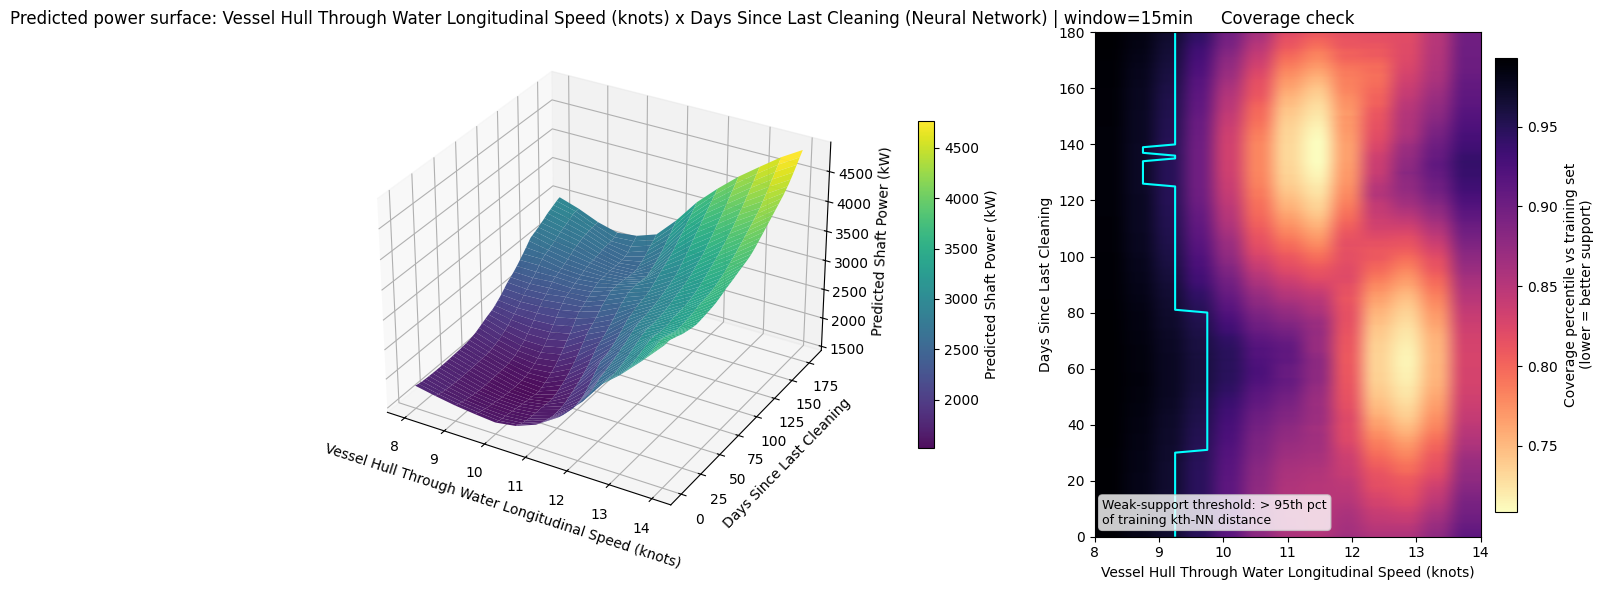

In [176]:
# Default: speed x fouling
speed_fouling_surface = plot_3d_scenario_power_surface(
    model_pipeline=model_pipelines_incl_foul["NN"],
    scenario_dir=train_test_dir,
    window_length=WINDOW_LENGTH,
    feature_x=SPEED_VARIABLE,
    feature_y=FOULING_PROXY_VAR_NAME_WITH_UNIT,
    target_variable=TARGET_VARIABLE,
    model_name_for_title="Neural Network",
    coverage_check=True,
    coverage_reference_X=X_train,
    coverage_k=50,
    coverage_stat="kth",              # or "mean"
    coverage_metric="euclidean",
    coverage_show_percentile=True,
    coverage_threshold_quantile=0.95,
    coverage_mask_weak=False,
)



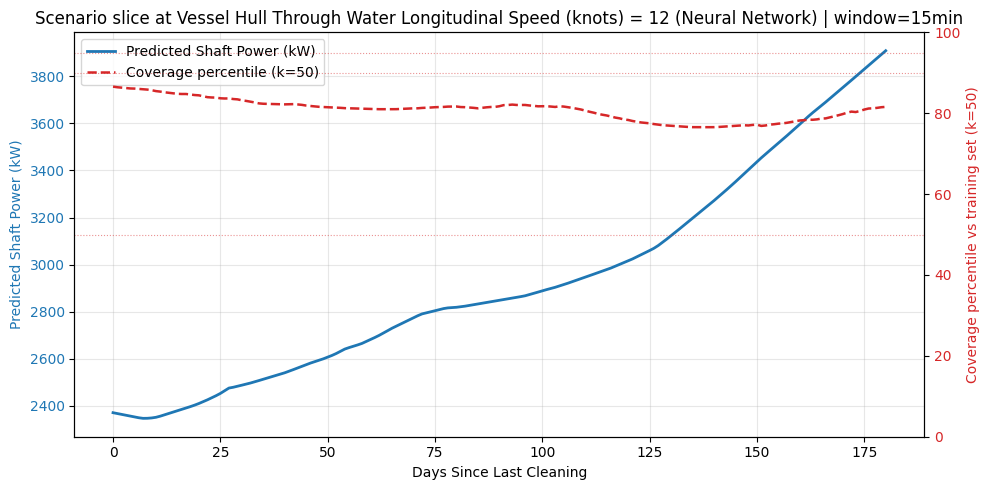

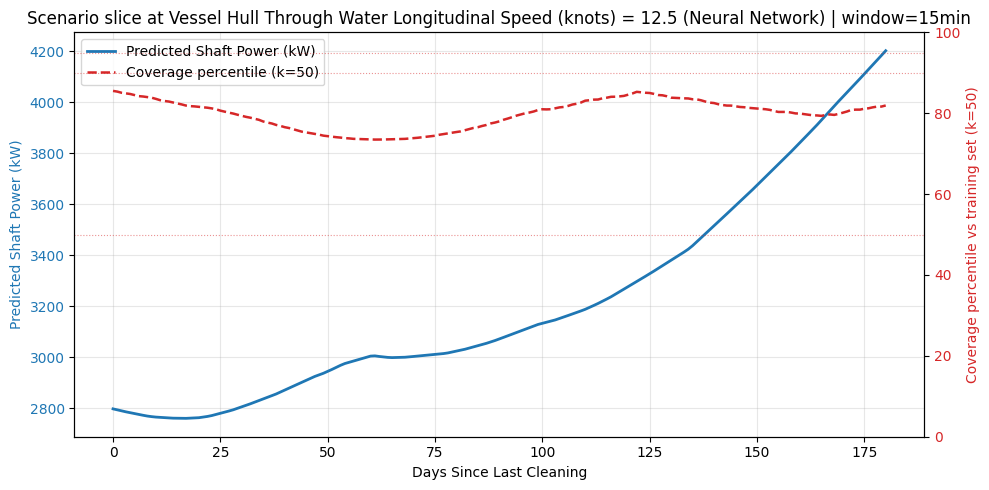

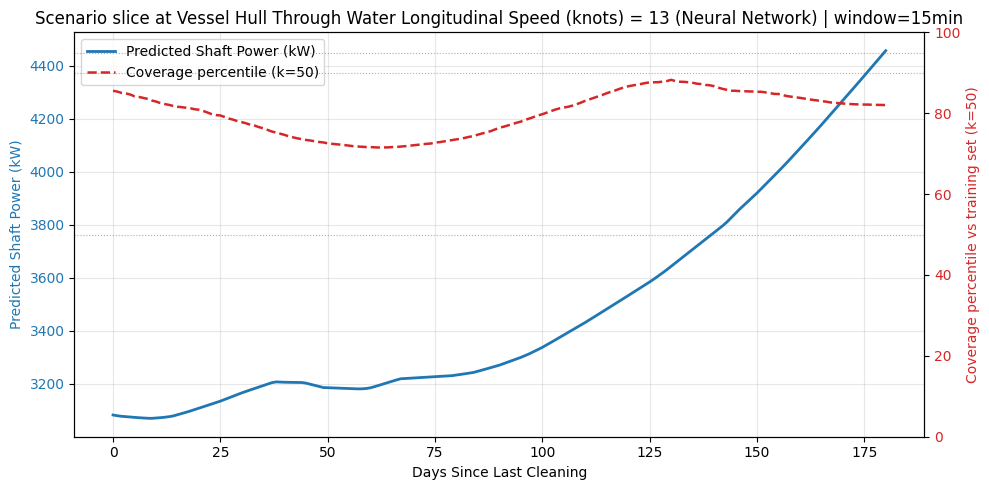

In [177]:


speed12_slice = plot_scenario_power_slice(
    model_pipeline=model_pipelines_incl_foul["NN"],
    speed_value=12,
    scenario_dir=train_test_dir,
    window_length=WINDOW_LENGTH,
    speed_feature=SPEED_VARIABLE,
    fouling_feature=FOULING_PROXY_VAR_NAME_WITH_UNIT,
    target_variable=TARGET_VARIABLE,
    model_name_for_title="Neural Network",
    coverage_check=True,
    coverage_reference_X=X_train,
    coverage_k=50,
    coverage_stat="kth",
)

speed12_5_slice = plot_scenario_power_slice(
    model_pipeline=model_pipelines_incl_foul["NN"],
    speed_value=12.5,
    scenario_dir=train_test_dir,
    window_length=WINDOW_LENGTH,
    speed_feature=SPEED_VARIABLE,
    fouling_feature=FOULING_PROXY_VAR_NAME_WITH_UNIT,
    target_variable=TARGET_VARIABLE,
    model_name_for_title="Neural Network",
    coverage_check=True,
    coverage_reference_X=X_train,
    coverage_k=50,
    coverage_stat="kth",
)

speed13_slice = plot_scenario_power_slice(
    model_pipeline=model_pipelines_incl_foul["NN"],
    speed_value=13,
    scenario_dir=train_test_dir,
    window_length=WINDOW_LENGTH,
    speed_feature=SPEED_VARIABLE,
    fouling_feature=FOULING_PROXY_VAR_NAME_WITH_UNIT,
    target_variable=TARGET_VARIABLE,
    model_name_for_title="Neural Network",
    coverage_check=True,
    coverage_reference_X=X_train,
    coverage_k=50,
    coverage_stat="kth",
)



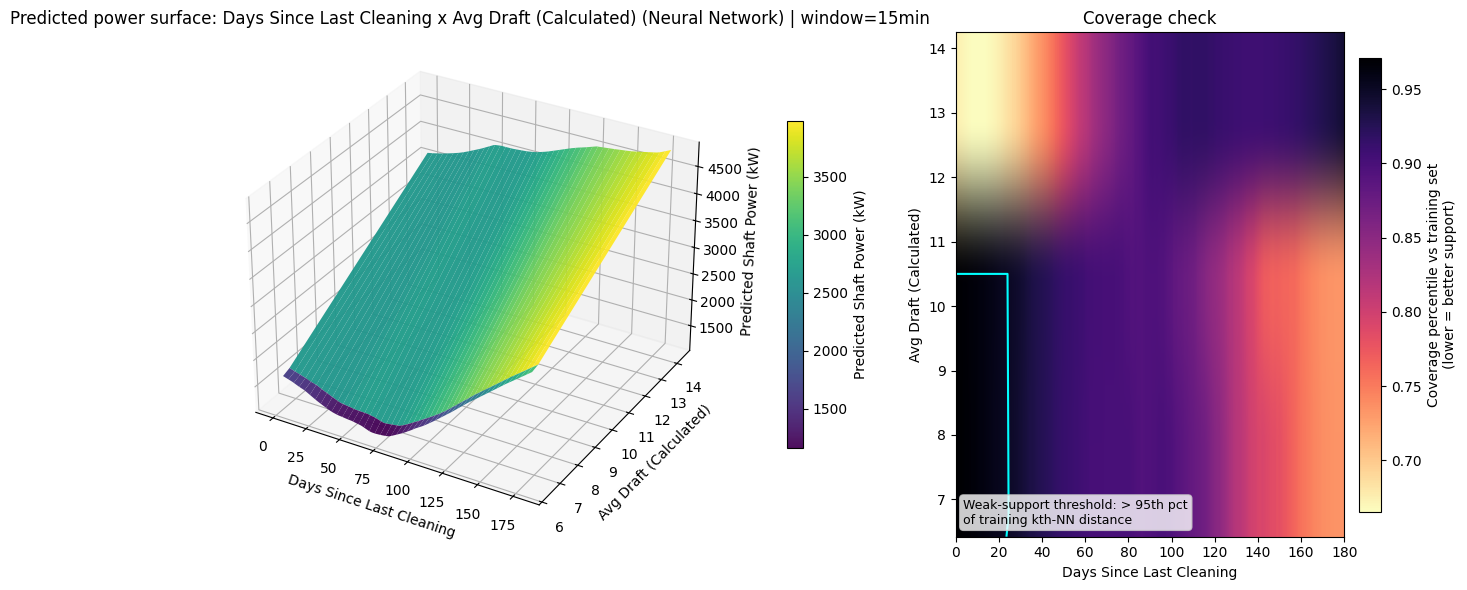

In [178]:
# Optional: fouling x draft
fouling_draft_surface = plot_3d_scenario_power_surface(
    model_pipeline=model_pipelines_incl_foul["NN"],
    scenario_dir=train_test_dir,
    window_length=WINDOW_LENGTH,
    feature_x=FOULING_PROXY_VAR_NAME_WITH_UNIT,
    feature_y="Avg Draft (Calculated)",
    target_variable=TARGET_VARIABLE,
    model_name_for_title="Neural Network",
    coverage_check=True,
    coverage_reference_X=X_train,
    coverage_k=50,
    coverage_stat="kth",              # or "mean"
    coverage_metric="euclidean",
    coverage_show_percentile=True,
    coverage_threshold_quantile=0.95,
    coverage_mask_weak=False,
)


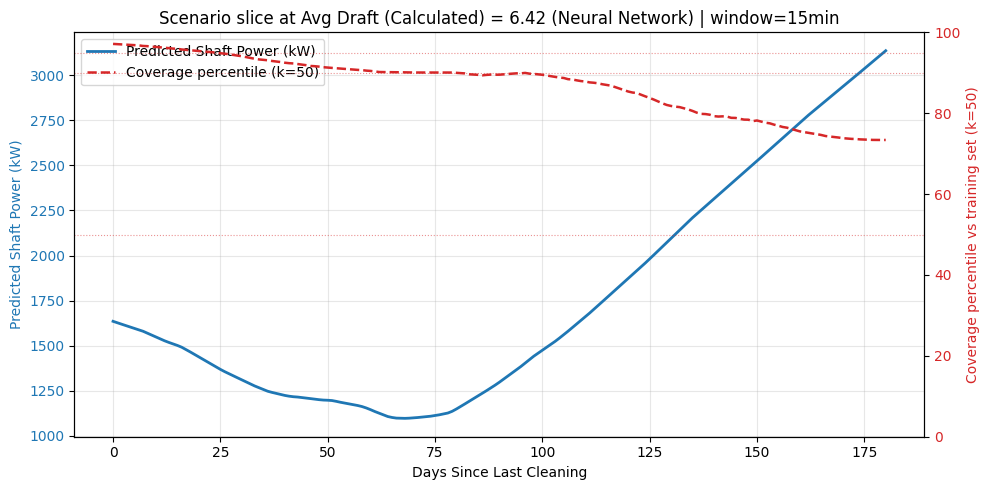

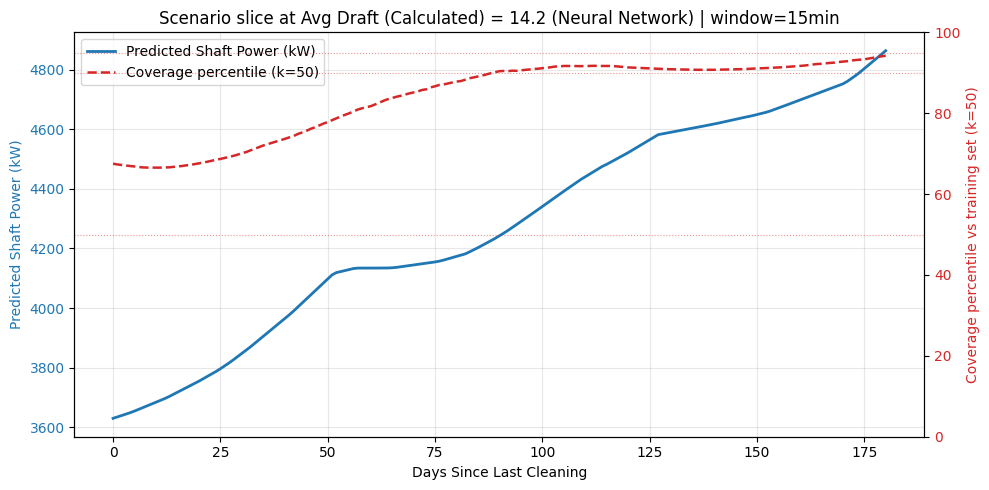

In [179]:
draft_6_45_slice = plot_scenario_power_slice(
    model_pipeline=model_pipelines_incl_foul["NN"],
    speed_value=6.45,
    scenario_dir=train_test_dir,
    window_length=WINDOW_LENGTH,
    speed_feature="Avg Draft (Calculated)",
    fouling_feature=FOULING_PROXY_VAR_NAME_WITH_UNIT,
    target_variable=TARGET_VARIABLE,
    model_name_for_title="Neural Network",
    coverage_check=True,
    coverage_reference_X=X_train,
    coverage_k=50,
    coverage_stat="kth",
)

draft_14_25_slice = plot_scenario_power_slice(
    model_pipeline=model_pipelines_incl_foul["NN"],
    speed_value=14.25,
    scenario_dir=train_test_dir,
    window_length=WINDOW_LENGTH,
    speed_feature="Avg Draft (Calculated)",
    fouling_feature=FOULING_PROXY_VAR_NAME_WITH_UNIT,
    target_variable=TARGET_VARIABLE,
    model_name_for_title="Neural Network",
    coverage_check=True,
    coverage_reference_X=X_train,
    coverage_k=50,
    coverage_stat="kth",
)


# 4. Sensitivity Analysis